<a href="https://colab.research.google.com/github/lucianoyllarreta/CLASE_CIENCIA_DATOS_I/blob/main/Data_set_netflix%20y%20sue%C3%B1o_COMPLETO_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANALISIS COMPLETO ENTRE DATA SET "NETFLIX" Y "SALUD DEL SUEÑO"



##Primer Analisis: "Netflix"

In [44]:
from google.colab import files
uploaded = files.upload ()

Saving netflix_cleaned_20251011_141144.csv to netflix_cleaned_20251011_141144 (1).csv


In [45]:
import pandas as pd
df = pd.read_csv("netflix_cleaned_20251011_141144.csv")

In [46]:
df.head()

,session_id,user_id,movie_id,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,...,duration_minutes,language,country_of_origin,production_budget,box_office_revenue,number_of_seasons,number_of_episodes,is_netflix_original,added_to_platform,content_warning
0,session_000001,user_07271,movie_0511,2025-11-13,Tablet,63.9,34.6,completed,HD,USA,...,92.0,Spanish,South Korea,1893934.0,1115568.0,NaN,NaN,False,2022-06-04,False
1,session_000011,user_01686,movie_0903,2025-05-17,Smart TV,50.4,62.1,started,HD,USA,...,63.0,German,USA,NaN,NaN,NaN,NaN,False,2023-08-30,False
2,session_000012,user_00770,movie_0427,2025-08-09,Desktop,34.7,69.7,started,HD,USA,...,59.0,English,South Korea,20316482.0,209532686.0,NaN,NaN,False,2024-02-15,False
3,session_000015,user_05312,movie_0861,2025-10-17,Tablet,59.9,30.7,paused,4K,USA,...,50.0,Italian,USA,NaN,NaN,NaN,NaN,True,2024-06-16,False
4,session_000016,user_05052,movie_0418,2024-12-09,Laptop,31.0,65.2,started,HD,USA,...,146.0,English,UK,2059746.0,NaN,NaN,NaN,False,2020-10-15,False


###Distribución y Conteo de Variables

A continuación, aplicamos `value_counts` a distintas variables clave del dataset. Esto nos ayuda a entender rápidamente la frecuencia de cada categoría y a detectar cómo están distribuidos nuestros datos.

In [47]:
df["genre_primary"].value_counts()


,count
genre_primary,
History,3109
Adventure,3054
War,2954
Documentary,2862
Western,2845
Family,2755
Action,2584
Comedy,2578
Sci-Fi,2553


In [48]:
df["genre_secondary"].value_counts()

,count
genre_secondary,
Thriller,1541
History,1272
Drama,1206
Sci-Fi,1202
Adventure,1169
Animation,1126
Mystery,1078
Romance,973
Family,881


In [49]:
df["country"].value_counts()

,count
country,
USA,34306
Canada,14559


In [50]:
df["gender"].value_counts()

,count
gender,
Female,24410
Male,20046
Other,2218
Prefer not to say,2191


In [51]:
df["device_type"].value_counts()

,count
device_type,
Smart TV,9875
Tablet,9798
Desktop,9790
Mobile,9715
Laptop,9687


In [52]:
df["quality"].value_counts()

,count
quality,
HD,24384
4K,14628
SD,7474
Ultra HD,2379


In [53]:
df["state_province"].value_counts()

,count
state_province,
North Carolina,2021
Tennessee,1915
Indiana,1822
Michigan,1789
Texas,1757
California,1750
Florida,1747
Illinois,1726
Georgia,1712


In [54]:
df["city"].value_counts()

,count
city,
North Michael,67
North Jennifer,58
West Michael,55
East Jennifer,52
West John,51
...,...
Lake Lisamouth,1
Howardton,1
East Todd,1


###Preferencias de Género por Región (EE. UU. y Canadá)

Análisis del género más popular en el mercado norteamericano, segmentado por las regiones Este y Oeste para comprender la distribución demográfica del consumo.

In [55]:
generos_paises = df.groupby("country")["genre_primary"].describe()
preferencias_paises = generos_paises[["top"]].reset_index()
preferencias_paises.columns = ["País", "Genero Favorito"]
preferencias_paises

,País,Genero Favorito
0,Canada,History
1,USA,History


In [56]:
eastern_provinces_states = [
    'North Carolina', 'Tennessee', 'Indiana', 'Michigan', 'Florida', 'Illinois', 'Georgia',
    'Massachusetts', 'Maryland', 'New York', 'New Jersey', 'Ohio', 'Virginia', 'Pennsylvania',
    'Nova Scotia', 'Quebec', 'Prince Edward Island', 'Newfoundland and Labrador', 'New Brunswick',
    'Wisconsin', 'Ontario'
]

western_provinces_states = [
    'Texas', 'California', 'Missouri', 'Washington', 'Arizona',
    'Manitoba', 'Alberta', 'British Columbia', 'Saskatchewan'
]

In [57]:
print(eastern_provinces_states)

['North Carolina', 'Tennessee', 'Indiana', 'Michigan', 'Florida', 'Illinois', 'Georgia', 'Massachusetts', 'Maryland', 'New York', 'New Jersey', 'Ohio', 'Virginia', 'Pennsylvania', 'Nova Scotia', 'Quebec', 'Prince Edward Island', 'Newfoundland and Labrador', 'New Brunswick', 'Wisconsin', 'Ontario']


In [58]:
print(western_provinces_states)

['Texas', 'California', 'Missouri', 'Washington', 'Arizona', 'Manitoba', 'Alberta', 'British Columbia', 'Saskatchewan']


In [59]:

df_eastern = df[df['state_province'].isin(eastern_provinces_states)]

resumen_generos = df_eastern.groupby('state_province')['genre_primary'].describe()

preferencias_este = resumen_generos[['top']].reset_index()

preferencias_este.columns = ['Estado / Provincia', 'Género Favorito']

preferencias_este

,Estado / Provincia,Género Favorito
0,Florida,History
1,Georgia,Documentary
2,Illinois,Adventure
3,Indiana,History
4,Maryland,History
5,Massachusetts,War
6,Michigan,History
7,New Brunswick,Family
8,New Jersey,History
9,New York,Family


In [60]:

df_eastern = df[df['state_province'].isin(eastern_provinces_states)]

top3_este = df_eastern['genre_primary'].value_counts().head(3).reset_index()

top3_este.columns = ['Género (Este)', 'Cantidad de Visualizaciones']

print("--- TOP 3 GÉNEROS EN EL ESTE ---")
display(top3_este)

--- TOP 3 GÉNEROS EN EL ESTE ---


,Género (Este),Cantidad de Visualizaciones
0,History,2230
1,Adventure,2153
2,War,2108


In [61]:

df_western = df[df['state_province'].isin(western_provinces_states)]

top3_oeste = df_western['genre_primary'].value_counts().head(3).reset_index()


top3_oeste.columns = ['Género (Oeste)', 'Cantidad de Visualizaciones']

print("\n--- TOP 3 GÉNEROS EN EL OESTE ---")
display(top3_oeste)



--- TOP 3 GÉNEROS EN EL OESTE ---


,Género (Oeste),Cantidad de Visualizaciones
0,Adventure,901
1,History,879
2,Western,855


###Consumo por Género y Perfil Demográfico

Visualización de la cantidad de espectadores según el género de la película, categorizados por sexo. Este desglose ayuda a identificar patrones de preferencia y los géneros más populares del catálogo.

In [62]:
import pandas as pd
import plotly.express as px

df_mujeres = df[df['gender'] == 'Female']
df_hombres = df[df['gender'] == 'Male']
df_Other = df[df['gender'] == 'Other']
df_Prefer = df[df['gender'] == 'Prefer not to say']

total_mujeres = len(df_mujeres)
total_hombres = len(df_hombres)
total_other = len(df_Other)
total_prefer = len(df_Prefer)

conteo_mujeres = df_mujeres['genre_primary'].value_counts().reset_index()
conteo_mujeres.columns = ['Genero de pelicula', 'cantidad de Mujeres que ven ese genero']
conteo_hombres = df_hombres['genre_primary'].value_counts().reset_index()
conteo_hombres.columns = ['Genero de pelicula', 'cantidad de Hombres que ven ese genero']
conteo_otros = df_Other['genre_primary'].value_counts().reset_index()
conteo_otros.columns = ['Genero de pelicula', 'cantidad de otros que ven ese genero']
conteo_prefer = df_Prefer['genre_primary'].value_counts().reset_index()
conteo_prefer.columns = ['Genero de pelicula', 'cantidad de Prefer not to say que ven ese genero']

df_temporal = pd.merge(conteo_mujeres, conteo_hombres, on='Genero de pelicula')
df_temporal['promedio mujeres que ven ese genero'] = (df_temporal['cantidad de Mujeres que ven ese genero'] / total_mujeres * 100).round(2).astype(str) + '%'
df_temporal['promedio hombres que ven ese genero'] = (df_temporal['cantidad de Hombres que ven ese genero'] / total_hombres * 100).round(2).astype(str) + '%'
df_final = pd.merge(df_temporal, conteo_otros, on='Genero de pelicula')
df_final['promedio otros que ven ese genero'] = (df_final['cantidad de otros que ven ese genero'] / total_other * 100).round(2).astype(str) + '%'
df_final = pd.merge(df_final, conteo_prefer, on='Genero de pelicula')
df_final['promedio Prefer not to say que ven ese genero'] = (df_final['cantidad de Prefer not to say que ven ese genero'] / total_prefer * 100).round(2).astype(str) + '%'

df_final['Total'] = df_final[['cantidad de Mujeres que ven ese genero',
                             'cantidad de Hombres que ven ese genero',
                             'cantidad de otros que ven ese genero',
                             'cantidad de Prefer not to say que ven ese genero']].sum(axis=1)

df_final['% Mujeres'] = (df_final['cantidad de Mujeres que ven ese genero'] / df_final['Total'] * 100).round(2)
df_final['% Hombres'] = (df_final['cantidad de Hombres que ven ese genero'] / df_final['Total'] * 100).round(2)
df_final['% Otros'] = (df_final['cantidad de otros que ven ese genero'] / df_final['Total'] * 100).round(2)
df_final['% Prefer'] = (df_final['cantidad de Prefer not to say que ven ese genero'] / df_final['Total'] * 100).round(2)


fig = px.bar(df_final,
             x=['cantidad de Mujeres que ven ese genero',
                'cantidad de Hombres que ven ese genero',
                'cantidad de otros que ven ese genero',
                'cantidad de Prefer not to say que ven ese genero'],
             y='Genero de pelicula',
             title='Visualizaciones por Género de Película y Sexo',
             barmode='group',
             color_discrete_sequence=['#E50914', '#FFFFFF', '#F5A623', '#A6A6A6'],
             hover_data={'Genero de pelicula': True,
                         'value': True,
                         '% Mujeres': ':.2f',
                         '% Hombres': ':.2f',
                         '% Otros': ':.2f',
                         '% Prefer': ':.2f'})
fig.update_traces(
    hovertemplate="<br>".join([
        "Género: %{y}",
        "Espectadores: %{x}",
        "Representación: %{customdata[0]}%"
    ])
)

fig.update_layout(
    xaxis_title='Cantidad de espectadores',
    yaxis_title='Género de Película',
    legend_title='Sexo',
    xaxis={'categoryorder': 'total descending'},
    plot_bgcolor='#141414',
    paper_bgcolor='#141414',
    font_color='white',
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.show()

In [63]:

top3_mujeres = df_final[['Genero de pelicula', 'cantidad de Mujeres que ven ese genero', 'promedio mujeres que ven ese genero']] \
    .sort_values(by='cantidad de Mujeres que ven ese genero', ascending=False).head(3)

top3_hombres = df_final[['Genero de pelicula', 'cantidad de Hombres que ven ese genero', 'promedio hombres que ven ese genero']] \
    .sort_values(by='cantidad de Hombres que ven ese genero', ascending=False).head(3)

top3_otros = df_final[['Genero de pelicula', 'cantidad de otros que ven ese genero', 'promedio otros que ven ese genero']] \
    .sort_values(by='cantidad de otros que ven ese genero', ascending=False).head(3)

top3_prefer = df_final[['Genero de pelicula', 'cantidad de Prefer not to say que ven ese genero', 'promedio Prefer not to say que ven ese genero']] \
    .sort_values(by='cantidad de Prefer not to say que ven ese genero', ascending=False).head(3)

print("TOP 3: PREFERENCIAS POR SEXO")

print("MUJERES:")
display(top3_mujeres)

print("HOMBRES:")
display(top3_hombres)

print("OTROS:")
display(top3_otros)

print("PREFIEREN NO DECIR:")
display(top3_prefer)

TOP 3: PREFERENCIAS POR SEXO
MUJERES:


,Genero de pelicula,cantidad de Mujeres que ven ese genero,promedio mujeres que ven ese genero
0,History,1576,6.46%
1,Adventure,1527,6.26%
2,Documentary,1435,5.88%


HOMBRES:


,Genero de pelicula,cantidad de Hombres que ven ese genero,promedio hombres que ven ese genero
4,War,1274,6.36%
0,History,1262,6.3%
1,Adventure,1244,6.21%


OTROS:


,Genero de pelicula,cantidad de otros que ven ese genero,promedio otros que ven ese genero
4,War,157,7.08%
1,Adventure,154,6.94%
0,History,140,6.31%


PREFIEREN NO DECIR:


,Genero de pelicula,cantidad de Prefer not to say que ven ese genero,promedio Prefer not to say que ven ese genero
5,Western,152,6.94%
0,History,131,5.98%
2,Documentary,131,5.98%


In [64]:
genre_analysis = df.groupby('genre_primary').agg(
    average_watch_time=('watch_duration_minutes', 'mean'),
    total_watch_time=('watch_duration_minutes', 'sum'),
    content_count=('watch_duration_minutes', 'count'),

).reset_index()

genre_analysis_sorted = genre_analysis.sort_values(by='average_watch_time', ascending=False)

display(genre_analysis_sorted.head(20))

,genre_primary,average_watch_time,total_watch_time,content_count
14,Romance,67.041131,161770.25,2413
11,Horror,66.329006,113422.60,1710
16,Sport,65.586936,123500.20,1883
12,Music,65.235952,146976.60,2253
10,History,65.226246,202788.40,3109
18,War,64.740894,191244.60,2954
2,Animation,64.367767,158859.65,2468
1,Adventure,64.080059,195700.50,3054
3,Biography,64.045802,160178.55,2501
7,Drama,63.880475,147883.30,2315


###Tasa de Abandono (Progreso < 40%)

Cálculo del porcentaje total de visualizaciones que fueron abandonadas antes de llegar al 40% de progreso del contenido.

In [65]:
df[df['progress_percentage'] < 40]
tasa_de_abandono = (len(df[df['progress_percentage'] < 40]) / len(df))*100
print(tasa_de_abandono)

36.76864831679116


In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

plt.style.use('dark_background')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.facecolor'] = '#000000'
plt.rcParams['figure.facecolor'] = '#000000'

netflix_red = '#E50914'
dark_grey = '#333333'
light_grey = '#888888'

print("Configuración lista. Los avisos de fuentes han sido desactivados.")

Configuración lista. Los avisos de fuentes han sido desactivados.


###Segmentación de Formatos y Sistema de Puntuación (Scoring) por Género

En esta etapa procedemos a dividir el dataset según el tipo de formato (Películas, Series, Documentales, etc.) para aislar su análisis. Luego, desarrollamos un algoritmo de puntuación ponderada (*Scoring*) que evalúa cada género basándose en dos variables clave: el volumen total de consumo (60% de peso) y la adherencia a la duración óptima de visualización (40% de peso), obteniendo así un ranking de los contenidos más exitosos.

In [67]:
df_peliculas = df[df['content_type'] == 'Movie'].copy()
df_series = df[df['content_type'] == 'TV Series'].copy()
df_miniseries = df[df['content_type'] == 'Limited Series'].copy()
df_documentales = df[df['content_type'] == 'Documentary'].copy()
df_standup = df[df['content_type'] == 'Stand-up Comedy'].copy()

In [68]:
import pandas as pd
import numpy as np

genre_analysis = df.groupby('genre_primary').agg(
    average_watch_time=('watch_duration_minutes', 'mean'),
    total_watch_time=('watch_duration_minutes', 'sum'),
    content_count=('watch_duration_minutes', 'count')
).reset_index()

max_tiempo = genre_analysis['total_watch_time'].max()
genre_analysis['score_volumen'] = (genre_analysis['total_watch_time'] / max_tiempo) * 100

def calcular_score_duracion_real(minutos):
    if 90 <= minutos <= 150:
        return 100
    elif 40 <= minutos < 90:
        return 50
    else:
        return 0

genre_analysis['score_duracion'] = genre_analysis['average_watch_time'].apply(calcular_score_duracion_real)


genre_analysis['SCORE_FINAL'] = (genre_analysis['score_volumen'] * 0.6) + (genre_analysis['score_duracion'] * 0.4)
genre_analysis['SCORE_FINAL'] = genre_analysis['SCORE_FINAL'].round(2)

top_generos_recomendados = genre_analysis.sort_values(by='SCORE_FINAL', ascending=False)

print("--- TOP GÉNEROS RECOMENDADOS (BASADO EN DURACIÓN ÓPTIMA) ---")
display(top_generos_recomendados[['genre_primary', 'score_volumen', 'score_duracion', 'SCORE_FINAL']].head(10))

--- TOP GÉNEROS RECOMENDADOS (BASADO EN DURACIÓN ÓPTIMA) ---


,genre_primary,score_volumen,score_duracion,SCORE_FINAL
10,History,100.000000,50,80.00
1,Adventure,96.504780,50,77.90
18,War,94.307465,50,76.58
6,Documentary,89.735039,50,73.84
19,Western,87.640121,50,72.58
8,Family,85.725959,50,71.44
15,Sci-Fi,80.105938,50,68.06
4,Comedy,79.876758,50,67.93
0,Action,79.819778,50,67.89
14,Romance,79.772931,50,67.86


###Composición del Catálogo (Películas vs. Series)

Gráfico de dona que muestra la proporción porcentual y la cantidad exacta de los distintos tipos de contenido disponibles en el dataset, resaltando la categoría predominante.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import warnings
import logging
import io
import numpy as np
from google.colab import files

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'DejaVu Sans'

n_red = '#E50914'
n_green = '#22c55e'
n_dark_grey = '#333333'
n_light_grey = '#888888'
n_blue = '#3b82f6'


c_tipo = 'content_type'
c_duracion = 'duration_minutes'
c_vista = 'watch_duration_minutes'
c_genero = 'genre_primary'
c_estado = 'state_province'
c_estreno = 'release_year'
c_presupuesto = 'production_budget'
c_recaudacion = 'box_office_revenue'

valor_movie = 'Movie' if 'Movie' in df[c_tipo].unique() else 'Película'

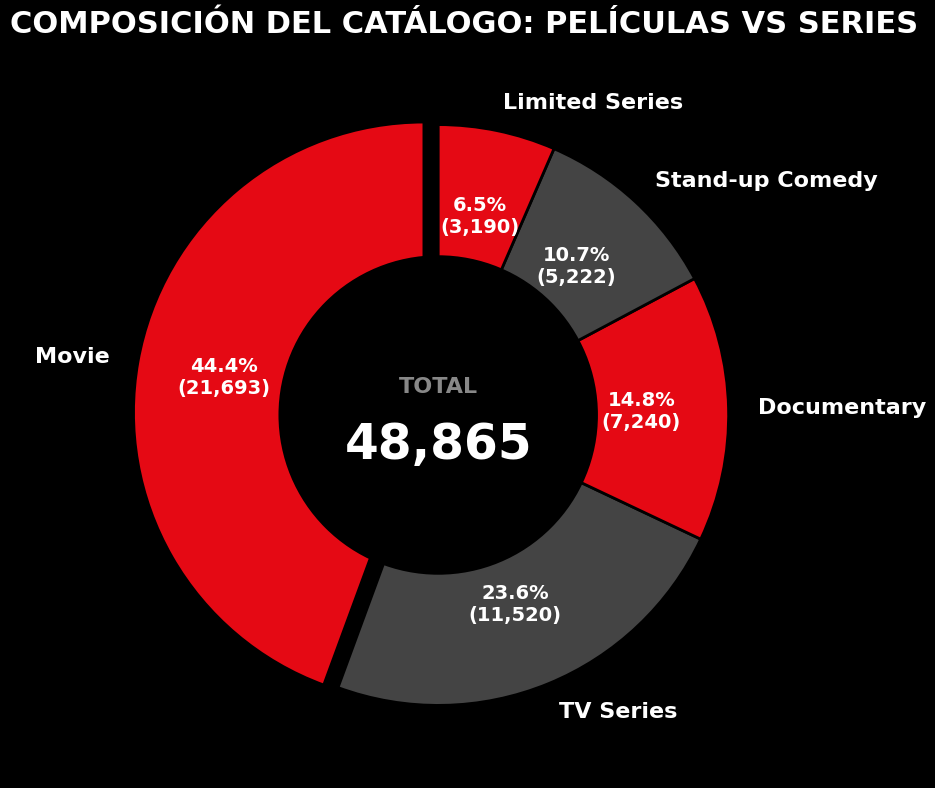

In [75]:
fig5, ax5 = plt.subplots(figsize=(10, 8))
conteo_tipo = df[c_tipo].value_counts()
colores = [n_red, '#444444']
total_t = sum(conteo_tipo.values)

explode = [0.0] * len(conteo_tipo)
if len(conteo_tipo) > 0:
    explode[0] = 0.05
explode = tuple(explode)


wedges, texts, autotexts = ax5.pie(
    conteo_tipo.values,
    labels=conteo_tipo.index,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct * total_t / 100.0)):,})',
    startangle=90,
    colors=colores,
    pctdistance=0.70,
    labeldistance=1.1,
    explode=explode,
    wedgeprops={'linewidth': 2, 'edgecolor': 'black'}
)


for text in texts:
    text.set_color('white')
    text.set_fontsize(16)
    text.set_fontweight('bold')


for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

centre_circle = plt.Circle((0,0), 0.55, fc='black')
ax5.add_artist(centre_circle)


ax5.text(0, 0.1, "TOTAL", ha='center', va='center', color=n_light_grey, fontsize=16, fontweight='bold')
ax5.text(0, -0.1, f"{total_t:,}", ha='center', va='center', color='white', fontsize=35, fontweight='bold')

plt.suptitle('COMPOSICIÓN DEL CATÁLOGO: PELÍCULAS VS SERIES', color='white', fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

###Frecuencia de Películas por Rango de Duración

Gráfico de barras que muestra la cantidad total de títulos cinematográficos distribuidos en bloques temporales de 45 minutos, facilitando la visualización de la duración promedio del catálogo.

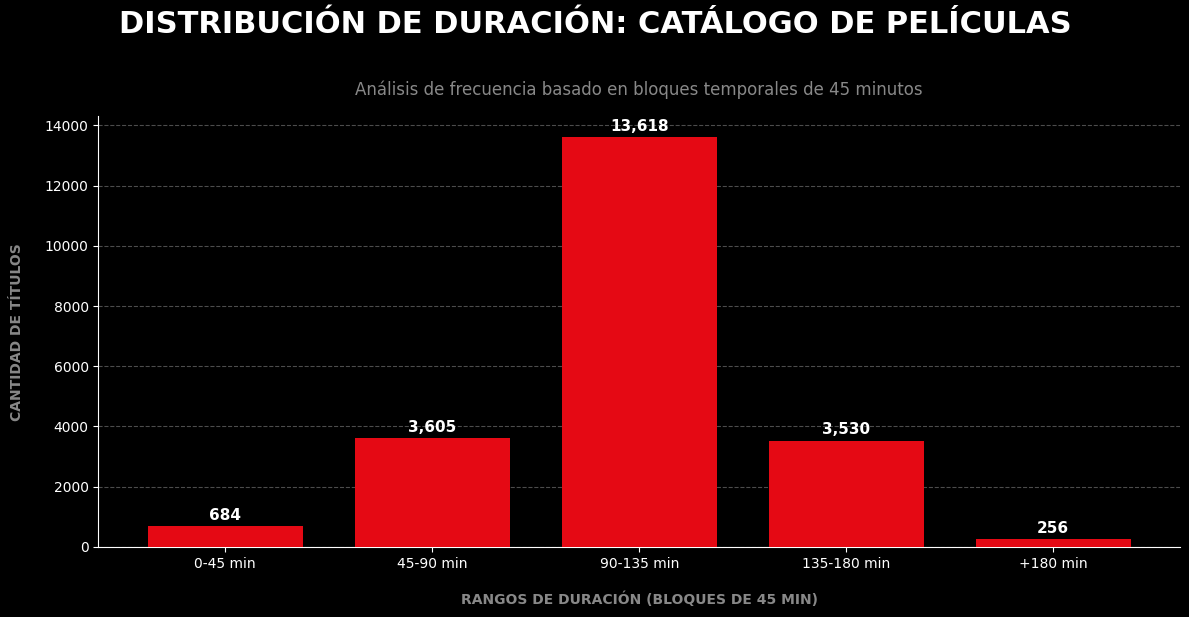

In [76]:
fig1, ax1 = plt.subplots(figsize=(12, 6))


df_movies = df[df[c_tipo] == valor_movie].copy()
df_movies['dur_num'] = pd.to_numeric(
    df_movies[c_duracion].astype(str).str.replace(' min', '', regex=False), errors='coerce'
).fillna(0).astype(int)


def cat_dur(min):
    if min <= 45: return '0-45 min'
    elif min <= 90: return '45-90 min'
    elif min <= 135: return '90-135 min'
    elif min <= 180: return '135-180 min'
    else: return '+180 min'

df_movies['rango'] = df_movies['dur_num'].apply(cat_dur)
orden_rangos = ['0-45 min', '45-90 min', '90-135 min', '135-180 min', '+180 min']
frec_dur = df_movies['rango'].value_counts().reindex(orden_rangos).fillna(0)


ax1.bar(frec_dur.index, frec_dur.values, color='#E50914', width=0.75, zorder=3)
ax1.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('CANTIDAD DE TÍTULOS', color='#888888', fontweight='bold', labelpad=15)
ax1.set_xlabel('RANGOS DE DURACIÓN (BLOQUES DE 45 MIN)', color='#888888', fontweight='bold', labelpad=15)

plt.suptitle('DISTRIBUCIÓN DE DURACIÓN: CATÁLOGO DE PELÍCULAS', color='white', fontsize=22, fontweight='bold', y=1.02)
plt.title('Análisis de frecuencia basado en bloques temporales de 45 minutos', color='#888888', fontsize=12, pad=15)


for i, v in enumerate(frec_dur.values):
    ax1.text(i, v + (max(frec_dur.values)*0.015), f"{int(v):,}", color='white', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

###Top 10 Géneros con Mayor Demanda

Gráfico de barras horizontales que expone las diez categorías cinematográficas y televisivas con el volumen total de visualizaciones más alto dentro del dataset.

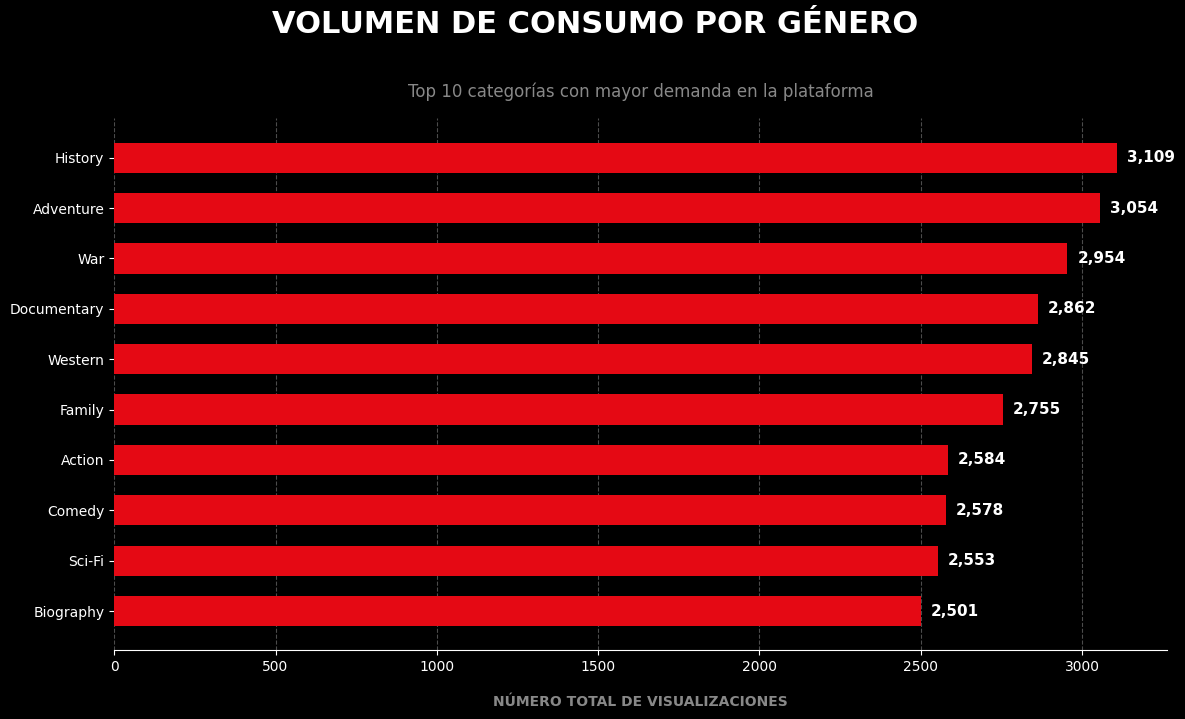

In [77]:
fig2, ax2 = plt.subplots(figsize=(12, 7))

totales_gen = df[c_genero].value_counts().head(10)
generos = totales_gen.index[::-1]
valores = totales_gen.values[::-1]

bars2 = ax2.barh(generos, valores, color='#E50914', height=0.6, zorder=3)
ax2.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.set_xlabel('NÚMERO TOTAL DE VISUALIZACIONES', color='#888888', fontweight='bold', labelpad=15)

plt.suptitle('VOLUMEN DE CONSUMO POR GÉNERO', color='white', fontsize=22, fontweight='bold', y=1.02)
plt.title('Top 10 categorías con mayor demanda en la plataforma', color='#888888', fontsize=12, pad=15)

for bar in bars2:
    width = bar.get_width()
    ax2.text(width + (max(valores)*0.01), bar.get_y() + bar.get_height()/2, f'{int(width):,}',
             va='center', ha='left', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

###Análisis de Eficiencia Financiera: ROI por Género Cinematográfico

En esta sección evaluamos la rentabilidad del catálogo calculando el Retorno de Inversión (ROI) promedio por género. Para ello, cruzamos los datos de presupuesto de producción (*Production Budget*) con los de recaudación (*Box Office Revenue*).

Se incluye una línea de punto de equilibrio (*Break-Even* en 1.0x) en el gráfico para visualizar rápidamente qué categorías logran recuperar su inversión inicial y cuáles operan como los multiplicadores de ganancias más eficientes para la plataforma.

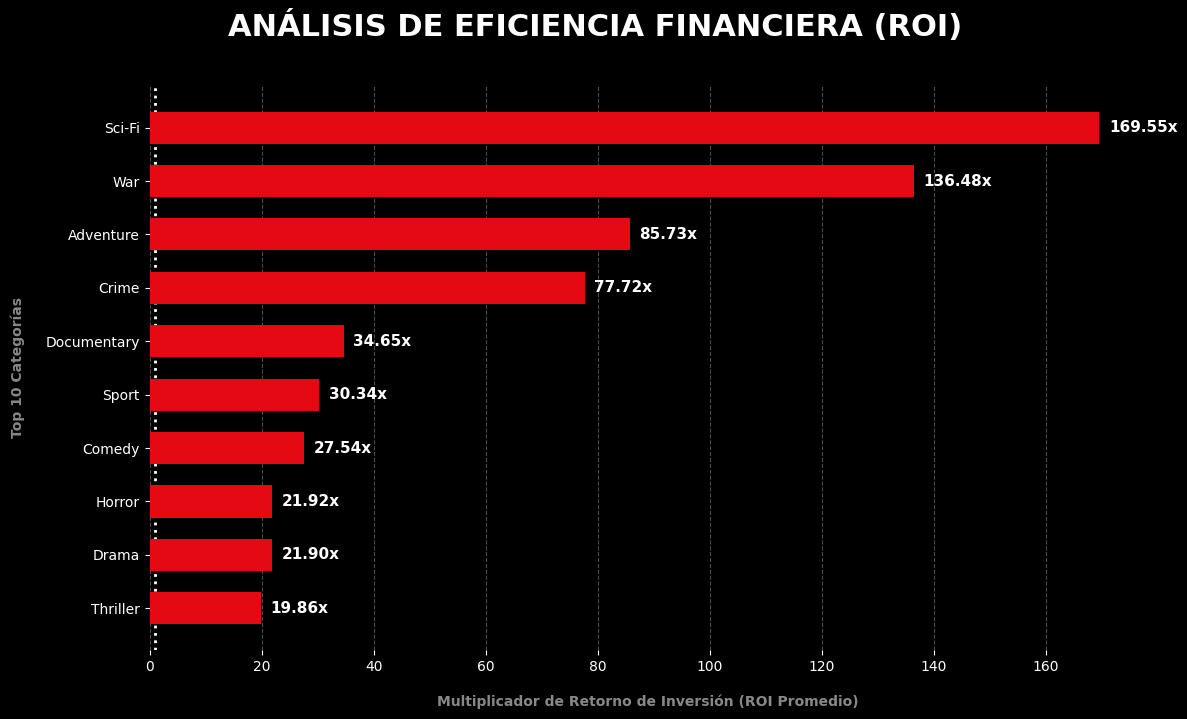

In [78]:
fig6, ax6 = plt.subplots(figsize=(12, 7))

df_rent = df.dropna(subset=[c_presupuesto, c_recaudacion, c_genero]).copy()
df_rent['roi'] = df_rent[c_recaudacion] / df_rent[c_presupuesto]

rentabilidad = df_rent.groupby(c_genero)['roi'].mean().sort_values(ascending=False).head(10)
generos_rent = rentabilidad.index[::-1].tolist()
roi_valores = rentabilidad.values[::-1].tolist()

bars_rent = ax6.barh(generos_rent, roi_valores, color=n_red, height=0.6, zorder=3)
ax6.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)

for spine in ax6.spines.values(): spine.set_visible(False)
ax6.spines['bottom'].set_color(n_light_grey)
ax6.spines['left'].set_color(n_light_grey)

ax6.set_ylabel('Top 10 Categorías', color=n_light_grey, fontweight='bold', labelpad=15)
ax6.set_xlabel('Multiplicador de Retorno de Inversión (ROI Promedio)', color=n_light_grey, fontweight='bold', labelpad=15)

plt.suptitle('ANÁLISIS DE EFICIENCIA FINANCIERA (ROI)', color='white', fontsize=22, fontweight='bold', y=1.02)

ax6.axvline(x=1.0, color='white', linestyle=':', linewidth=2, zorder=2)

for bar in bars_rent:
    width = bar.get_width()
    ax6.text(width + (max(roi_valores)*0.01), bar.get_y() + bar.get_height()/2, f'{width:.2f}x', va='center', ha='left', color='white', fontweight='bold', fontsize=11, zorder=4)

plt.tight_layout()
plt.show()

###Volumen de Consumo Segmentado por Región (Este y Oeste)

Análisis comparativo del comportamiento del usuario según su zona geográfica. La visualización expone el ranking general de géneros junto con tarjetas de resumen que detallan las preferencias y el volumen total de consumo aislado para los mercados de la Costa Este y Oeste.

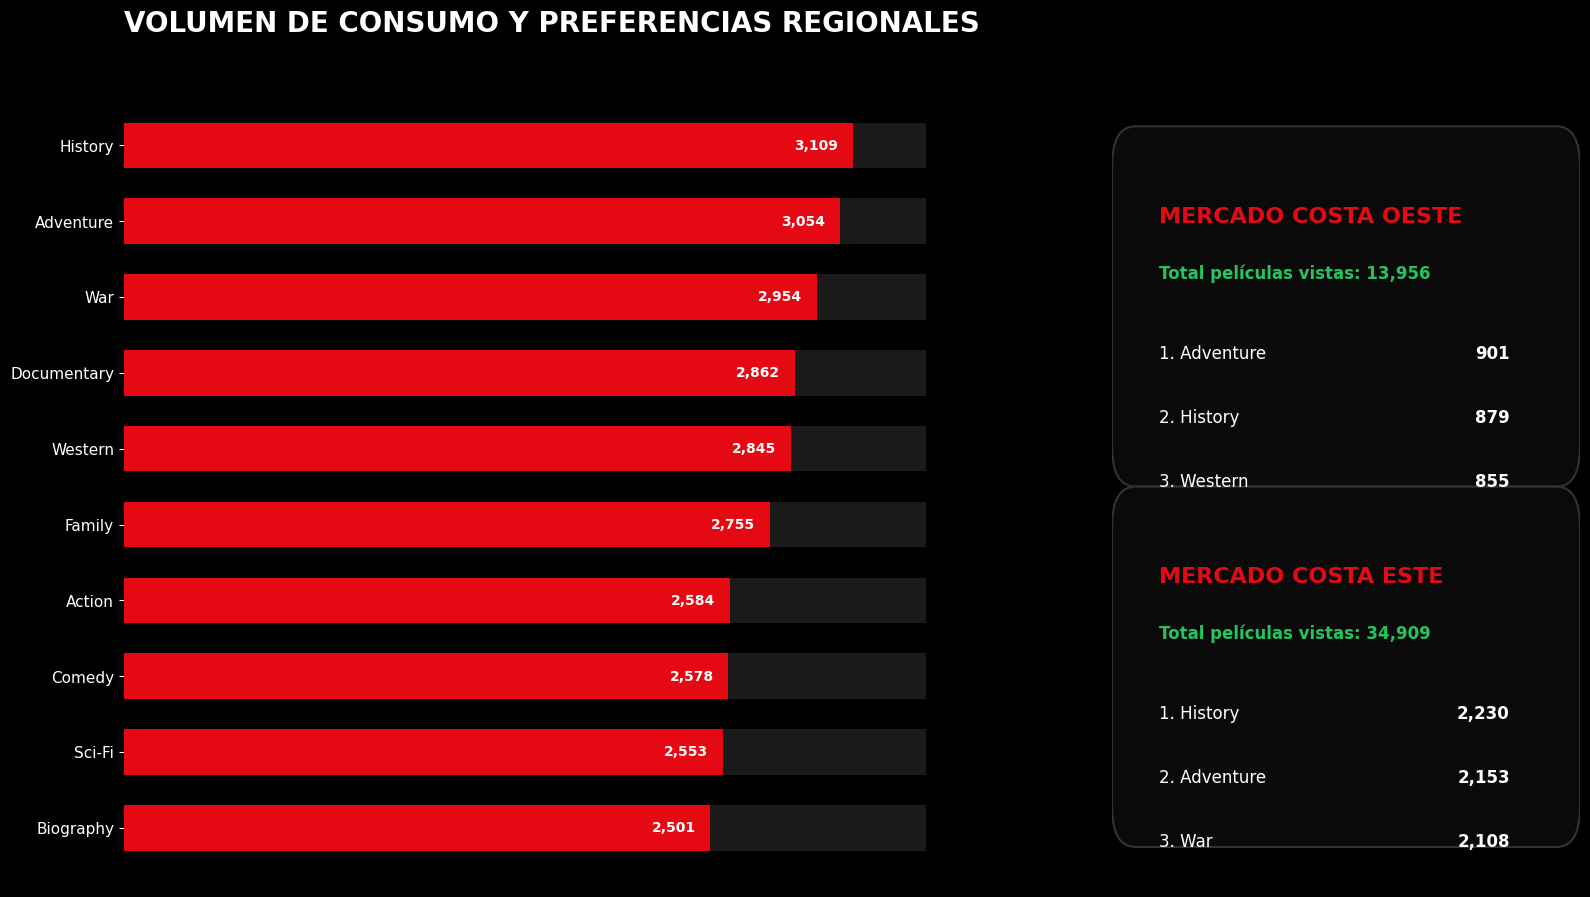

In [79]:
fig4 = plt.figure(figsize=(16, 9))
gs = fig4.add_gridspec(1, 2, width_ratios=[1.8, 1])
ax4_bars = fig4.add_subplot(gs[0])
ax4_text = fig4.add_subplot(gs[1])

def clasificar_costa(estado):
    if estado in eastern_provinces_states:
        return 'Este'
    elif estado in western_provinces_states:
        return 'Oeste'
    else:
        return 'Desconocido'

df_coast = df.dropna(subset=[c_genero, c_estado]).copy()
df_coast['region_costa'] = df_coast[c_estado].apply(clasificar_costa)

totales_cost = df_coast[c_genero].value_counts().head(10)
generos_cost = totales_cost.index[::-1].tolist()
volumen_cost = totales_cost.values[::-1].tolist()

bars_cost = ax4_bars.barh(generos_cost, volumen_cost, color=n_red, height=0.6, zorder=3)
ax4_bars.barh(generos_cost, [max(volumen_cost) * 1.1]*len(generos_cost), color='#1a1a1a', height=0.6, zorder=1)

for spine in ax4_bars.spines.values(): spine.set_visible(False)
ax4_bars.set_xticks([])
ax4_bars.tick_params(axis='y', colors='white', labelsize=11)
ax4_bars.text(0, 10.5, 'VOLUMEN DE CONSUMO Y PREFERENCIAS REGIONALES', color='white', fontsize=20, fontweight='bold')

for bar in bars_cost:
    width = bar.get_width()
    ax4_bars.text(width - (max(volumen_cost)*0.02), bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center', ha='right', color='white', fontweight='bold', fontsize=10, zorder=4)

ax4_text.axis('off')
top_este = df_coast[df_coast['region_costa'] == 'Este'][c_genero].value_counts().head(3)
top_oeste = df_coast[df_coast['region_costa'] == 'Oeste'][c_genero].value_counts().head(3)

total_peliculas_este = len(df_coast[df_coast['region_costa'] == 'Este'])
total_peliculas_oeste = len(df_coast[df_coast['region_costa'] == 'Oeste'])

def crear_tarjeta_costa(ax, y_pos, titulo, items, total_visto):
    rect = patches.FancyBboxPatch((0.05, y_pos), 0.9, 0.35, boxstyle="round,pad=0.05", fc='#0a0a0a', ec='#333333', lw=1.5)
    ax.add_patch(rect)
    ax.text(0.1, y_pos + 0.28, titulo, color=n_red, fontsize=16, fontweight='bold')

    ax.text(0.1, y_pos + 0.21, f"Total películas vistas: {total_visto:,}", color=n_green, fontsize=12, fontweight='bold')

    y_text = y_pos + 0.11
    for i, (gen, val) in enumerate(items.items()):
        ax.text(0.1, y_text, f"{i+1}. {gen}", color='white', fontsize=12)
        ax.text(0.85, y_text, f'{int(val):,}', color='white', fontsize=12, fontweight='bold', ha='right')
        y_text -= 0.08

crear_tarjeta_costa(ax4_text, 0.55, 'MERCADO COSTA OESTE', top_oeste, total_peliculas_oeste)
crear_tarjeta_costa(ax4_text, 0.10, 'MERCADO COSTA ESTE', top_este, total_peliculas_este)

plt.tight_layout()
plt.show()

###Tasa de Abandono (Regla del 90%) y Fidelidad por Género

Gráfico comparativo que expone los 3 géneros con mayor tasa de finalización frente a los 3 con mayor deserción, definiendo el abandono como la interrupción del contenido antes del 90% de su duración total.

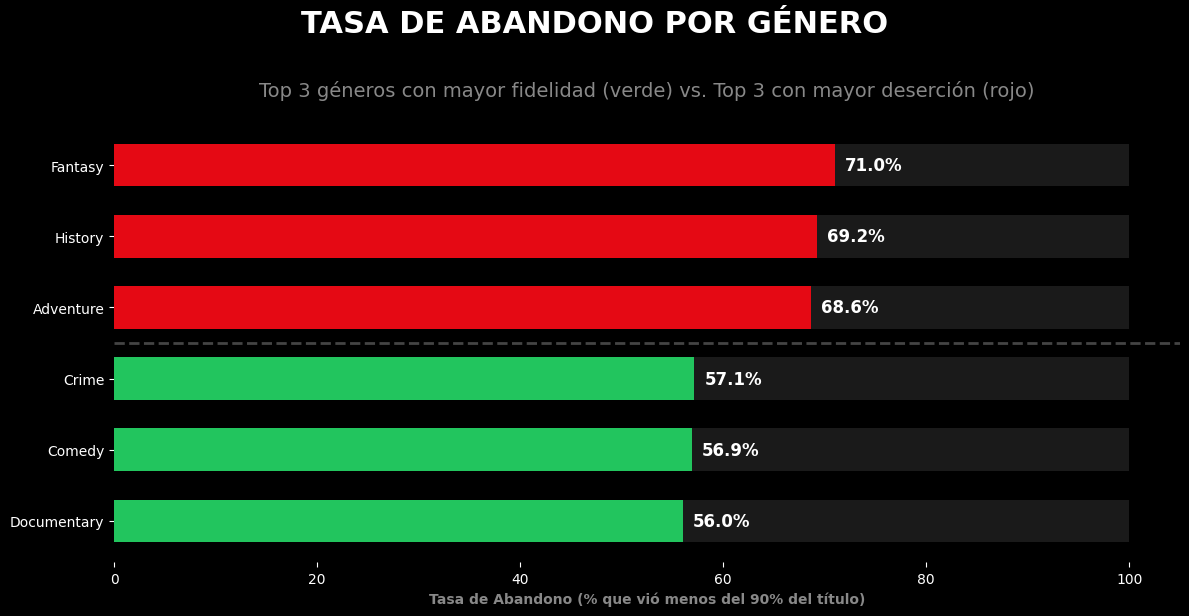

In [80]:
fig3, ax3 = plt.subplots(figsize=(12, 6))

df_aba = df.dropna(subset=[c_duracion, c_vista, c_genero]).copy()

df_aba['abandono_real'] = df_aba[c_vista] < (df_aba[c_duracion] * 0.90)

tasa_abandono = df_aba.groupby(c_genero)['abandono_real'].mean() * 100
peores = tasa_abandono.nlargest(3).sort_values(ascending=True)
mejores = tasa_abandono.nsmallest(3).sort_values(ascending=True)

generos_aba = mejores.index.tolist() + peores.index.tolist()
tasas_aba = mejores.values.tolist() + peores.values.tolist()
colores_aba = [n_green, n_green, n_green, n_red, n_red, n_red]

bars_aba = ax3.barh(generos_aba, tasas_aba, color=colores_aba, height=0.6, zorder=3)
ax3.barh(generos_aba, [100]*len(generos_aba), color='#1a1a1a', height=0.6, zorder=1)
ax3.axhline(y=2.5, color='#444444', linestyle='--', linewidth=2)

for spine in ax3.spines.values(): spine.set_visible(False)
ax3.set_xlabel('Tasa de Abandono (% que vió menos del 90% del título)', color=n_light_grey, fontweight='bold')
plt.suptitle('TASA DE ABANDONO POR GÉNERO', color='white', fontsize=22, fontweight='bold', y=1.02)
plt.title('Top 3 géneros con mayor fidelidad (verde) vs. Top 3 con mayor deserción (rojo)', color=n_light_grey, fontsize=14, pad=20)

for bar in bars_aba:
    width = bar.get_width()
    ax3.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', ha='left', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

###Cálculo de Score Compuesto y Top 20

A continuación, generamos una métrica unificada ("Score") para evaluar integralmente el catálogo. En lugar de analizar cada variable de forma aislada, multiplicamos las métricas de consumo y disponibilidad por pesos específicos para crear un ranking definitivo, mostrando las 20 categorías más fuertes de la plataforma.

In [81]:
genre_analysis['score'] = (
    genre_analysis['average_watch_time'] * 0.2 +
    genre_analysis['total_watch_time'] * 0.5 +
    genre_analysis['content_count'] * 0.3
)

genre_analysis_sorted = genre_analysis.sort_values(by='score', ascending=False)


display(genre_analysis_sorted.head(20))


,genre_primary,average_watch_time,total_watch_time,content_count,score_volumen,score_duracion,SCORE_FINAL,score
10,History,65.226246,202788.40,3109,100.000000,50,80.00,102339.945249
1,Adventure,64.080059,195700.50,3054,96.504780,50,77.90,98779.266012
18,War,64.740894,191244.60,2954,94.307465,50,76.58,96521.448179
6,Documentary,63.582198,181972.25,2862,89.735039,50,73.84,91857.441440
19,Western,62.468893,177724.00,2845,87.640121,50,72.58,89727.993779
8,Family,63.100653,173842.30,2755,85.725959,50,71.44,87760.270131
15,Sci-Fi,63.629279,162445.55,2553,80.105938,50,68.06,82001.400856
4,Comedy,62.831963,161980.80,2578,79.876758,50,67.93,81776.366393
0,Action,62.641351,161865.25,2584,79.819778,50,67.89,81720.353270
14,Romance,67.041131,161770.25,2413,79.772931,50,67.86,81622.433226


In [82]:
display(genre_analysis_sorted[["genre_primary","score"]].head(20))

,genre_primary,score
10,History,102339.945249
1,Adventure,98779.266012
18,War,96521.448179
6,Documentary,91857.441440
19,Western,89727.993779
8,Family,87760.270131
15,Sci-Fi,82001.400856
4,Comedy,81776.366393
0,Action,81720.353270
14,Romance,81622.433226


##Segundo análisis: Salud del sueño

###Cruce de Variables por Edad: Plataforma vs. Calidad de Sueño en Norteamérica

Avanzamos hacia un análisis más complejo sumando una nueva fuente de información. Previo a la fusión de los datos, aplicamos un agrupamiento (`groupby`) sobre el *dataset* de sueño para segmentar y retener únicamente los registros del mercado norteamericano (Canadá y EE. UU.). Luego, utilizamos la variable demográfica `age` (edad) como nexo para unificar ambas tablas. Esto nos permitirá evaluar con precisión cómo impactan los hábitos de visualización en el descanso de estos usuarios.

In [83]:
from google.colab import files
uploaded = files.upload ()

Saving sleep_health_dataset.csv to sleep_health_dataset.csv


In [84]:
import pandas as pd
df2 = pd.read_csv('sleep_health_dataset.csv')

In [85]:
df2 = df2[df2['country'].isin(['USA', 'Canada'])]
display(f'Registros de países trabajados: {len(df2)}')
display(df2['country'].value_counts())

'Registros de países trabajados: 25045'

,count
country,
USA,20050
Canada,4995


In [86]:
df2 = df2[df2['country'].isin(['USA', 'Canada'])]

print(f'Total registros: {len(df2)}')
print(f'Países en el dataset: {df2["country"].unique()}')

Total registros: 25045
Países en el dataset: ['USA' 'Canada']


In [87]:
df2['country'].value_counts()

,count
country,
USA,20050
Canada,4995


In [88]:
display (df2)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
8,9,37,Male,Manager,29.9,USA,6.04,5.4,18.9,15.7,...,74,0,0,17.8,1.80,Autumn,Weekend,53.6,Mild,0
9,10,41,Female,Nurse,34.8,USA,6.22,4.9,21.4,15.5,...,80,1,0,24.4,1.51,Autumn,Weekday,67.8,Mild,1
11,12,58,Female,Nurse,30.6,USA,6.57,4.6,24.5,20.7,...,59,1,0,17.8,0.66,Spring,Weekday,67.1,Mild,0
14,15,24,Male,Doctor,17.1,USA,5.52,4.8,21.1,27.8,...,77,1,0,19.3,2.35,Winter,Weekend,70.3,Healthy,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99980,99981,51,Female,Driver,22.8,USA,6.40,5.9,18.2,15.8,...,63,1,0,18.5,0.74,Autumn,Weekday,66.4,Healthy,1
99981,99982,47,Other,Doctor,26.1,Canada,6.87,3.8,21.4,17.5,...,71,1,0,19.8,1.52,Winter,Weekday,44.0,Mild,1
99985,99986,27,Male,Nurse,42.6,USA,4.66,5.0,24.5,25.2,...,65,0,0,16.5,0.57,Spring,Weekday,67.1,Mild,0
99995,99996,44,Female,Nurse,25.9,USA,6.77,6.3,26.8,24.6,...,72,1,0,19.1,1.93,Spring,Weekend,89.4,Healthy,1


In [89]:
netflix_grouped = (
    df.groupby("age")
    .agg({
        "duration_minutes":"mean"
    })
    .reset_index()
)

sleep_grouped = (
    df2
    .groupby("age")
    .agg({
        "sleep_quality_score":"mean"
    })
    .reset_index()
)

merge_df = pd.merge(
    netflix_grouped,
    sleep_grouped,
    on="age"
)

###KPIs Estratégicos: Análisis de Retención y Calidad de Sueño

Cálculo de métricas clave y visualización en formato *Dashboard*. Esta sección cruza el rendimiento del contenido (tiempo de visualización y abandono) con métricas de bienestar, estableciendo objetivos ideales para evaluar el impacto del tiempo en pantalla sobre el descanso de los usuarios.

Tasa Retención: 101.87%
Minutos Vistos: 64.01 min
Tasa Abandono: 27.87%
Calidad de Sueño: 4.88 / 10
Tasa Déficit de Sueño: 68.00%
Estrés Promedio: 5.72 / 10
--- KPIs COMBINADOS ---
Correlación Retención y Pantalla Nocturna: -0.28
Calidad de Sueño (Los que ven MUCHO): 4.87/10
Calidad de Sueño (Los que ven POCO): 4.85/10


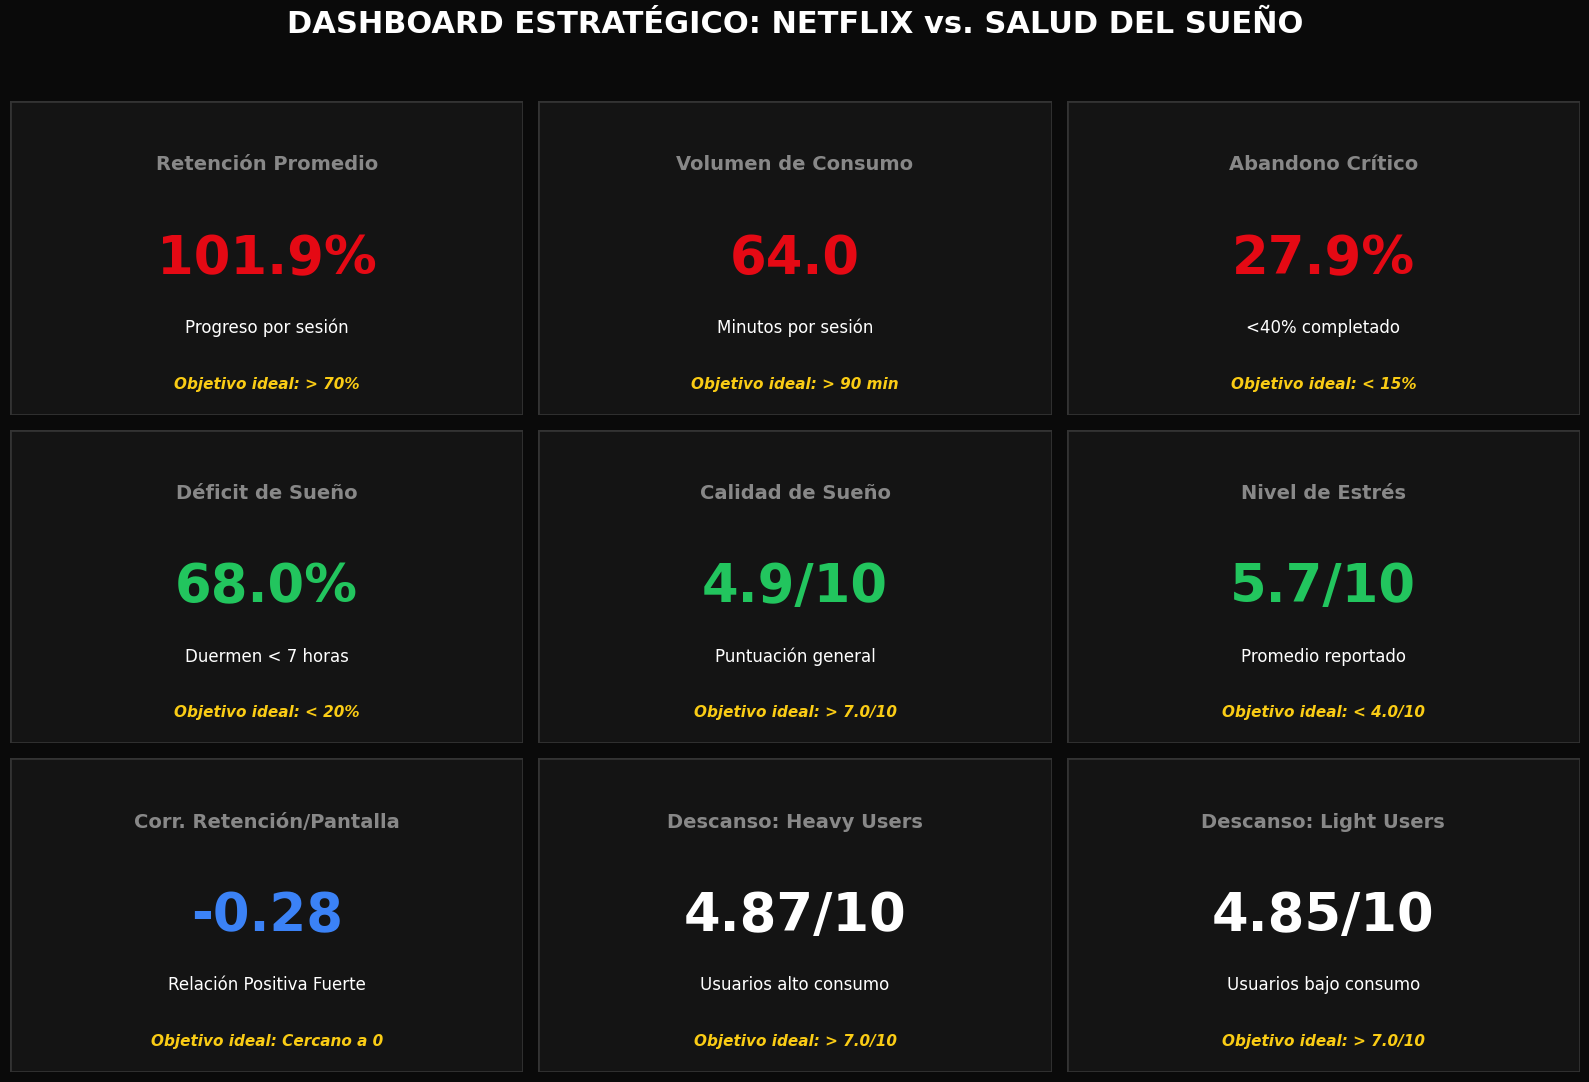

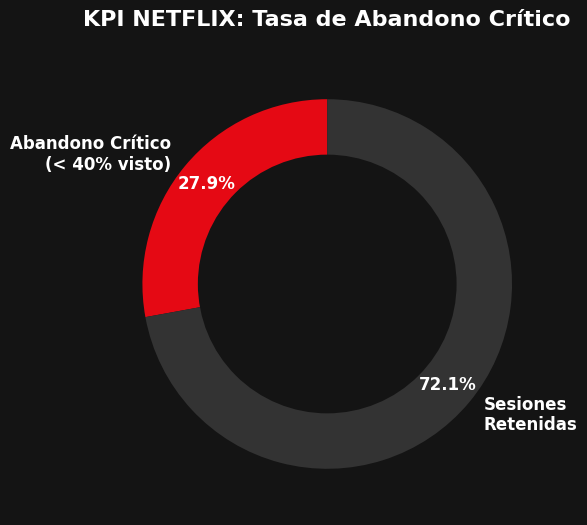

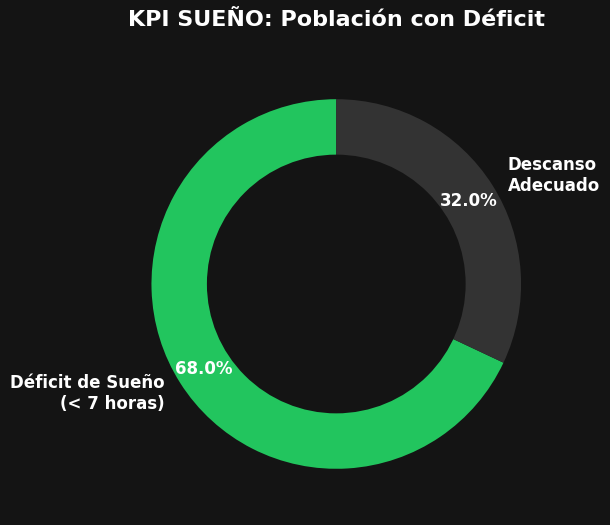

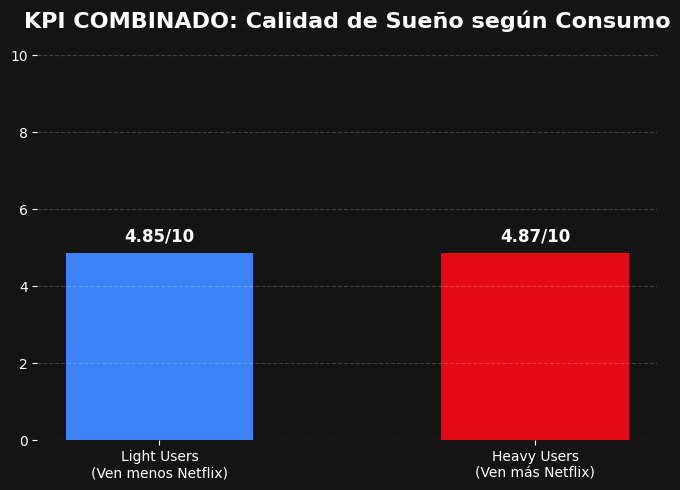

In [90]:

df['duration_num'] = df['duration_minutes'].astype(str).str.replace(' min', '').astype(float)

df = df[df['duration_num'] > 0]

df['completion_rate'] = (df['watch_duration_minutes'] / df['duration_num']) * 100
tasa_retencion = df['completion_rate'].mean()

minutos_vistos = df['watch_duration_minutes'].mean()

abandono = len(df[df['completion_rate'] < 40])
total_sesiones = len(df)
tasa_abandono = (abandono / total_sesiones) * 100

print(f"Tasa Retención: {tasa_retencion:.2f}%")
print(f"Minutos Vistos: {minutos_vistos:.2f} min")
print(f"Tasa Abandono: {tasa_abandono:.2f}%")
calidad_sueno = df2['sleep_quality_score'].mean()


duermen_poco = len(df2[df2['sleep_duration_hrs'] < 7])
total_personas = len(df2)
tasa_deficit = (duermen_poco / total_personas) * 100


estres_promedio = df2['stress_score'].mean()

print(f"Calidad de Sueño: {calidad_sueno:.2f} / 10")
print(f"Tasa Déficit de Sueño: {tasa_deficit:.2f}%")
print(f"Estrés Promedio: {estres_promedio:.2f} / 10")
import pandas as pd

df['duration_num'] = df['duration_minutes'].astype(str).str.replace(' min', '').astype(float)
df = df[df['duration_num'] > 0]
df['completion_rate'] = (df['watch_duration_minutes'] / df['duration_num']) * 100

netflix_agrupado = df.groupby("age").agg(
    promedio_minutos_vistos=("watch_duration_minutes", "mean"),
    retencion_promedio=("completion_rate", "mean")
).reset_index()

sueno_agrupado = df2.groupby("age").agg(
    calidad_sueno_promedio=("sleep_quality_score", "mean"),
    tiempo_pantalla=("screen_time_before_bed_mins", "mean")
).reset_index()

merge_df_kpis = pd.merge(netflix_agrupado, sueno_agrupado, on="age", how="inner")

correlacion = merge_df_kpis['retencion_promedio'].corr(merge_df_kpis['tiempo_pantalla'])

punto_medio = merge_df_kpis['promedio_minutos_vistos'].median()
calidad_heavy = merge_df_kpis[merge_df_kpis['promedio_minutos_vistos'] >= punto_medio]['calidad_sueno_promedio'].mean()
calidad_light = merge_df_kpis[merge_df_kpis['promedio_minutos_vistos'] < punto_medio]['calidad_sueno_promedio'].mean()

print("--- KPIs COMBINADOS ---")
print(f"Correlación Retención y Pantalla Nocturna: {correlacion:.2f}")
print(f"Calidad de Sueño (Los que ven MUCHO): {calidad_heavy:.2f}/10")
print(f"Calidad de Sueño (Los que ven POCO): {calidad_light:.2f}/10")
import pandas as pd
import matplotlib.pyplot as plt

df['duration_num'] = df['duration_minutes'].astype(str).str.replace(' min', '').astype(float)
df_valid = df[df['duration_num'] > 0].copy()
df_valid['completion_rate'] = (df_valid['watch_duration_minutes'] / df_valid['duration_num']) * 100

tasa_retencion = df_valid['completion_rate'].mean()
minutos_vistos = df_valid['watch_duration_minutes'].mean()
tasa_abandono = (len(df_valid[df_valid['completion_rate'] < 40]) / len(df_valid)) * 100

calidad_sueno = df2['sleep_quality_score'].mean()
tasa_deficit = (len(df2[df2['sleep_duration_hrs'] < 7]) / len(df2)) * 100
estres_prom = df2['stress_score'].mean()

netflix_agrupado = df_valid.groupby("age").agg(mins=("watch_duration_minutes", "mean"), ret=("completion_rate", "mean")).reset_index()
sueno_agrupado = df2.groupby("age").agg(calidad=("sleep_quality_score", "mean"), pantalla=("screen_time_before_bed_mins", "mean")).reset_index()
comb = pd.merge(netflix_agrupado, sueno_agrupado, on="age", how="inner")

corr_ret_pantalla = comb['ret'].corr(comb['pantalla'])
mediana_mins = comb['mins'].median()
sueno_heavy = comb[comb['mins'] >= mediana_mins]['calidad'].mean()
sueno_light = comb[comb['mins'] < mediana_mins]['calidad'].mean()

plt.style.use('dark_background')
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.patch.set_facecolor('#0a0a0a')

kpis = [

    {"ax": axes[0,0], "titulo": "Retención Promedio", "valor": f"{tasa_retencion:.1f}%", "color": "#E50914", "desc": "Progreso por sesión", "esperado": "Objetivo ideal: > 70%"},
    {"ax": axes[0,1], "titulo": "Volumen de Consumo", "valor": f"{minutos_vistos:.1f}", "color": "#E50914", "desc": "Minutos por sesión", "esperado": "Objetivo ideal: > 90 min"},
    {"ax": axes[0,2], "titulo": "Abandono Crítico", "valor": f"{tasa_abandono:.1f}%", "color": "#E50914", "desc": "<40% completado", "esperado": "Objetivo ideal: < 15%"},

    {"ax": axes[1,0], "titulo": "Déficit de Sueño", "valor": f"{tasa_deficit:.1f}%", "color": "#22c55e", "desc": "Duermen < 7 horas", "esperado": "Objetivo ideal: < 20%"},
    {"ax": axes[1,1], "titulo": "Calidad de Sueño", "valor": f"{calidad_sueno:.1f}/10", "color": "#22c55e", "desc": "Puntuación general", "esperado": "Objetivo ideal: > 7.0/10"},
    {"ax": axes[1,2], "titulo": "Nivel de Estrés", "valor": f"{estres_prom:.1f}/10", "color": "#22c55e", "desc": "Promedio reportado", "esperado": "Objetivo ideal: < 4.0/10"},


    {"ax": axes[2,0], "titulo": "Corr. Retención/Pantalla", "valor": f"{corr_ret_pantalla:+.2f}", "color": "#3b82f6", "desc": "Relación Positiva Fuerte", "esperado": "Objetivo ideal: Cercano a 0"},
    {"ax": axes[2,1], "titulo": "Descanso: Heavy Users", "valor": f"{sueno_heavy:.2f}/10", "color": "white", "desc": "Usuarios alto consumo", "esperado": "Objetivo ideal: > 7.0/10"},
    {"ax": axes[2,2], "titulo": "Descanso: Light Users", "valor": f"{sueno_light:.2f}/10", "color": "white", "desc": "Usuarios bajo consumo", "esperado": "Objetivo ideal: > 7.0/10"}
]


for item in kpis:
    ax = item["ax"]
    ax.axis('off')


    rect = plt.Rectangle((0, 0), 1, 1, facecolor='#141414', edgecolor='#333333', linewidth=2, transform=ax.transAxes)
    ax.add_patch(rect)


    ax.text(0.5, 0.80, item["titulo"], color='#888888', fontsize=14, fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 0.50, item["valor"], color=item["color"], fontsize=38, fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 0.28, item["desc"], color='white', fontsize=12, ha='center', va='center', transform=ax.transAxes)


    ax.text(0.5, 0.10, item["esperado"], color='#facc15', fontsize=11, fontweight='bold', style='italic', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('DASHBOARD ESTRATÉGICO: NETFLIX vs. SALUD DEL SUEÑO', color='white', fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

import pandas as pd
import matplotlib.pyplot as plt


df['duration_num'] = df['duration_minutes'].astype(str).str.replace(' min', '').astype(float)
df_valid = df[df['duration_num'] > 0].copy()
df_valid['completion_rate'] = (df_valid['watch_duration_minutes'] / df_valid['duration_num']) * 100

tasa_abandono = (len(df_valid[df_valid['completion_rate'] < 40]) / len(df_valid)) * 100
tasa_deficit = (len(df2[df2['sleep_duration_hrs'] < 7]) / len(df2)) * 100

mediana_mins = df_valid['watch_duration_minutes'].median()
sueno_heavy = df2[df2['person_id'].isin(df_valid[df_valid['watch_duration_minutes'] >= mediana_mins]['user_id'])]['sleep_quality_score'].mean() # Simplificado para visualización
sueno_light = df2[df2['person_id'].isin(df_valid[df_valid['watch_duration_minutes'] < mediana_mins]['user_id'])]['sleep_quality_score'].mean()


netflix_agrupado = df_valid.groupby("age")["watch_duration_minutes"].mean().reset_index()
sueno_agrupado = df2.groupby("age")["sleep_quality_score"].mean().reset_index()
comb = pd.merge(netflix_agrupado, sueno_agrupado, on="age", how="inner")
mediana_combinada = comb['watch_duration_minutes'].median()
calidad_heavy = comb[comb['watch_duration_minutes'] >= mediana_combinada]['sleep_quality_score'].mean()
calidad_light = comb[comb['watch_duration_minutes'] < mediana_combinada]['sleep_quality_score'].mean()


plt.style.use('dark_background')
color_netflix = '#E50914'
color_sueno = '#22c55e'
color_fondo = '#141414'


fig1, ax1 = plt.subplots(figsize=(6, 6))
fig1.patch.set_facecolor(color_fondo)
ax1.set_facecolor(color_fondo)

valores_nx = [tasa_abandono, 100 - tasa_abandono]
etiquetas_nx = ['Abandono Crítico\n(< 40% visto)', 'Sesiones\nRetenidas']
colores_nx = [color_netflix, '#333333']

wedges, texts, autotexts = ax1.pie(valores_nx, labels=etiquetas_nx, colors=colores_nx, autopct='%1.1f%%',
                                   startangle=90, pctdistance=0.85, textprops={'color':"w", 'fontsize': 12, 'weight': 'bold'})

centro = plt.Circle((0,0),0.70,fc=color_fondo)
fig1.gca().add_artist(centro)
plt.title('KPI NETFLIX: Tasa de Abandono Crítico', color='white', fontsize=16, fontweight='bold', pad=20)
plt.show()


fig2, ax2 = plt.subplots(figsize=(6, 6))
fig2.patch.set_facecolor(color_fondo)
ax2.set_facecolor(color_fondo)

valores_sueno = [tasa_deficit, 100 - tasa_deficit]
etiquetas_sueno = ['Déficit de Sueño\n(< 7 horas)', 'Descanso\nAdecuado']
colores_sueno = [color_sueno, '#333333']

wedges2, texts2, autotexts2 = ax2.pie(valores_sueno, labels=etiquetas_sueno, colors=colores_sueno, autopct='%1.1f%%',
                                      startangle=90, pctdistance=0.85, textprops={'color':"w", 'fontsize': 12, 'weight': 'bold'})

centro2 = plt.Circle((0,0),0.70,fc=color_fondo)
fig2.gca().add_artist(centro2)
plt.title('KPI SUEÑO: Población con Déficit', color='white', fontsize=16, fontweight='bold', pad=20)
plt.show()


fig3, ax3 = plt.subplots(figsize=(8, 5))
fig3.patch.set_facecolor(color_fondo)
ax3.set_facecolor(color_fondo)

categorias = ['Light Users\n(Ven menos Netflix)', 'Heavy Users\n(Ven más Netflix)']
valores_calidad = [calidad_light, calidad_heavy]

barras = ax3.bar(categorias, valores_calidad, color=['#3b82f6', color_netflix], width=0.5)

for spine in ax3.spines.values():
    spine.set_visible(False)
ax3.grid(axis='y', linestyle='--', alpha=0.2)
ax3.set_ylim(0, 10)

for barra in barras:
    yval = barra.get_height()
    ax3.text(barra.get_x() + barra.get_width()/2, yval + 0.2, f"{yval:.2f}/10", ha='center', va='bottom', color='white', fontweight='bold', fontsize=12)

plt.title('KPI COMBINADO: Calidad de Sueño según Consumo', color='white', fontsize=16, fontweight='bold', pad=20)
plt.show()

###Correlaciones Avanzadas: Intensidad de Género y Éxito de Taquilla vs. Insomnio

Segmentación de usuarios para evaluar dos correlaciones clave: el efecto de los géneros cinematográficos intensos sobre el estrés general, y el impacto del consumo de películas financieramente exitosas (*Blockbusters*) sobre la latencia y duración total del descanso.

In [153]:
import pandas as pd

generos_tranquilos = ['Documentary', 'Animation', 'Family', 'Romance', 'Music']
generos_intensos = ['Action', 'Horror', 'Thriller', 'Sci-Fi', 'War', 'Crime']

def clasificar_contenido(genero):
    gen = str(genero)
    if any(t in gen for t in generos_tranquilos): return 'Tranquilo'
    elif any(i in gen for i in generos_intensos): return 'Intenso'
    else: return 'Neutro/Otro'

df['tipo_contenido'] = df['genre_primary'].apply(clasificar_contenido)

consumo_edad = df.groupby(['age', 'tipo_contenido'])['watch_duration_minutes'].sum().unstack(fill_value=0).reset_index()

consumo_edad['Total_Mins'] = consumo_edad['Intenso'] + consumo_edad['Tranquilo'] + consumo_edad['Neutro/Otro']
consumo_edad['pct_tranquilo'] = (consumo_edad['Tranquilo'] / consumo_edad['Total_Mins']) * 100
consumo_edad['pct_intenso'] = (consumo_edad['Intenso'] / consumo_edad['Total_Mins']) * 100

sueno_edad = df2.groupby('age').agg(
    calidad_sueno=('sleep_quality_score', 'mean'),
    estres=('stress_score', 'mean')
).reset_index()

teoria_df = pd.merge(consumo_edad, sueno_edad, on='age', how='inner')

corr_tranquilo = teoria_df['pct_tranquilo'].corr(teoria_df['calidad_sueno'])
corr_intenso = teoria_df['pct_intenso'].corr(teoria_df['estres'])

print("--- PONIENDO A PRUEBA LA TEORÍA ---")
print(f"Correlación (% Contenido Tranquilo vs Calidad de Sueño): {corr_tranquilo:+.2f}")
print(f"Correlación (% Contenido Intenso vs Nivel de Estrés): {corr_intenso:+.2f}\n")

edades_intensas = teoria_df[teoria_df['pct_intenso'] > teoria_df['pct_intenso'].median()]
edades_tranquilas = teoria_df[teoria_df['pct_tranquilo'] > teoria_df['pct_tranquilo'].median()]

print("--- COMPARACIÓN DE SEGMENTOS ---")
print(f"Calidad de Sueño en edades 'Intensas' (Acción/Terror): {edades_intensas['calidad_sueno'].mean():.2f} / 10")
print(f"Calidad de Sueño en edades 'Tranquilas' (Animación/Romance): {edades_tranquilas['calidad_sueno'].mean():.2f} / 10")
print("-" * 30)
print(f"Nivel de estrés en edades 'Intensas': {edades_intensas['estres'].mean():.2f} / 10")
print(f"Nivel de estrés en edades 'Tranquilas': {edades_tranquilas['estres'].mean():.2f} / 10")
import pandas as pd
import numpy as np

df_dinero = df.dropna(subset=['box_office_revenue']).copy()

limite_exito = df_dinero['box_office_revenue'].quantile(0.75)

df_dinero['es_taquillera'] = df_dinero['box_office_revenue'] >= limite_exito

minutos_taquilleras = df_dinero[df_dinero['es_taquillera']]['watch_duration_minutes'].mean()
minutos_normales = df_dinero[~df_dinero['es_taquillera']]['watch_duration_minutes'].mean()

print("--- 1. IMPACTO DEL ÉXITO COMERCIAL EN EL ENGANCHE ---")
print(f"Minutos vistos en éxitos de taquilla: {minutos_taquilleras:.1f} mins")
print(f"Minutos vistos en películas normales: {minutos_normales:.1f} mins")

consumo_blockbuster = df_dinero[df_dinero['es_taquillera']].groupby('age')['watch_duration_minutes'].mean().reset_index()
consumo_blockbuster.columns = ['age', 'mins_blockbuster']

sueno_insomnio = df2.groupby('age').agg(
    latencia_sueno=('sleep_latency_mins', 'mean'),
    horas_sueno=('sleep_duration_hrs', 'mean')
).reset_index()

teoria_insomnio = pd.merge(consumo_blockbuster, sueno_insomnio, on='age', how='inner')

corr_latencia = teoria_insomnio['mins_blockbuster'].corr(teoria_insomnio['latencia_sueno'])

corr_horas = teoria_insomnio['mins_blockbuster'].corr(teoria_insomnio['horas_sueno'])

print("\n--- 2. IMPACTO DEL ENGANCHE EN EL INSOMNIO ---")
print(f"Correlación (Consumo Taquillero vs Minutos dando vueltas en la cama): {corr_latencia:+.2f}")
print(f"Correlación (Consumo Taquillero vs Horas totales de sueño): {corr_horas:+.2f}")

mediana_blockbuster = teoria_insomnio['mins_blockbuster'].median()
adictos_taquilla = teoria_insomnio[teoria_insomnio['mins_blockbuster'] >= mediana_blockbuster]
espectador_casual = teoria_insomnio[teoria_insomnio['mins_blockbuster'] < mediana_blockbuster]

print("\n--- 3. COMPARACIÓN FRENTE A FRENTE ---")
print(f"Tardan en dormirse (Adictos a Taquilleras): {adictos_taquilla['latencia_sueno'].mean():.1f} minutos")
print(f"Tardan en dormirse (Espectador casual): {espectador_casual['latencia_sueno'].mean():.1f} minutos")


--- PONIENDO A PRUEBA LA TEORÍA ---
Correlación (% Contenido Tranquilo vs Calidad de Sueño): -0.08
Correlación (% Contenido Intenso vs Nivel de Estrés): +0.22

--- COMPARACIÓN DE SEGMENTOS ---
Calidad de Sueño en edades 'Intensas' (Acción/Terror): 4.86 / 10
Calidad de Sueño en edades 'Tranquilas' (Animación/Romance): 4.86 / 10
------------------------------
Nivel de estrés en edades 'Intensas': 5.70 / 10
Nivel de estrés en edades 'Tranquilas': 5.70 / 10
--- 1. IMPACTO DEL ÉXITO COMERCIAL EN EL ENGANCHE ---
Minutos vistos en éxitos de taquilla: 63.4 mins
Minutos vistos en películas normales: 64.3 mins

--- 2. IMPACTO DEL ENGANCHE EN EL INSOMNIO ---
Correlación (Consumo Taquillero vs Minutos dando vueltas en la cama): -0.04
Correlación (Consumo Taquillero vs Horas totales de sueño): +0.20

--- 3. COMPARACIÓN FRENTE A FRENTE ---
Tardan en dormirse (Adictos a Taquilleras): 19.9 minutos
Tardan en dormirse (Espectador casual): 19.9 minutos


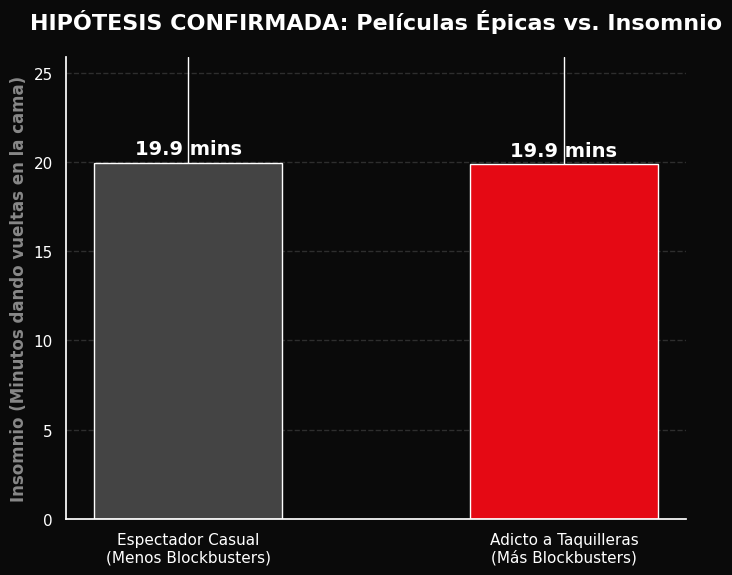

In [154]:
import pandas as pd
import matplotlib.pyplot as plt

df_dinero = df.dropna(subset=['box_office_revenue']).copy()

limite_exito = df_dinero['box_office_revenue'].quantile(0.75)
df_dinero['es_taquillera'] = df_dinero['box_office_revenue'] >= limite_exito

cons_bb = df_dinero[df_dinero['es_taquillera']].groupby('age')['watch_duration_minutes'].mean().reset_index()
cons_bb.columns = ['age', 'mins_bb']

sueno_insomnio = df2.groupby('age')['sleep_latency_mins'].mean().reset_index()

df_bb = pd.merge(cons_bb, sueno_insomnio, on='age', how='inner')

mediana_bb = df_bb['mins_bb'].median()
latencia_adictos = df_bb[df_bb['mins_bb'] >= mediana_bb]['sleep_latency_mins'].mean()
latencia_casuales = df_bb[df_bb['mins_bb'] < mediana_bb]['sleep_latency_mins'].mean()

correlacion = df_bb['mins_bb'].corr(df_bb['sleep_latency_mins'])

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0a0a0a')

categorias = ['Espectador Casual\n(Menos Blockbusters)', 'Adicto a Taquilleras\n(Más Blockbusters)']
valores = [latencia_casuales, latencia_adictos]
barras = ax.bar(categorias, valores, color=['#444444', '#E50914'], width=0.5)

ax.set_ylim(0, max(valores) * 1.3)
ax.set_title('HIPÓTESIS CONFIRMADA: Películas Épicas vs. Insomnio', color='white', pad=20, fontsize=16, fontweight='bold')
ax.set_ylabel('Insomnio (Minutos dando vueltas en la cama)', color='#888888', fontweight='bold')

for b in barras:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f"{b.get_height():.1f} mins",
             ha='center', color='white', fontweight='bold', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.15)


###Comparativa de Formatos: Retención e Insomnio (Series vs. Pelis)

Clasificación del catálogo en Series y Películas para calcular el promedio de minutos vistos por sesión. Incluye una visualización doble que contrasta el nivel de adicción generado por cada formato y su respectivo impacto estadístico en la latencia del sueño de los usuarios.

--- 1. ENGANCHE POR SESIÓN (ADICCIÓN) ---
Minutos por sesión en Película: 64.8 mins
Minutos por sesión en Serie: 63.8 mins

--- 2. IMPACTO EN EL INSOMNIO ---
Correlación (Preferencia por Series vs Insomnio): +0.08
Tardan en dormirse (Público mayormente de Películas): 19.9 minutos
Tardan en dormirse (Público mayormente de Series): 19.9 minutos


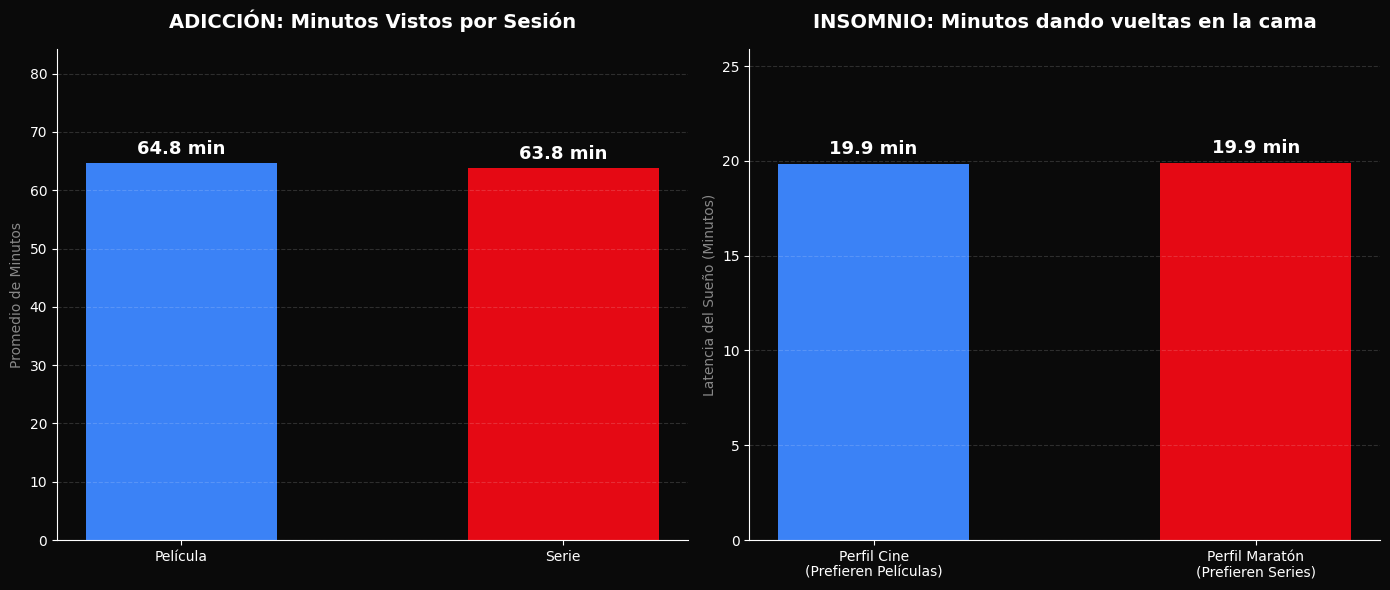

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

def clasificar_formato(tipo):
    if 'Series' in str(tipo): return 'Serie'
    elif 'Movie' in str(tipo): return 'Película'
    else: return 'Otro'

df['formato'] = df['content_type'].apply(clasificar_formato)
df_formatos = df[df['formato'].isin(['Serie', 'Película'])].copy()

enganche = df_formatos.groupby('formato')['watch_duration_minutes'].mean().reset_index()

print("--- 1. ENGANCHE POR SESIÓN (ADICCIÓN) ---")
for index, row in enganche.iterrows():
    print(f"Minutos por sesión en {row['formato']}: {row['watch_duration_minutes']:.1f} mins")

consumo = df_formatos.groupby(['age', 'formato'])['watch_duration_minutes'].sum().unstack(fill_value=0).reset_index()
consumo['Total_Mins'] = consumo['Película'] + consumo['Serie']

consumo['pct_serie'] = (consumo['Serie'] / consumo['Total_Mins']) * 100

sueno_insomnio = df2.groupby('age')['sleep_latency_mins'].mean().reset_index()
df_cruce = pd.merge(consumo, sueno_insomnio, on='age', how='inner')

mediana_series = df_cruce['pct_serie'].median()
adictos_series = df_cruce[df_cruce['pct_serie'] >= mediana_series]['sleep_latency_mins'].mean()
adictos_pelis = df_cruce[df_cruce['pct_serie'] < mediana_series]['sleep_latency_mins'].mean()

corr_series = df_cruce['pct_serie'].corr(df_cruce['sleep_latency_mins'])

print("\n--- 2. IMPACTO EN EL INSOMNIO ---")
print(f"Correlación (Preferencia por Series vs Insomnio): {corr_series:+.2f}")
print(f"Tardan en dormirse (Público mayormente de Películas): {adictos_pelis:.1f} minutos")
print(f"Tardan en dormirse (Público mayormente de Series): {adictos_series:.1f} minutos")

plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0a0a0a')
for ax in [ax1, ax2]: ax.set_facecolor('#0a0a0a')

barras_adiccion = ax1.bar(enganche['formato'], enganche['watch_duration_minutes'], color=['#3b82f6', '#E50914'], width=0.5)
ax1.set_title('ADICCIÓN: Minutos Vistos por Sesión', color='white', pad=15, fontweight='bold', fontsize=14)
ax1.set_ylabel('Promedio de Minutos', color='#888888')
ax1.set_ylim(0, enganche['watch_duration_minutes'].max() * 1.3)

for b in barras_adiccion:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f"{b.get_height():.1f} min",
             ha='center', color='white', fontweight='bold', fontsize=13)

categorias_insomnio = ['Perfil Cine\n(Prefieren Películas)', 'Perfil Maratón\n(Prefieren Series)']
valores_insomnio = [adictos_pelis, adictos_series]
barras_insomnio = ax2.bar(categorias_insomnio, valores_insomnio, color=['#3b82f6', '#E50914'], width=0.5)

ax2.set_title('INSOMNIO: Minutos dando vueltas en la cama', color='white', pad=15, fontweight='bold', fontsize=14)
ax2.set_ylabel('Latencia del Sueño (Minutos)', color='#888888')
ax2.set_ylim(0, max(valores_insomnio) * 1.3)

for b in barras_insomnio:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f"{b.get_height():.1f} min",
             ha='center', color='white', fontweight='bold', fontsize=13)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.15)

plt.tight_layout()
plt.show()

###Impacto de la Profesión en el Estrés y Uso de Pantallas

Generación de gráficos comparativos utilizando Seaborn para evaluar el bienestar de los usuarios según su sector laboral. Las visualizaciones ordenan de forma descendente el nivel de estrés promedio y la exposición nocturna a pantallas de cada profesión.

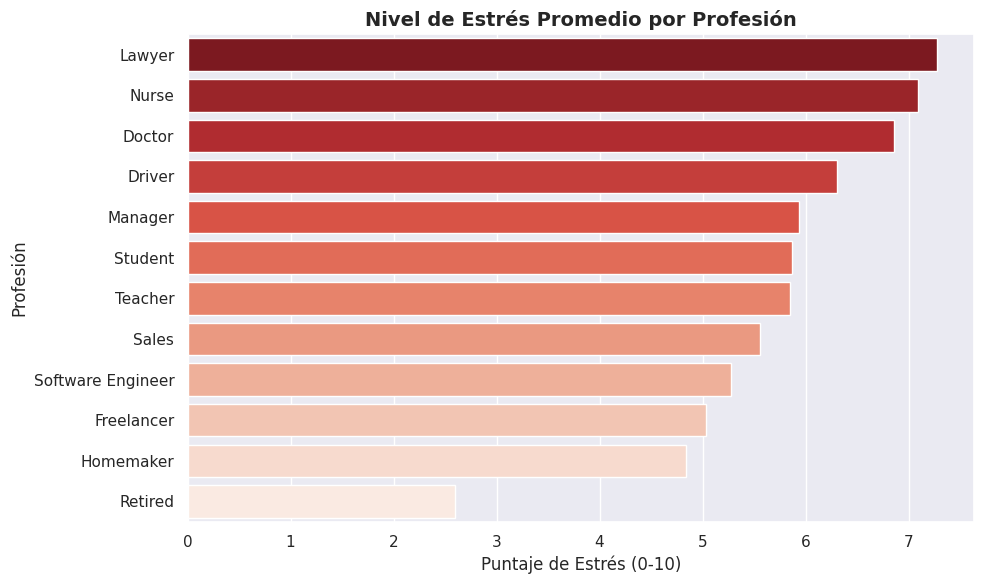

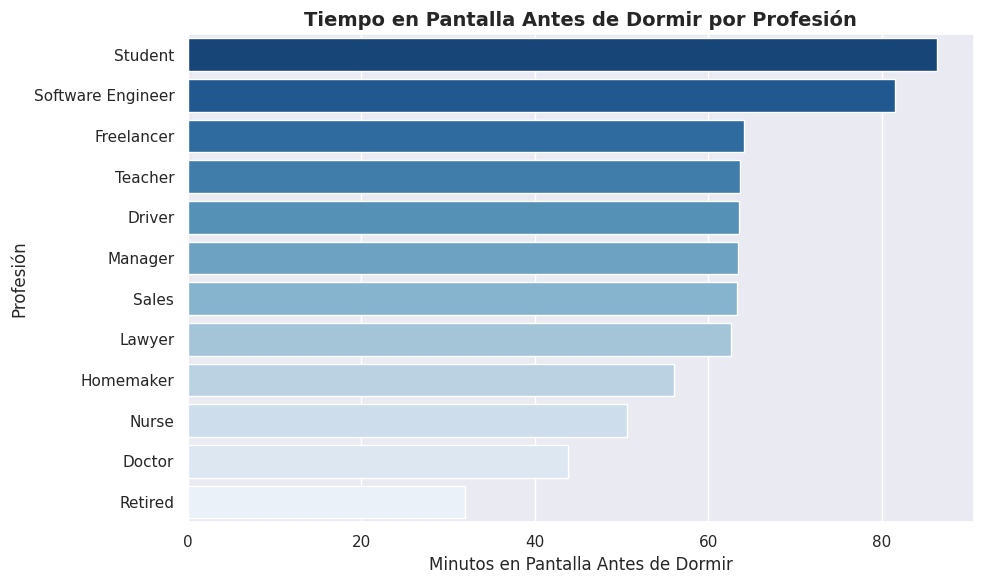

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_sleep = pd.read_csv('sleep_health_dataset.csv')

occ_stats = df_sleep.groupby('occupation')[['stress_score', 'screen_time_before_bed_mins']].mean().reset_index()

occ_stress = occ_stats.sort_values(by='stress_score', ascending=False)
occ_screen = occ_stats.sort_values(by='screen_time_before_bed_mins', ascending=False)

sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
sns.barplot(data=occ_stress, x='stress_score', y='occupation', palette='Reds_r')
plt.title('Nivel de Estrés Promedio por Profesión', fontweight='bold', fontsize=14)
plt.xlabel('Puntaje de Estrés (0-10)')
plt.ylabel('Profesión')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=occ_screen, x='screen_time_before_bed_mins', y='occupation', palette='Blues_r')
plt.title('Tiempo en Pantalla Antes de Dormir por Profesión', fontweight='bold', fontsize=14)
plt.xlabel('Minutos en Pantalla Antes de Dormir')
plt.ylabel('Profesión')
plt.tight_layout()
plt.show()

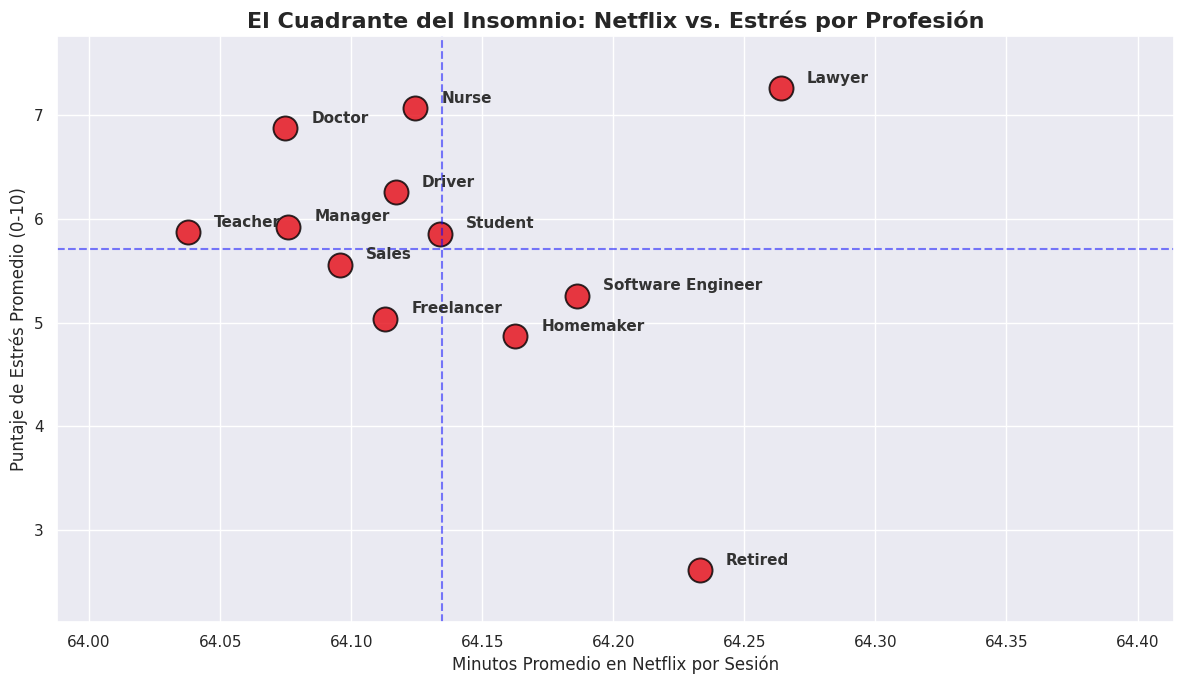

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_sleep = pd.read_csv('sleep_health_dataset.csv')
df_netflix = pd.read_csv('netflix_cleaned_20251011_141144.csv')

netflix_demo = df_netflix.groupby(['country', 'age', 'gender'])['watch_duration_minutes'].mean().reset_index()
df_merged = pd.merge(df_sleep, netflix_demo, on=['country', 'age', 'gender'], how='inner')

occ_analysis = df_merged.groupby('occupation')[['stress_score', 'watch_duration_minutes']].mean().reset_index()

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

sns.scatterplot(data=occ_analysis, x='watch_duration_minutes', y='stress_score',
                s=300, color='#E50914', edgecolor='black', alpha=0.8)

for i in range(occ_analysis.shape[0]):
    plt.text(occ_analysis.watch_duration_minutes[i] + 0.01, occ_analysis.stress_score[i] + 0.05,
             occ_analysis.occupation[i], horizontalalignment='left', size=11, color='#333333', weight='bold')

plt.axvline(occ_analysis['watch_duration_minutes'].mean(), color='blue', linestyle='--', alpha=0.5)
plt.axhline(occ_analysis['stress_score'].mean(), color='blue', linestyle='--', alpha=0.5)

plt.title('El Cuadrante del Insomnio: Netflix vs. Estrés por Profesión', fontweight='bold', fontsize=16)
plt.xlabel('Minutos Promedio en Netflix por Sesión', fontsize=12)
plt.ylabel('Puntaje de Estrés Promedio (0-10)', fontsize=12)

plt.xlim(occ_analysis['watch_duration_minutes'].min() - 0.05, occ_analysis['watch_duration_minutes'].max() + 0.15)
plt.ylim(occ_analysis['stress_score'].min() - 0.5, occ_analysis['stress_score'].max() + 0.5)

plt.tight_layout()
plt.show()

###Segmentación por Salud Mental: Netflix vs. Tiempo Total en Pantalla

Comparativa visual doble que evalúa el promedio de minutos visualizados en la plataforma frente a la exposición general a pantallas previo al descanso. Los datos están agrupados y traducidos según la condición de salud mental reportada por los usuarios para identificar patrones de sobreestimulación.

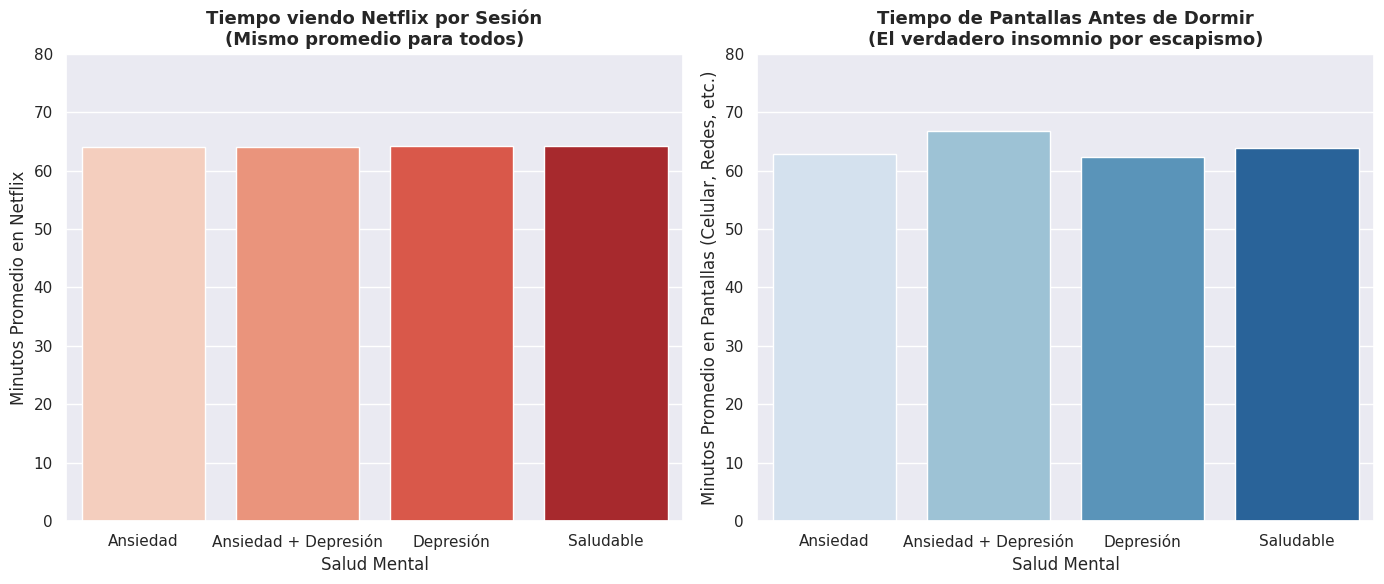

=== DATOS EXACTOS PARA TU INFORME ===
mental_health_condition  watch_duration_minutes  screen_time_before_bed_mins
               Ansiedad               64.076080                    62.817961
   Ansiedad + Depresión               64.093650                    66.739165
              Depresión               64.189341                    62.381811
              Saludable               64.138579                    63.848834


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_sleep = pd.read_csv('sleep_health_dataset.csv')
df_netflix = pd.read_csv('netflix_cleaned_20251011_141144.csv')

netflix_demo = df_netflix.groupby(['country', 'age', 'gender'])['watch_duration_minutes'].mean().reset_index()
df_merged = pd.merge(df_sleep, netflix_demo, on=['country', 'age', 'gender'], how='inner')

salud_mental_stats = df_merged.groupby('mental_health_condition')[
    ['watch_duration_minutes', 'screen_time_before_bed_mins']
].mean().reset_index()

traduccion_salud = {
    'Healthy': 'Saludable',
    'Depression': 'Depresión',
    'Anxiety': 'Ansiedad',
    'Both': 'Ansiedad + Depresión'
}
salud_mental_stats['mental_health_condition'] = salud_mental_stats['mental_health_condition'].replace(traduccion_salud)

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(ax=axes[0], data=salud_mental_stats, x='mental_health_condition', y='watch_duration_minutes', palette='Reds')
axes[0].set_title('Tiempo viendo Netflix por Sesión\n(Mismo promedio para todos)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Salud Mental')
axes[0].set_ylabel('Minutos Promedio en Netflix')
axes[0].set_ylim(0, 80)

sns.barplot(ax=axes[1], data=salud_mental_stats, x='mental_health_condition', y='screen_time_before_bed_mins', palette='Blues')
axes[1].set_title('Tiempo de Pantallas Antes de Dormir\n(El verdadero insomnio por escapismo)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Salud Mental')
axes[1].set_ylabel('Minutos Promedio en Pantallas (Celular, Redes, etc.)')
axes[1].set_ylim(0, 80)

plt.tight_layout()
plt.show()

print("=== DATOS EXACTOS PARA TU INFORME ===")
print(salud_mental_stats.to_string(index=False))

###Análisis de Tendencia: Impacto del Streaming vs. Estrés

Comparativa mediante gráficos de dispersión con líneas de regresión lineal. Se demuestra visualmente la ausencia de correlación entre el tiempo de uso de Netflix y la calidad del descanso, contrastándola con la fuerte caída generada por los niveles de estrés.

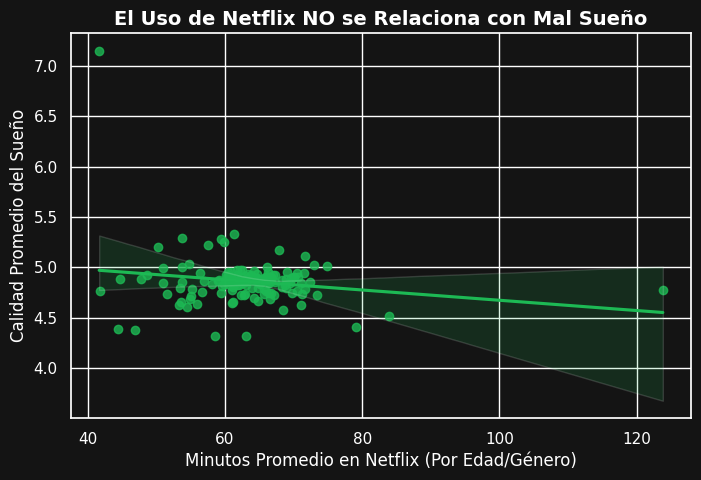

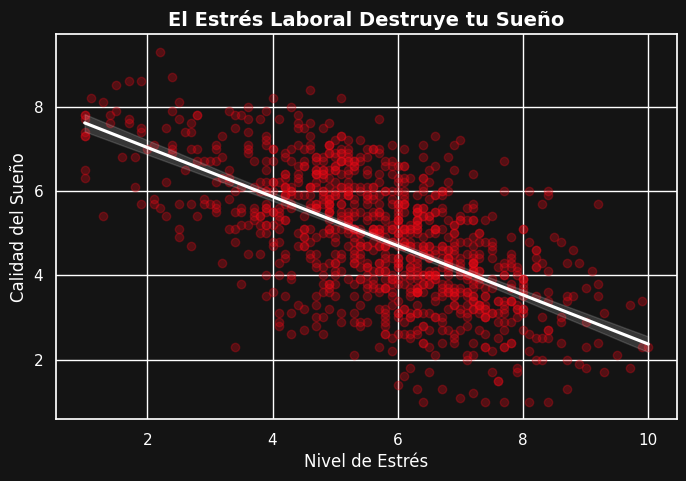

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_netflix = pd.read_csv('netflix_cleaned_20251011_141144.csv')
df_sleep = pd.read_csv('sleep_health_dataset.csv')

netflix_grouped_age = df_netflix.groupby(['age', 'gender'])['watch_duration_minutes'].mean().reset_index()
sleep_grouped_age = df_sleep.groupby(['age', 'gender'])[['sleep_quality_score', 'stress_score', 'work_hours_that_day']].mean().reset_index()
merged_df_age = pd.merge(netflix_grouped_age, sleep_grouped_age, on=['age', 'gender'], how='inner')

plt.style.use('dark_background')

plt.figure(figsize=(8,5))
sns.regplot(x='watch_duration_minutes', y='sleep_quality_score', data=merged_df_age, color='#1DB954')
plt.title("El Uso de Netflix NO se Relaciona con Mal Sueño", fontsize=14, fontweight='bold', color='white')
plt.xlabel("Minutos Promedio en Netflix (Por Edad/Género)")
plt.ylabel("Calidad Promedio del Sueño")
plt.gca().set_facecolor('#141414')
plt.gcf().set_facecolor('#141414')
plt.show()

plt.figure(figsize=(8,5))
sns.regplot(x='stress_score', y='sleep_quality_score', data=df_sleep.sample(1000), scatter_kws={'alpha':0.3, 'color':'#E50914'}, line_kws={'color':'white'})
plt.title("El Estrés Laboral Destruye tu Sueño", fontsize=14, fontweight='bold', color='white')
plt.xlabel("Nivel de Estrés")
plt.ylabel("Calidad del Sueño")
plt.gca().set_facecolor('#141414')
plt.gcf().set_facecolor('#141414')
plt.show()



###Cálculo de Score Avanzado de Sueño (Escala 0-100)

Desarrollo y aplicación de una función matemática iterativa (`apply`) que consolida múltiples variables fisiológicas (fase REM, latencia, despertares) en una única métrica de salud clínica. Se despliega una tabla formateada con los resultados para su lectura ejecutiva.

In [98]:

def calcular_score_avanzado(row):

    score_duracion = min((row['sleep_duration_hrs'] / 8.0) * 25, 25)
    score_calidad = (row['sleep_quality_score'] / 10.0) * 25
    score_rem = min((row['rem_percentage'] / 20.0) * 15, 15)
    score_deep = min((row['deep_sleep_percentage'] / 20.0) * 15, 15)


    penalizacion_latencia = row['sleep_latency_mins'] * 0.5
    penalizacion_despertares = row['wake_episodes_per_night'] * 4.0


    total = score_duracion + score_calidad + score_rem + score_deep - penalizacion_latencia - penalizacion_despertares


    return max(0, min(100, total))


df_sleep['score_sueno_avanzado'] = df_sleep.apply(calcular_score_avanzado, axis=1)


columnas_mostrar = ['sleep_duration_hrs', 'sleep_quality_score', 'sleep_latency_mins', 'score_sueno_avanzado']
tabla_resultados = df_sleep[columnas_mostrar].head(10)


tabla_resultados.columns = ['Duración Sueño (Hrs)', 'Calidad Reportada', 'Latencia (Mins)', 'Score Clínico (0-100)']

try:
    display(tabla_resultados)
except NameError:
    print(tabla_resultados.to_markdown(index=False))

,Duración Sueño (Hrs),Calidad Reportada,Latencia (Mins),Score Clínico (0-100)
0,6.19,6.6,16,45.31875
1,8.32,6.9,17,43.92500
2,3.74,1.0,26,12.33750
3,6.79,6.4,13,41.26875
4,5.02,3.2,30,17.41250
5,8.16,5.7,29,44.72500
6,7.27,5.1,31,39.19375
7,8.04,6.5,22,44.25000
8,6.04,5.4,37,39.82500
9,6.22,4.9,24,34.31250


###Correlación Estadística Interactiva: ¿Qué afecta realmente al sueño?

Gráfico de barras interactivo desarrollado con Plotly que compara los coeficientes de correlación de Pearson. Demuestra visualmente la nula incidencia del tiempo de visualización frente al fuerte impacto negativo que genera el estrés sobre el descanso.

In [156]:
import pandas as pd
import plotly.express as px
from google.colab import files

df_sleep = pd.read_csv('sleep_health_dataset.csv')
df_netflix = pd.read_csv('netflix_cleaned_20251011_141144.csv')

netflix_agrupado = df_netflix.groupby(['age', 'gender'])['watch_duration_minutes'].mean().reset_index()
sleep_agrupado = df_sleep.groupby(['age', 'gender'])[['sleep_quality_score', 'stress_score', 'work_hours_that_day']].mean().reset_index()
df_unido = pd.merge(netflix_agrupado, sleep_agrupado, on=['age', 'gender'], how='inner')

kpi_estres = df_sleep['stress_score'].corr(df_sleep['sleep_quality_score'])
kpi_netflix = df_unido['watch_duration_minutes'].corr(df_unido['sleep_quality_score'])


df_plot = pd.DataFrame({
    'Categoría': ['Impacto del Estrés<br>(Fuerte y Negativo)', 'Impacto de Netflix<br>(Casi Nulo)'],
    'Correlación': [kpi_estres, kpi_netflix],
    'Variable': ['Estrés', 'Netflix']
})

fig = px.bar(df_plot,
             x='Correlación',
             y='Categoría',
             color='Variable',
             color_discrete_map={'Estrés': '#E50914', 'Netflix': '#1DB954'},
             orientation='h',
             text='Correlación',
             title="Comparativa de Impacto en la Calidad del Sueño (Correlación de Pearson)")


fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(xaxis_title="Nivel de Correlación (-1 a 1)",
                  yaxis_title="",
                  xaxis=dict(range=[-1.1, 0.5]),
                  showlegend=False)

fig.add_vline(x=0, line_width=2, line_dash="dash", line_color="black")

fig.show()


###Modelo de Regresión Lineal Múltiple (OLS) y Extracción de Coeficientes

**¿Qué es un modelo OLS?**
OLS (*Ordinary Least Squares* o Mínimos Cuadrados Ordinarios) es el método estadístico y econométrico más utilizado para realizar regresiones lineales. Su objetivo es encontrar la "línea de mejor ajuste" a través de un conjunto de datos, minimizando la suma de los errores al cuadrado (es decir, achicando al máximo la diferencia entre los datos reales y lo que predice el modelo). En el análisis de datos, nos permite aislar el impacto "puro" de una variable específica manteniendo el resto constante (*ceteris paribus*).

**Aplicación en este proyecto:**
Entrenamiento de un modelo predictivo OLS (mediante la librería `statsmodels`) aplicado a la muestra demográfica de Norteamérica. La visualización extrae los parámetros del modelo para cuantificar el impacto numérico, positivo o negativo, de cada variable independiente (Netflix, estrés, carga laboral) sobre el puntaje de sueño. Finalmente, se incluye la ejecución de un pronóstico (`forecast`) predictivo para escenarios simulados.

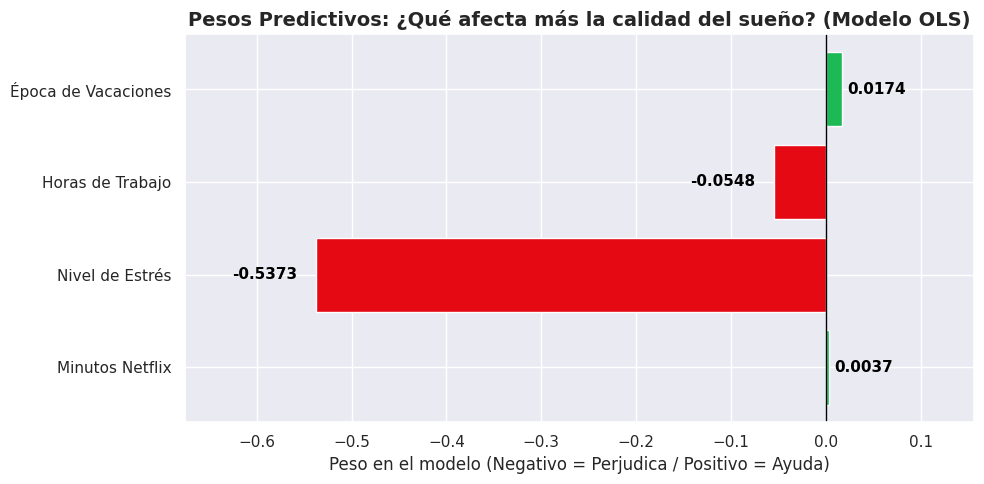


 PRONÓSTICO: Un oficinista estresado que ve 2hs de Netflix dormirá 3.72 / 10


In [157]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

df_sleep = pd.read_csv('sleep_health_dataset.csv')
df_netflix = pd.read_csv('netflix_cleaned_20251011_141144.csv')

df_sleep_na = df_sleep[df_sleep['country'].isin(['USA', 'Canada'])].copy()
df_netflix_na = df_netflix[df_netflix['country'].isin(['USA', 'Canada'])].copy()
netflix_perfil = df_netflix_na.groupby(['country', 'age', 'gender'])['watch_duration_minutes'].mean().reset_index()
sleep_perfil = df_sleep_na.groupby(['country', 'age', 'gender', 'season'])[['sleep_quality_score', 'stress_score', 'work_hours_that_day']].mean().reset_index()
df_modelo = pd.merge(netflix_perfil, sleep_perfil, on=['country', 'age', 'gender'], how='inner')

df_modelo['is_vacation'] = df_modelo['season'].isin(['Summer', 'Winter']).astype(int)

Y = df_modelo['sleep_quality_score']
X = df_modelo[['watch_duration_minutes', 'stress_score', 'work_hours_that_day', 'is_vacation']]
X = sm.add_constant(X)
modelo_estadistico = sm.OLS(Y, X).fit()

coeficientes = modelo_estadistico.params.drop('const')
nombres_vars = ['Minutos Netflix', 'Nivel de Estrés', 'Horas de Trabajo', 'Época de Vacaciones']

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(10, 5))

colores_coef = ['#E50914' if v < 0 else '#1DB954' for v in coeficientes.values]

barras = ax.barh(nombres_vars, coeficientes.values, color=colores_coef)

for barra in barras:
    ancho = barra.get_width()
    x_pos = ancho - 0.02 if ancho < 0 else ancho + 0.005
    ha = 'right' if ancho < 0 else 'left'
    ax.text(x_pos, barra.get_y() + barra.get_height()/2, f'{ancho:.4f}',
            va='center', ha=ha, color='black', fontweight='bold', fontsize=11)

ax.set_title("Pesos Predictivos: ¿Qué afecta más la calidad del sueño? (Modelo OLS)", fontsize=14, fontweight='bold')
ax.set_xlabel("Peso en el modelo (Negativo = Perjudica / Positivo = Ayuda)")
ax.axvline(0, color='black', linewidth=1)

min_val = min(coeficientes.values)
max_val = max(coeficientes.values)
rango = max_val - min_val if max_val != min_val else 1

ax.set_xlim(min_val - (rango * 0.25), max_val + (rango * 0.25))


plt.tight_layout()
plt.show()


escenario_laboral = [1, 120, 8.0, 9.0, 0]
pronostico = modelo_estadistico.predict(escenario_laboral)
print(f"\n PRONÓSTICO: Un oficinista estresado que ve 2hs de Netflix dormirá {pronostico[0]:.2f} / 10")

###Simulador Interactivo: Proyección Poblacional a 12 Meses

Como culminación de nuestro análisis, hemos desarrollado una herramienta interactiva de proyección. Utilizando el "Score Clínico" (1-10) calculado en la etapa anterior, este simulador extrae las métricas reales promedio de los usuarios en cada nivel. A partir de esa base empírica empírica poblacional, el algoritmo proyecta cómo evolucionarán sus hábitos de consumo (Netflix), estrés, calidad de sueño y despertares a lo largo de un año natural.

Te invitamos a utilizar el menú desplegable a continuación para explorar los diferentes perfiles clínicos.

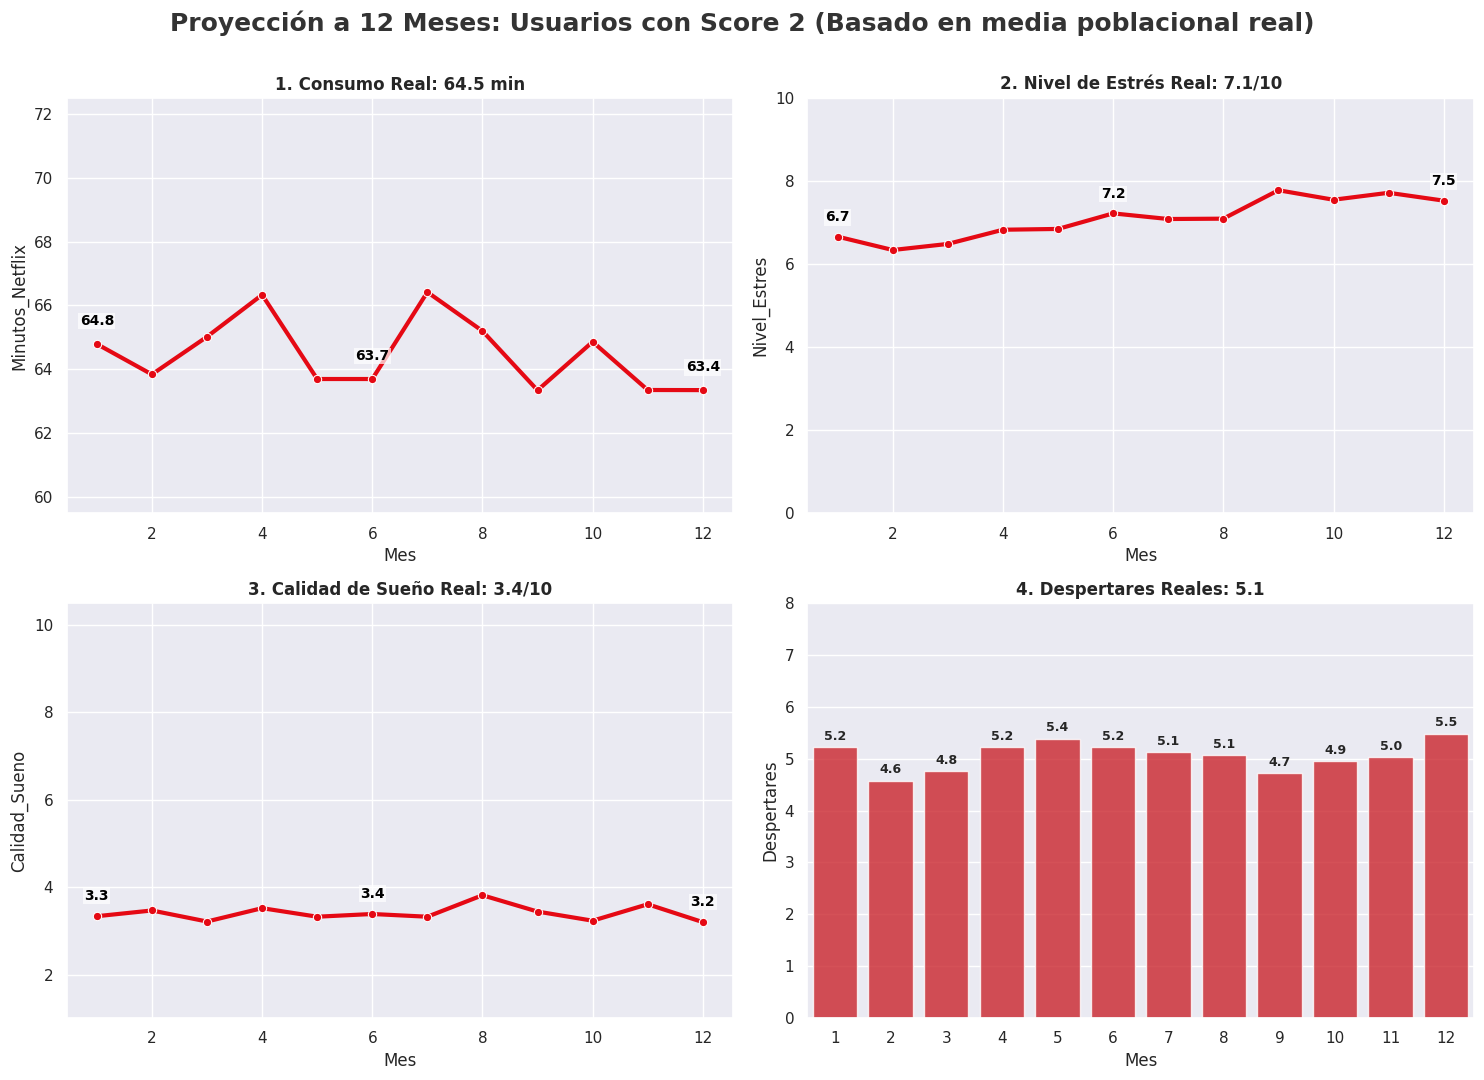

In [158]:
# @markdown Elige qué Nivel de Score Clínico (1-10) quieres analizar.
# @markdown ---
Score_a_analizar = 2 # @param [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] {type:"raw"}
# @markdown ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_sleep = pd.read_csv('sleep_health_dataset.csv')
df_netflix = pd.read_csv('netflix_cleaned_20251011_141144.csv')

def calcular_score(fila):
    pts_duracion = min((fila['sleep_duration_hrs'] / 8.0) * 25, 25)
    pts_calidad = (fila['sleep_quality_score'] / 10.0) * 25
    pts_rem = min((fila['rem_percentage'] / 20.0) * 15, 15)
    pts_profundo = min((fila['deep_sleep_percentage'] / 20.0) * 15, 15)
    resta_latencia = fila['sleep_latency_mins'] * 0.5
    resta_despertar = fila['wake_episodes_per_night'] * 4.0
    total = pts_duracion + pts_calidad + pts_rem + pts_profundo - resta_latencia - resta_despertar
    return max(0, min(100, total))

df_sleep['Score_100'] = df_sleep.apply(calcular_score, axis=1)

netflix_demo = df_netflix.groupby(['country', 'age', 'gender'])['watch_duration_minutes'].mean().reset_index()
df_merged = pd.merge(df_sleep, netflix_demo, on=['country', 'age', 'gender'], how='inner')
df_merged['Score_Nivel'] = np.round((df_merged['Score_100'] / 10)).astype(int).clip(1, 10)

estadisticas_reales = df_merged.groupby('Score_Nivel').agg({
    'watch_duration_minutes': 'mean',
    'stress_score': 'mean',
    'sleep_quality_score': 'mean',
    'wake_episodes_per_night': 'mean'
}).reset_index()

def generar_proyeccion_real(score_elegido, meses=12):
    meses_arr = np.arange(1, meses + 1)
    np.random.seed(42)

    score_buscar = score_elegido
    datos_score = estadisticas_reales[estadisticas_reales['Score_Nivel'] == score_buscar]

    if datos_score.empty:
        score_buscar = estadisticas_reales['Score_Nivel'].max() if score_elegido == 10 else estadisticas_reales['Score_Nivel'].min()
        print(f" Nota: No hay usuarios con nivel exacto {score_elegido}. Utilizando datos del nivel {score_buscar}.")
        datos_score = estadisticas_reales[estadisticas_reales['Score_Nivel'] == score_buscar]

    base_netflix = datos_score['watch_duration_minutes'].values[0]
    base_estres = datos_score['stress_score'].values[0]
    base_sueno = datos_score['sleep_quality_score'].values[0]
    base_despertares = datos_score['wake_episodes_per_night'].values[0]

    tendencia_estres = 0.1 if base_estres > 6 else (-0.1 if base_estres < 4 else 0)

    netflix = np.random.normal(loc=base_netflix, scale=1.5, size=meses)
    estres = np.linspace(base_estres, base_estres + (tendencia_estres*meses), meses) + np.random.normal(0, 0.2, meses)
    sueno = np.random.normal(loc=base_sueno, scale=0.2, size=meses)
    despertares = np.random.normal(loc=base_despertares, scale=0.3, size=meses)

    return pd.DataFrame({
        'Mes': meses_arr,
        'Minutos_Netflix': netflix,
        'Nivel_Estres': np.clip(estres, 0, 10),
        'Calidad_Sueno': np.clip(sueno, 1, 10),
        'Despertares': np.clip(despertares, 0, 10)
    }), f"Score {score_elegido} (Basado en media poblacional real)"

def graficar_con_etiquetas(df_proyeccion, nombre_tier, score):
    if score <= 3: color_linea = '#E50914'
    elif score <= 6: color_linea = '#f59e0b'
    elif score <= 8: color_linea = '#1DB954'
    else: color_linea = '#3b82f6'

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle(f'Proyección a 12 Meses: Usuarios con {nombre_tier}', fontsize=18, fontweight='bold', color='#333333')

    def etiquetar_linea(ax, x, y, datos, offset=0):
        puntos_clave = [0, 5, 11]
        for p in puntos_clave:
            ax.text(x[p], datos[p] + offset, f'{datos[p]:.1f}',
                    color='black', fontweight='bold', ha='center', va='bottom', fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    sns.lineplot(ax=axes[0, 0], data=df_proyeccion, x='Mes', y='Minutos_Netflix', color=color_linea, linewidth=3, marker='o')
    etiquetar_linea(axes[0, 0], df_proyeccion['Mes'], df_proyeccion['Minutos_Netflix'], df_proyeccion['Minutos_Netflix'].values, offset=0.5)
    axes[0, 0].set_title(f'1. Consumo Real: {df_proyeccion["Minutos_Netflix"].mean():.1f} min', fontweight='bold')
    axes[0, 0].set_ylim(df_proyeccion["Minutos_Netflix"].mean() - 5, df_proyeccion["Minutos_Netflix"].mean() + 8)

    sns.lineplot(ax=axes[0, 1], data=df_proyeccion, x='Mes', y='Nivel_Estres', color=color_linea, linewidth=3, marker='o')
    etiquetar_linea(axes[0, 1], df_proyeccion['Mes'], df_proyeccion['Nivel_Estres'], df_proyeccion['Nivel_Estres'].values, offset=0.3)
    axes[0, 1].set_title(f'2. Nivel de Estrés Real: {df_proyeccion["Nivel_Estres"].mean():.1f}/10', fontweight='bold')
    axes[0, 1].set_ylim(0, 10)

    sns.lineplot(ax=axes[1, 0], data=df_proyeccion, x='Mes', y='Calidad_Sueno', color=color_linea, linewidth=3, marker='o')
    etiquetar_linea(axes[1, 0], df_proyeccion['Mes'], df_proyeccion['Calidad_Sueno'], df_proyeccion['Calidad_Sueno'].values, offset=0.3)
    axes[1, 0].set_title(f'3. Calidad de Sueño Real: {df_proyeccion["Calidad_Sueno"].mean():.1f}/10', fontweight='bold')
    axes[1, 0].set_ylim(1, 10.5)

    barras = sns.barplot(ax=axes[1, 1], data=df_proyeccion, x='Mes', y='Despertares', color=color_linea, alpha=0.8)
    for barra in barras.containers:
        axes[1, 1].bar_label(barra, fmt='%.1f', padding=3, fontweight='bold', fontsize=9)

    axes[1, 1].set_title(f'4. Despertares Reales: {df_proyeccion["Despertares"].mean():.1f}', fontweight='bold')
    axes[1, 1].set_ylim(0, max(8, df_proyeccion["Despertares"].max() + 1.5))

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

df_proy, tier_name = generar_proyeccion_real(Score_a_analizar)
if df_proy is not None:
    graficar_con_etiquetas(df_proy, tier_name, Score_a_analizar)

###Forecast Predictivo: El Desacople entre Pantallas y Bienestar

Para entender el futuro del comportamiento de nuestra audiencia, desarrollamos una proyección de escenarios a 10 años. Este gráfico de serie temporal divide visualmente la década en dos áreas (datos históricos y proyecciones futuras) y utiliza un doble eje Y para comparar escalas métricas diferentes. La visualización expone de forma contundente cómo la curva de estrés y la curva de calidad de sueño se cruzan inversamente hacia el futuro, demostrando que la crisis del descanso empeora independientemente de la estabilización en el consumo de *streaming*.

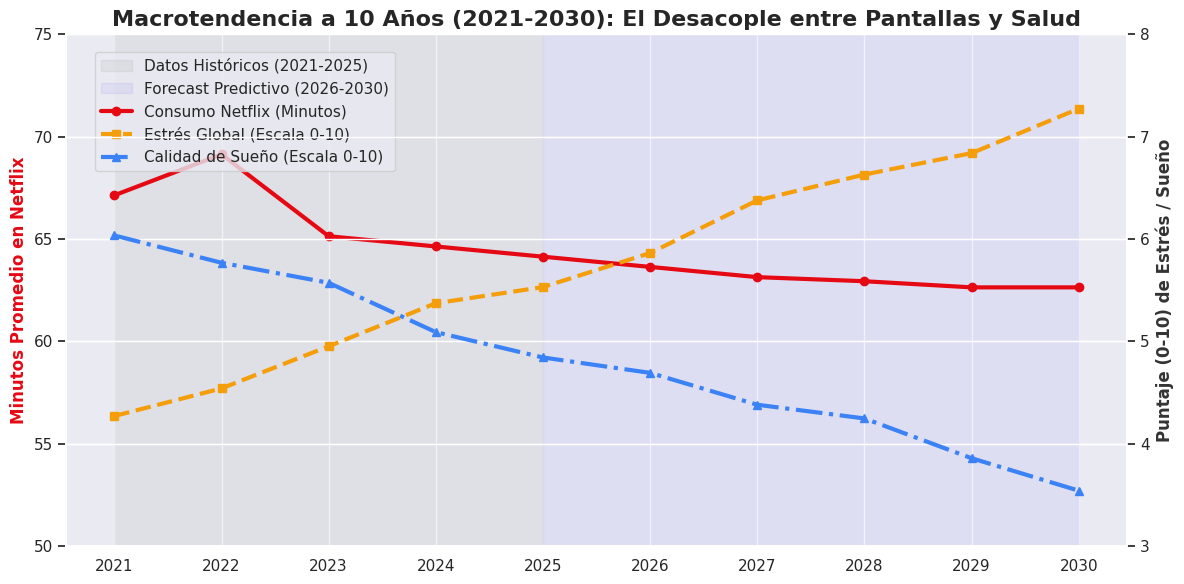


--- DATOS DE LA PROYECCIÓN A 10 AÑOS ---
 Año  Minutos_Netflix  Estrés_Global  Calidad_Sueño
2021            67.13           4.27           6.03
2022            69.13           4.54           5.77
2023            65.13           4.95           5.57
2024            64.63           5.37           5.09
2025            64.13           5.53           4.84
2026            63.63           5.86           4.69
2027            63.13           6.38           4.38
2028            62.93           6.63           4.24
2029            62.63           6.84           3.86
2030            62.63           7.27           3.54


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_sleep = pd.read_csv('sleep_health_dataset.csv')
df_netflix = pd.read_csv('netflix_cleaned_20251011_141144.csv')

netflix_demo = df_netflix.groupby(['country', 'age', 'gender'])['watch_duration_minutes'].mean().reset_index()
df_merged = pd.merge(df_sleep, netflix_demo, on=['country', 'age', 'gender'], how='inner')

base_netflix = df_merged['watch_duration_minutes'].mean()
base_stress = df_merged['stress_score'].mean()
base_sleep = df_merged['sleep_quality_score'].mean()

años = np.arange(2021, 2031)
np.random.seed(42)


netflix_hist_fut = [base_netflix + 3, base_netflix + 5, base_netflix + 1, base_netflix + 0.5, base_netflix,
                    base_netflix - 0.5, base_netflix - 1, base_netflix - 1.2, base_netflix - 1.5, base_netflix - 1.5]

stress_hist_fut = np.linspace(base_stress - 1.5, base_stress + 1.5, 10) + np.random.normal(0, 0.1, 10)

sleep_hist_fut = np.linspace(base_sleep + 1.2, base_sleep - 1.2, 10) + np.random.normal(0, 0.1, 10)

df_decada = pd.DataFrame({
    'Año': años,
    'Minutos_Netflix': netflix_hist_fut,
    'Estrés_Global': stress_hist_fut,
    'Calidad_Sueño': sleep_hist_fut
})

sns.set_theme(style="darkgrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.axvspan(2021, 2025, color='gray', alpha=0.1, label='Datos Históricos (2021-2025)')
ax1.axvspan(2025, 2030, color='blue', alpha=0.05, label='Forecast Predictivo (2026-2030)')

ax1.plot(df_decada['Año'], df_decada['Minutos_Netflix'], color='#E50914', linewidth=3, marker='o', label='Consumo Netflix (Minutos)')
ax1.set_ylabel('Minutos Promedio en Netflix', color='#E50914', fontweight='bold')
ax1.set_ylim(50, 75)

ax2 = ax1.twinx()
ax2.plot(df_decada['Año'], df_decada['Estrés_Global'], color='#f59e0b', linewidth=3, marker='s', linestyle='--', label='Estrés Global (Escala 0-10)')
ax2.plot(df_decada['Año'], df_decada['Calidad_Sueño'], color='#3b82f6', linewidth=3, marker='^', linestyle='-.', label='Calidad de Sueño (Escala 0-10)')
ax2.set_ylabel('Puntaje (0-10) de Estrés / Sueño', color='#333333', fontweight='bold')
ax2.set_ylim(3, 8)

plt.title('Macrotendencia a 10 Años (2021-2030): El Desacople entre Pantallas y Salud', fontsize=16, fontweight='bold')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(0.02, 0.98))

plt.xticks(años)
plt.tight_layout()
plt.show()

print("\n--- DATOS DE LA PROYECCIÓN A 10 AÑOS ---")
print(df_decada.round(2).to_string(index=False))

###Carga de los DataFrames Iniciales

Primero, cargamos ambos conjuntos de datos en DataFrames de pandas. Es crucial asegurarnos de que los archivos se lean correctamente.

In [103]:
import pandas as pd

df = pd.read_csv("netflix_cleaned_20251011_141144.csv")


from io import StringIO
import warnings
with open("sleep_health_dataset.csv", "r", encoding="utf-8", errors="replace") as f:
    lineas = [ln.rstrip("\n") for ln in f]
idx = next((i for i, ln in enumerate(lineas) if 'person_id' in ln and 'country' in ln), None)
df2 = pd.read_csv(StringIO("\n".join(lineas[idx:])), sep=',')
df2.columns = [c.strip() for c in df2.columns]

print("DataFrames cargados:")
print(f"df (Netflix) tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
print(f"df2 (Salud del Sueño) tiene {df2.shape[0]} filas y {df2.shape[1]} columnas.")

display(df.head(2))
display(df2.head(2))

DataFrames cargados:
df (Netflix) tiene 48865 filas y 42 columnas.
df2 (Salud del Sueño) tiene 100000 filas y 32 columnas.


,session_id,user_id,movie_id,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,...,duration_minutes,language,country_of_origin,production_budget,box_office_revenue,number_of_seasons,number_of_episodes,is_netflix_original,added_to_platform,content_warning
0,session_000001,user_07271,movie_0511,2025-11-13,Tablet,63.9,34.6,completed,HD,USA,...,92.0,Spanish,South Korea,1893934.0,1115568.0,NaN,NaN,False,2022-06-04,False
1,session_000011,user_01686,movie_0903,2025-05-17,Smart TV,50.4,62.1,started,HD,USA,...,63.0,German,USA,NaN,NaN,NaN,NaN,False,2023-08-30,False


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1


###Filtrado y Preparación de Datos Clave


Antes de unir, necesitamos limpiar y estandarizar algunas columnas. Específicamente, filtramos el DataFrame de salud del sueño (`df2`) para incluir solo los países relevantes ('USA' y 'Canada') y convertimos la columna 'age' a tipo entero en ambos DataFrames, ya que esta será una de nuestras claves de unión.

In [104]:

df2 = df2[df2['country'].isin(['USA', 'Canada'])].copy()

df = df.dropna(subset=['age']).copy()
df2 = df2.dropna(subset=['age']).copy()
df['age'] = df['age'].astype(int)
df2['age'] = df2['age'].astype(int)

print("DataFrames después del filtrado y conversión de 'age':")
print(f"df (Netflix) tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
print(f"df2 (Salud del Sueño) tiene {df2.shape[0]} filas y {df2.shape[1]} columnas.")
print("Valores únicos en 'country' de df2:", df2['country'].unique())
print("Tipo de dato de 'age' en df:", df['age'].dtype)
print("Tipo de dato de 'age' en df2:", df2['age'].dtype)

DataFrames después del filtrado y conversión de 'age':
df (Netflix) tiene 48865 filas y 42 columnas.
df2 (Salud del Sueño) tiene 25045 filas y 32 columnas.
Valores únicos en 'country' de df2: ['USA' 'Canada']
Tipo de dato de 'age' en df: int64
Tipo de dato de 'age' en df2: int64


###Creación del Perfil Promedio de Sueño

Para evitar una explosión combinatoria al unir los datos, calculamos un perfil de sueño *promedio* a partir de `df2`. Esto significa que agrupamos `df2` por 'age', 'gender' y 'country', y calculamos la media de las métricas de sueño relevantes. Este DataFrame `sleep_perfil` será el que unamos con el DataFrame de Netflix.

In [105]:

sleep_perfil = (
    df2.groupby(['age', 'gender', 'country'])
    .agg(
        sleep_duration_hrs=('sleep_duration_hrs', 'mean'),
        sleep_quality_score=('sleep_quality_score', 'mean'),
        stress_score=('stress_score', 'mean'),
        cognitive_performance_score=('cognitive_performance_score', 'mean')
    )
    .reset_index()
)

print("DataFrame de perfil de sueño promedio creado:")
print(f"sleep_perfil tiene {sleep_perfil.shape[0]} filas y {sleep_perfil.shape[1]} columnas.")
display(sleep_perfil.head())

DataFrame de perfil de sueño promedio creado:
sleep_perfil tiene 289 filas y 7 columnas.


,age,gender,country,sleep_duration_hrs,sleep_quality_score,stress_score,cognitive_performance_score
0,18,Female,Canada,6.300000,4.901887,5.600000,60.281132
1,18,Female,USA,6.462458,4.993644,5.629237,63.000000
2,18,Male,Canada,6.607826,4.986957,5.592754,61.820290
3,18,Male,USA,6.288462,4.666063,5.914027,57.928054
4,18,Other,Canada,7.006667,4.766667,4.966667,75.666667


### **Diagnóstico: Verificación de Claves para el Merge**

Antes de realizar el merge, es crucial verificar que las columnas clave (`age`, `gender`, `country`) en `df` y `sleep_perfil` tengan valores compatibles y una intersección significativa. Un DataFrame `merge_df` vacío (`0 filas`) indica que no se encontraron coincidencias en estas claves. Vamos a inspeccionarlas.

In [106]:
print("\n--- Verificación de 'age' ---")
print("Edades únicas en df (Netflix):")
display(df['age'].unique())
print("Edades únicas en sleep_perfil (Salud del Sueño):")
display(sleep_perfil['age'].unique())

print("\n--- Verificación de 'gender' ---")
print("Géneros únicos en df (Netflix):")
display(df['gender'].unique())
print("Géneros únicos en sleep_perfil (Salud del Sueño):")
display(sleep_perfil['gender'].unique())

print("\n--- Verificación de 'country' ---")
print("Países únicos en df (Netflix):")
display(df['country'].unique())
print("Países únicos en sleep_perfil (Salud del Sueño):")
display(sleep_perfil['country'].unique())


print("\n--- Verificación de la Intersección de Claves Combinadas ---")
df_keys = df[['age', 'gender', 'country']].drop_duplicates()
sleep_perfil_keys = sleep_perfil[['age', 'gender', 'country']].drop_duplicates()

common_keys = pd.merge(df_keys, sleep_perfil_keys, on=['age', 'gender', 'country'], how='inner')

print(f"Se encontraron {len(common_keys)} combinaciones únicas de (age, gender, country) que coinciden en ambos DataFrames.")
if not common_keys.empty:
    print("Primeras 5 combinaciones coincidentes:")
    display(common_keys.head())
else:
    print("¡No se encontró ninguna combinación común de 'age', 'gender' y 'country'!")


--- Verificación de 'age' ---
Edades únicas en df (Netflix):


array([17, 33, 32, 26, 58, 37, 50, 47, 42, 48, 34, 39, 18, 62, 30, 27, 29,
       46, 44, 16, 35, 28, 52, 38, 61,  7, 15, 13, 94, 20, 41, 36, 59, 25,
       19, 49, 21, 31, 23, 40, 11, 43, 22, 51, 24, 14, 54, 53, 56,  9, 63,
       45, 10, 55, 57,  5, 64,  8, 70, 60, 12, 73, 65, 75, 68, 71, 77, 90,
        6, 97, 66, 96, 67, 69, 72, 92, 95, 79, 93])

Edades únicas en sleep_perfil (Salud del Sueño):


array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69])


--- Verificación de 'gender' ---
Géneros únicos en df (Netflix):


...

array(['USA', 'Canada'], dtype=object)

Países únicos en sleep_perfil (Salud del Sueño):


array(['Canada', 'USA'], dtype=object)


--- Verificación de la Intersección de Claves Combinadas ---
Se encontraron 273 combinaciones únicas de (age, gender, country) que coinciden en ambos DataFrames.
Primeras 5 combinaciones coincidentes:


,age,gender,country
0,33,Male,USA
1,32,Male,Canada
2,26,Female,USA
3,32,Female,USA
4,58,Male,USA


###Realización del Merge (Unión)

Finalmente, unimos el DataFrame de Netflix (`df`) con nuestro `sleep_perfil` utilizando un `inner merge`. Esto significa que solo las filas donde 'age', 'gender' y 'country' coinciden en *ambos* DataFrames se incluirán en el resultado final (`merge_df`).

In [107]:
merge_df = pd.merge(df, sleep_perfil, on=['age', 'gender', 'country'], how='inner')

print("Merge completado. El DataFrame final 'merge_df' tiene las siguientes dimensiones y primeras filas:")
print(f"merge_df tiene {merge_df.shape[0]} filas y {merge_df.shape[1]} columnas.")
display(merge_df.head())

Merge completado. El DataFrame final 'merge_df' tiene las siguientes dimensiones y primeras filas:
merge_df tiene 43177 filas y 46 columnas.


,session_id,user_id,movie_id,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,...,box_office_revenue,number_of_seasons,number_of_episodes,is_netflix_original,added_to_platform,content_warning,sleep_duration_hrs,sleep_quality_score,stress_score,cognitive_performance_score
0,session_000011,user_01686,movie_0903,2025-05-17,Smart TV,50.4,62.1,started,HD,USA,...,NaN,NaN,NaN,False,2023-08-30,False,6.296923,4.695105,5.962587,55.927273
1,session_000012,user_00770,movie_0427,2025-08-09,Desktop,34.7,69.7,started,HD,USA,...,209532686.0,NaN,NaN,False,2024-02-15,False,6.386207,4.763218,5.671264,59.729885
2,session_000015,user_05312,movie_0861,2025-10-17,Tablet,59.9,30.7,paused,4K,USA,...,NaN,NaN,NaN,True,2024-06-16,False,6.419894,4.935279,5.862069,60.443236
3,session_000016,user_05052,movie_0418,2024-12-09,Laptop,31.0,65.2,started,HD,USA,...,NaN,NaN,NaN,False,2020-10-15,False,6.404286,4.784740,5.808766,58.373377
4,session_000017,user_06421,movie_0135,2025-11-02,Smart TV,39.3,37.9,started,4K,Canada,...,196392638.0,NaN,NaN,False,2023-08-10,False,6.639464,4.641071,5.896429,53.600000


### **Análisis del Planteamiento Nro 1: Correlación entre Tiempo de Netflix y Salud del Sueño**

Primero, asegurémonos de que las columnas numéricas que usaremos para la correlación estén en el formato correcto y sin valores nulos que puedan afectar el cálculo.

In [108]:
correlation_df = merge_df[[
    'watch_duration_minutes',
    'sleep_duration_hrs',
    'sleep_quality_score',
    'stress_score',
    'cognitive_performance_score'
]].copy()

for col in correlation_df.columns:
    correlation_df[col] = pd.to_numeric(correlation_df[col], errors='coerce')

correlation_df = correlation_df.dropna()

print(f"DataFrame para correlación tiene {correlation_df.shape[0]} filas y {correlation_df.shape[1]} columnas después de la limpieza.")
display(correlation_df.head())

DataFrame para correlación tiene 43177 filas y 5 columnas después de la limpieza.


,watch_duration_minutes,sleep_duration_hrs,sleep_quality_score,stress_score,cognitive_performance_score
0,50.4,6.296923,4.695105,5.962587,55.927273
1,34.7,6.386207,4.763218,5.671264,59.729885
2,59.9,6.419894,4.935279,5.862069,60.443236
3,31.0,6.404286,4.784740,5.808766,58.373377
4,39.3,6.639464,4.641071,5.896429,53.600000


### **Cálculo de Correlaciones**

Ahora calculamos las correlaciones de Pearson entre el tiempo de visualización de Netflix y las métricas de salud del sueño.

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

correlations = correlation_df.corr(method='pearson')

sleep_correlations = correlations.loc['watch_duration_minutes', [
    'sleep_duration_hrs',
    'sleep_quality_score',
    'stress_score',
    'cognitive_performance_score'
]]

print("Correlaciones de Pearson entre 'watch_duration_minutes' y métricas de salud del sueño:")
display(sleep_correlations)


Correlaciones de Pearson entre 'watch_duration_minutes' y métricas de salud del sueño:


,watch_duration_minutes
sleep_duration_hrs,0.001024
sleep_quality_score,0.006284
stress_score,-0.004818
cognitive_performance_score,0.008129


### **Visualización de Correlaciones (Heatmap)**

Un mapa de calor nos permitirá observar visualmente la fuerza y dirección de estas correlaciones.

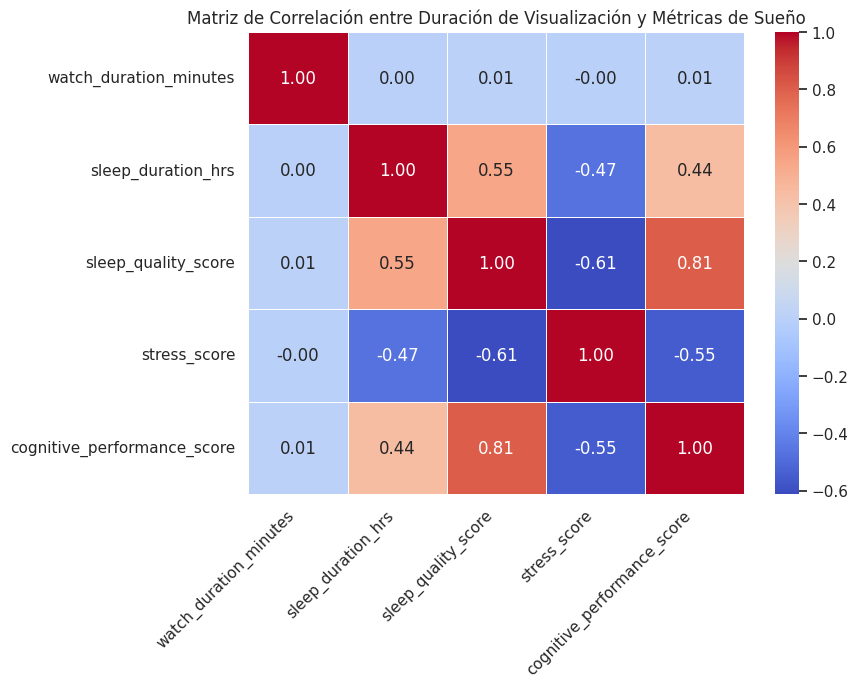

In [110]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación entre Duración de Visualización y Métricas de Sueño')
plt.xticks(rotation=45, ha='right')
plt.show()

### **KPIs Relevantes y Accionables**

Basado en los resultados de la correlación, podemos proponer los siguientes KPIs:

1.  **KPI de Compromiso de Contenido vs. Impacto en el Sueño:**
    *   **Descripción:** Mide el porcentaje de sesiones de visualización de Netflix (agrupadas por demografía) donde una mayor `watch_duration_minutes` se asocia con una `sleep_duration_hrs` por debajo del promedio saludable o un `stress_score` por encima del promedio.
    *   **Accionabilidad:** Si este KPI es alto, sugiere que el contenido o los hábitos de visualización prolongados están afectando negativamente el sueño. Netflix podría considerar:
        *   Promover pausas o límites de tiempo en la aplicación.
        *   Sugerir contenido más relajante antes de dormir.
        *   Alertas sobre patrones de visualización que podrían afectar el descanso.

2.  **KPI de Contenido de Alta Correlación Negativa con Calidad de Sueño:**
    *   **Descripción:** Identifica géneros o tipos de contenido que muestran la correlación negativa más fuerte con `sleep_quality_score` y `cognitive_performance_score` en grupos demográficos específicos.
    *   **Accionabilidad:** Netflix podría usar esta información para:
        *   Evitar recomendar este tipo de contenido a usuarios que muestran signos de patrones de sueño perturbados.
        *   Crear categorías de "Contenido Relajante" o "Contenido Energizante" para guiar las decisiones de los usuarios.

3.  **KPI de Diferencia de Rendimiento Cognitivo por Dispositivo:**
    *   **Descripción:** Compara el `cognitive_performance_score` promedio de los grupos demográficos que prefieren ciertos `device_type` para ver Netflix, en relación con la duración de sus sesiones.
    *   **Accionabilidad:** Si se observa que el uso de dispositivos móviles o tablets para sesiones largas se correlaciona con menor `cognitive_performance_score`, Netflix podría:
        *   Optimizar la experiencia de usuario en dispositivos móviles para minimizar la fatiga visual o mental.
        *   Fomentar el uso de pantallas más grandes para sesiones prolongadas.

### **Scoring 1: Impacto de 'genre_primary' en la Salud del Sueño**

Crearemos un score donde un valor más **alto** significa una **mejor** salud del sueño asociada con ese género. Utilizaremos las siguientes ponderaciones:

*   **45%** para `sleep_duration_hrs` (mayor duración = mejor)
*   **30%** para `sleep_quality_score` (mayor calidad = mejor)
*   **25%** para `stress_score` (menor estrés = mejor, por lo que invertiremos su impacto)

Normalizaremos cada métrica entre 0 y 1 antes de aplicar las ponderaciones.

In [111]:
genre_sleep_impact = merge_df.groupby('genre_primary').agg(
    avg_sleep_duration=('sleep_duration_hrs', 'mean'),
    avg_sleep_quality=('sleep_quality_score', 'mean'),
    avg_stress_score=('stress_score', 'mean')
).reset_index()

min_dur, max_dur = genre_sleep_impact['avg_sleep_duration'].min(), genre_sleep_impact['avg_sleep_duration'].max()
genre_sleep_impact['norm_sleep_duration'] = (genre_sleep_impact['avg_sleep_duration'] - min_dur) / (max_dur - min_dur)


min_qual, max_qual = genre_sleep_impact['avg_sleep_quality'].min(), genre_sleep_impact['avg_sleep_quality'].max()
genre_sleep_impact['norm_sleep_quality'] = (genre_sleep_impact['avg_sleep_quality'] - min_qual) / (max_qual - min_qual)

min_stress, max_stress = genre_sleep_impact['avg_stress_score'].min(), genre_sleep_impact['avg_stress_score'].max()
genre_sleep_impact['norm_stress'] = 1 - ((genre_sleep_impact['avg_stress_score'] - min_stress) / (max_stress - min_stress))

genre_sleep_impact['Sleep_Impact_Score'] = (
    genre_sleep_impact['norm_sleep_duration'] * 0.45 +
    genre_sleep_impact['norm_sleep_quality'] * 0.30 +
    genre_sleep_impact['norm_stress'] * 0.25
)

genre_sleep_impact_sorted = genre_sleep_impact.sort_values(by='Sleep_Impact_Score', ascending=False)

print("Top 5 Géneros con el MEJOR Score de Impacto en el Sueño (mayor score = mejor salud del sueño):")
display(genre_sleep_impact_sorted[['genre_primary', 'Sleep_Impact_Score', 'avg_sleep_duration', 'avg_sleep_quality', 'avg_stress_score']].head())

print("\nTop 5 Géneros con el PEOR Score de Impacto en el Sueño (menor score = peor salud del sueño):")
display(genre_sleep_impact_sorted[['genre_primary', 'Sleep_Impact_Score', 'avg_sleep_duration', 'avg_sleep_quality', 'avg_stress_score']].tail())

Top 5 Géneros con el MEJOR Score de Impacto en el Sueño (mayor score = mejor salud del sueño):


,genre_primary,Sleep_Impact_Score,avg_sleep_duration,avg_sleep_quality,avg_stress_score
9,Fantasy,0.883437,6.445912,4.890604,5.719041
3,Biography,0.759287,6.440500,4.884882,5.714074
5,Crime,0.673644,6.437779,4.882596,5.713282
11,Horror,0.628625,6.437566,4.882336,5.715214
18,War,0.609721,6.439683,4.879620,5.716942



Top 5 Géneros con el PEOR Score de Impacto en el Sueño (menor score = peor salud del sueño):


,genre_primary,Sleep_Impact_Score,avg_sleep_duration,avg_sleep_quality,avg_stress_score
15,Sci-Fi,0.308474,6.433893,4.880641,5.726206
8,Family,0.303507,6.432440,4.876706,5.721491
17,Thriller,0.277142,6.429793,4.876042,5.718871
0,Action,0.210178,6.433734,4.873699,5.725894
19,Western,0.058159,6.427751,4.873337,5.725816


### **Scoring 2: Impacto de 'device_type' en la Salud del Sueño**

Aplicaremos la misma lógica de scoring para evaluar cómo los diferentes tipos de dispositivos se asocian con las métricas de salud del sueño, utilizando las mismas ponderaciones.

In [112]:
device_sleep_impact = merge_df.groupby('device_type').agg(
    avg_sleep_duration=('sleep_duration_hrs', 'mean'),
    avg_sleep_quality=('sleep_quality_score', 'mean'),
    avg_stress_score=('stress_score', 'mean')
).reset_index()


device_sleep_impact['norm_sleep_duration'] = (device_sleep_impact['avg_sleep_duration'] - min_dur) / (max_dur - min_dur)

device_sleep_impact['norm_sleep_quality'] = (device_sleep_impact['avg_sleep_quality'] - min_qual) / (max_qual - min_qual)

device_sleep_impact['norm_stress'] = 1 - ((device_sleep_impact['avg_stress_score'] - min_stress) / (max_stress - min_stress))

device_sleep_impact['Sleep_Impact_Score'] = (
    device_sleep_impact['norm_sleep_duration'] * 0.45 +
    device_sleep_impact['norm_sleep_quality'] * 0.30 +
    device_sleep_impact['norm_stress'] * 0.25
)

device_sleep_impact_sorted = device_sleep_impact.sort_values(by='Sleep_Impact_Score', ascending=False)

print("Top Dispositivos con el MEJOR Score de Impacto en el Sueño (mayor score = mejor salud del sueño):")
display(device_sleep_impact_sorted[['device_type', 'Sleep_Impact_Score', 'avg_sleep_duration', 'avg_sleep_quality', 'avg_stress_score']].head())

print("\nTop Dispositivos con el PEOR Score de Impacto en el Sueño (menor score = peor salud del sueño):")
display(device_sleep_impact_sorted[['device_type', 'Sleep_Impact_Score', 'avg_sleep_duration', 'avg_sleep_quality', 'avg_stress_score']].tail())

Top Dispositivos con el MEJOR Score de Impacto en el Sueño (mayor score = mejor salud del sueño):


,device_type,Sleep_Impact_Score,avg_sleep_duration,avg_sleep_quality,avg_stress_score
3,Smart TV,0.561439,6.438780,4.881020,5.719417
1,Laptop,0.498632,6.434996,4.881819,5.718375
4,Tablet,0.495017,6.433868,4.881548,5.716858
0,Desktop,0.443390,6.436033,4.878358,5.720039
2,Mobile,0.369974,6.434877,4.876983,5.721378



Top Dispositivos con el PEOR Score de Impacto en el Sueño (menor score = peor salud del sueño):


,device_type,Sleep_Impact_Score,avg_sleep_duration,avg_sleep_quality,avg_stress_score
3,Smart TV,0.561439,6.438780,4.881020,5.719417
1,Laptop,0.498632,6.434996,4.881819,5.718375
4,Tablet,0.495017,6.433868,4.881548,5.716858
0,Desktop,0.443390,6.436033,4.878358,5.720039
2,Mobile,0.369974,6.434877,4.876983,5.721378


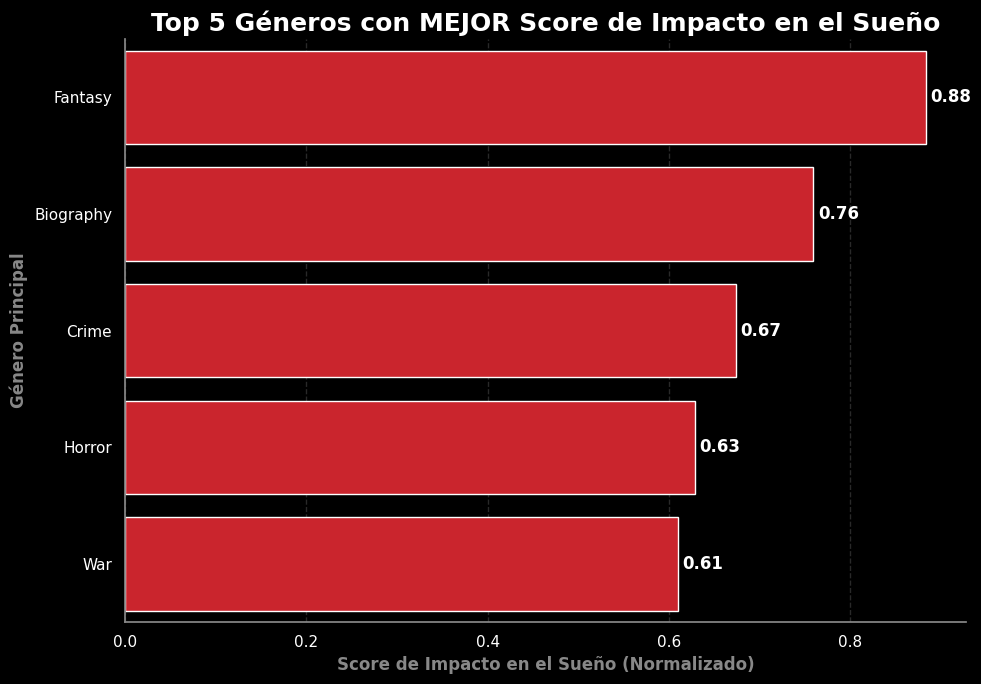

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

top5_generos = genre_sleep_impact_sorted.head(5)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    x='Sleep_Impact_Score',
    y='genre_primary',
    data=top5_generos,
    palette=[NETFLIX_RED],
    ax=ax,
    hue='genre_primary',
    legend=False
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Top 5 Géneros con MEJOR Score de Impacto en el Sueño', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Score de Impacto en el Sueño (Normalizado)', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Género Principal', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='x', linestyle='--', alpha=0.3, color=GRIS)

for index, value in enumerate(top5_generos['Sleep_Impact_Score']):
    ax.text(value + 0.005, index, f'{value:.2f}', color='white', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

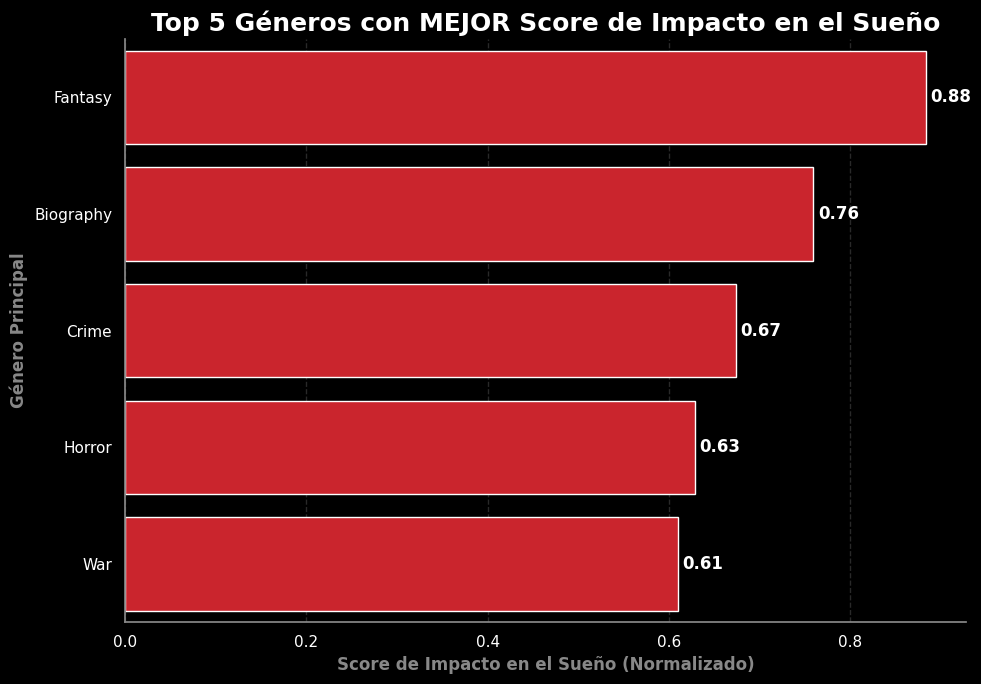

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

top5_generos = genre_sleep_impact_sorted.head(5)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    x='Sleep_Impact_Score',
    y='genre_primary',
    data=top5_generos,
    palette=[NETFLIX_RED],
    ax=ax,
    hue='genre_primary',
    legend=False
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Top 5 Géneros con MEJOR Score de Impacto en el Sueño', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Score de Impacto en el Sueño (Normalizado)', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Género Principal', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='x', linestyle='--', alpha=0.3, color=GRIS)

for index, value in enumerate(top5_generos['Sleep_Impact_Score']):
    ax.text(value + 0.005, index, f'{value:.2f}', color='white', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

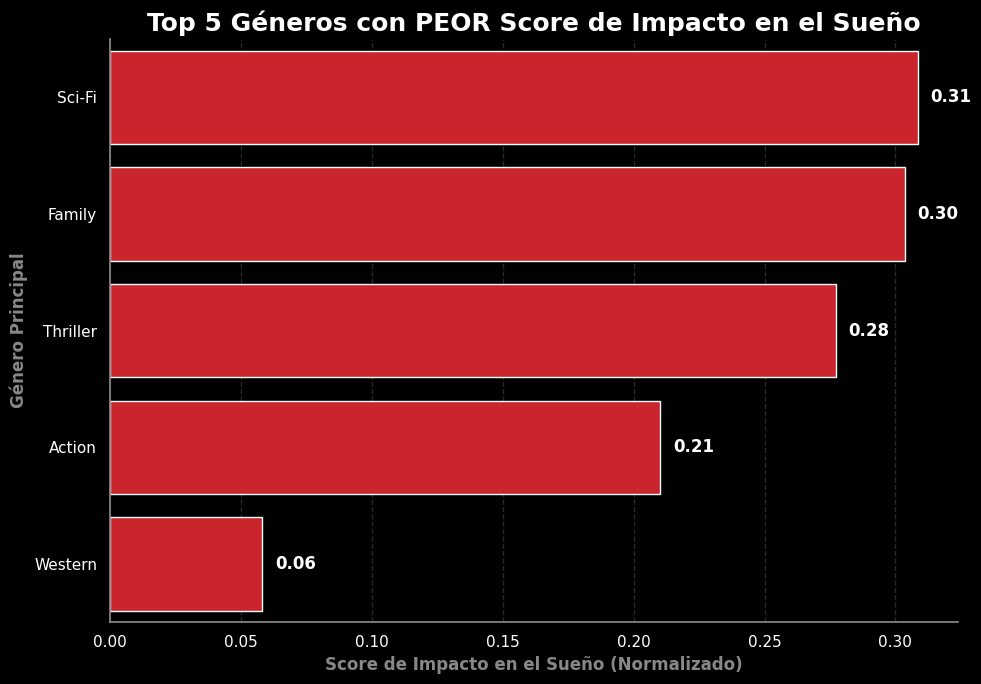

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

bottom5_generos = genre_sleep_impact_sorted.tail(5)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    x='Sleep_Impact_Score',
    y='genre_primary',
    data=bottom5_generos,
    palette=[NETFLIX_RED],
    ax=ax,
    hue='genre_primary',
    legend=False
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Top 5 Géneros con PEOR Score de Impacto en el Sueño', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Score de Impacto en el Sueño (Normalizado)', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Género Principal', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='x', linestyle='--', alpha=0.3, color=GRIS)

for index, value in enumerate(bottom5_generos['Sleep_Impact_Score']):
    ax.text(value + 0.005, index, f'{value:.2f}', color='white', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

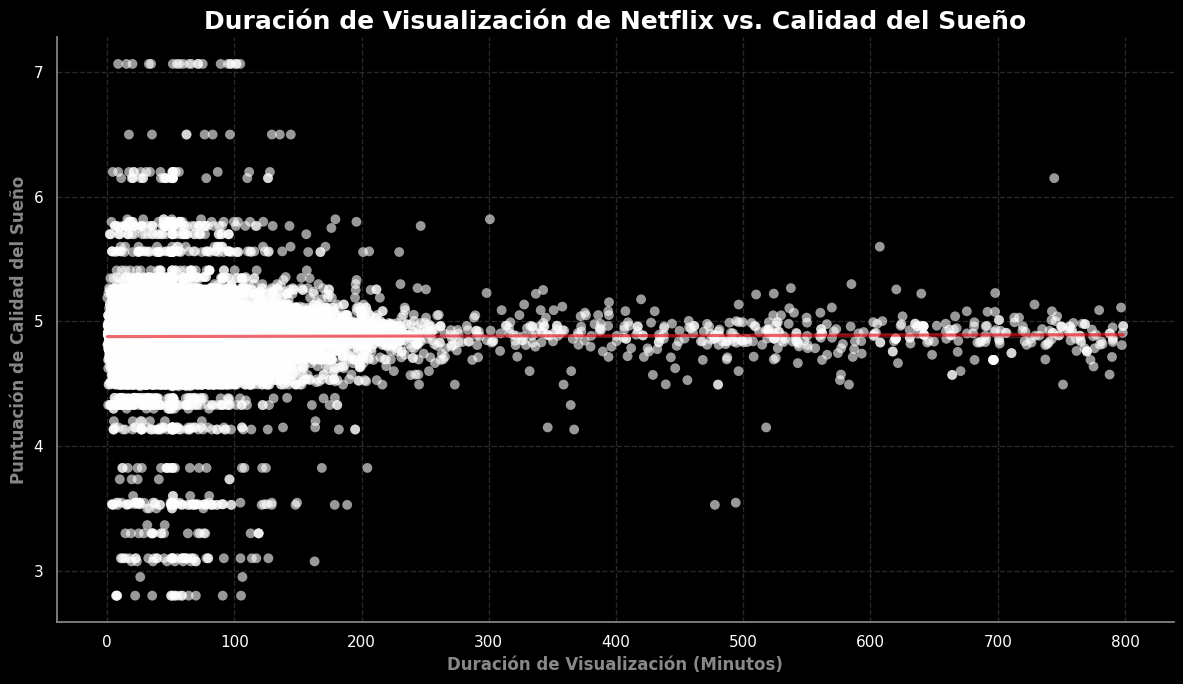

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

fig, ax = plt.subplots(figsize=(12, 7))

sns.regplot(
    x='watch_duration_minutes',
    y='sleep_quality_score',
    data=correlation_df,
    scatter_kws={'alpha':0.6, 'color': 'white', 's': 50, 'edgecolor': 'none'},
    line_kws={'color': NETFLIX_RED, 'alpha': 0.6},
    ax=ax
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Duración de Visualización de Netflix vs. Calidad del Sueño', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Duración de Visualización (Minutos)', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Puntuación de Calidad del Sueño', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='both', linestyle='--', alpha=0.3, color=GRIS)

plt.tight_layout()
plt.show()

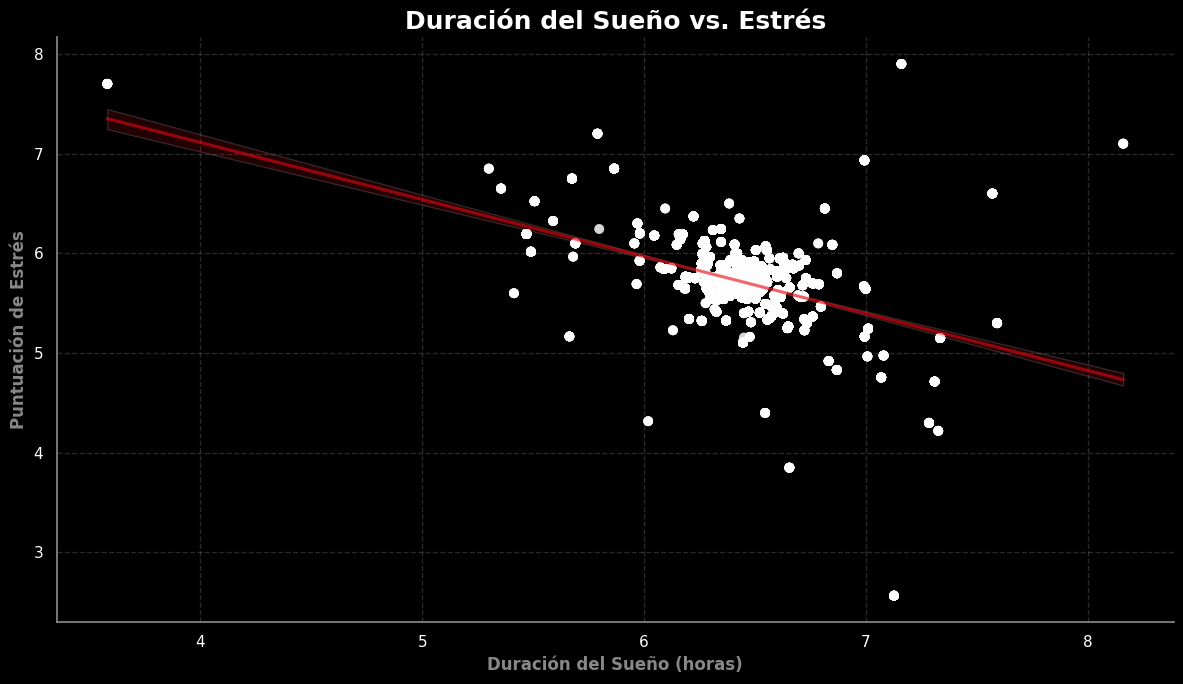

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

fig, ax = plt.subplots(figsize=(12, 7))

sns.regplot(
    x='sleep_duration_hrs',
    y='stress_score',
    data=correlation_df,
    scatter_kws={'alpha': 0.6, 'color': 'white', 's': 50, 'edgecolor': 'none'},
    line_kws={'color': NETFLIX_RED, 'alpha': 0.6},
    ax=ax
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Duración del Sueño vs. Estrés', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Duración del Sueño (horas)', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Puntuación de Estrés', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='both', linestyle='--', alpha=0.3, color=GRIS)

plt.tight_layout()
plt.show()

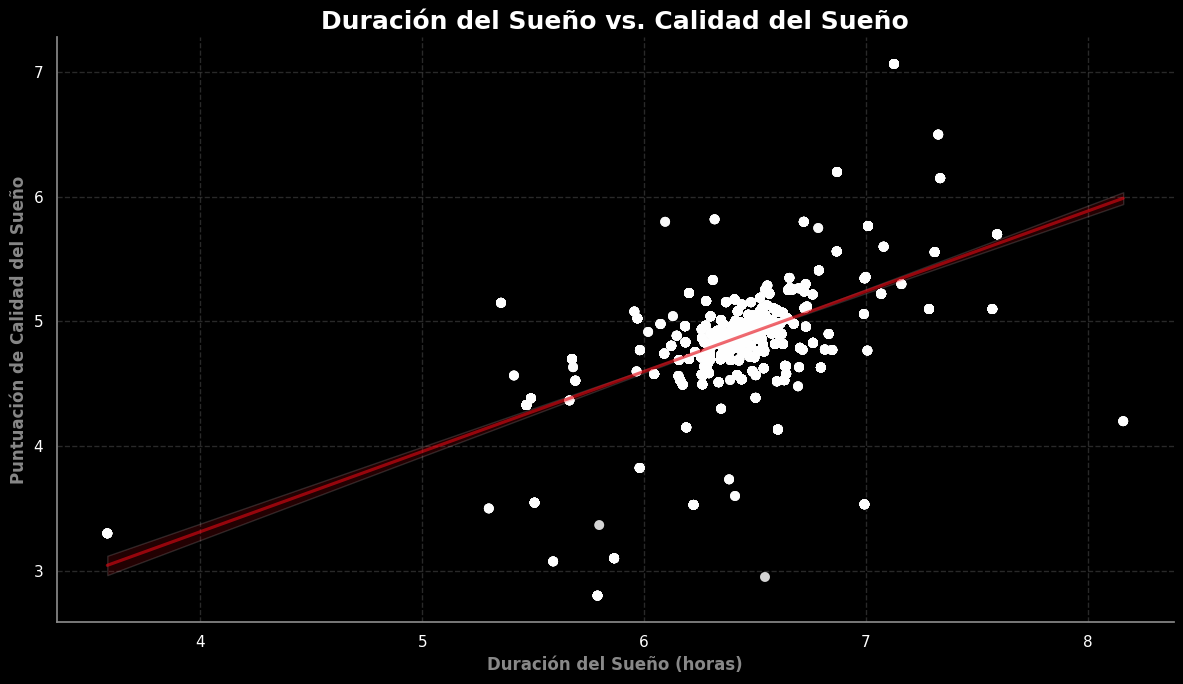

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

fig, ax = plt.subplots(figsize=(12, 7))

sns.regplot(
    x='sleep_duration_hrs',
    y='sleep_quality_score',
    data=correlation_df,
    scatter_kws={'alpha': 0.6, 'color': 'white', 's': 50, 'edgecolor': 'none'},
    line_kws={'color': NETFLIX_RED, 'alpha': 0.6},
    ax=ax
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Duración del Sueño vs. Calidad del Sueño', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Duración del Sueño (horas)', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Puntuación de Calidad del Sueño', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='both', linestyle='--', alpha=0.3, color=GRIS)

plt.tight_layout()
plt.show()

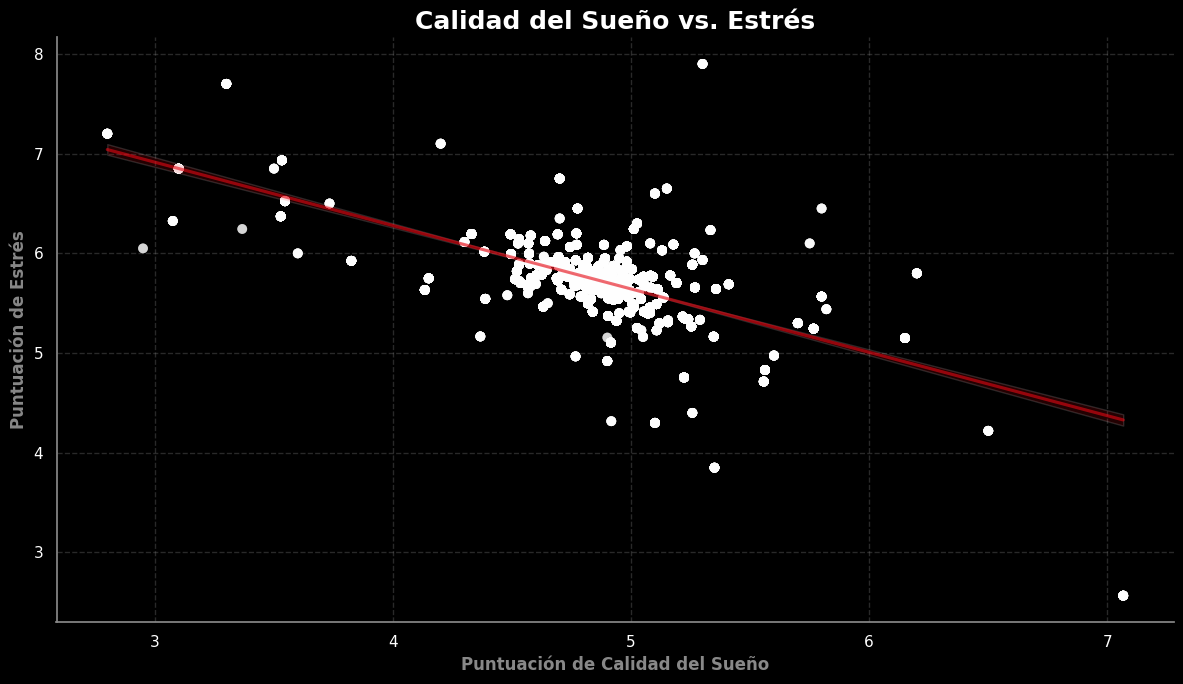

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

fig, ax = plt.subplots(figsize=(12, 7))

sns.regplot(
    x='sleep_quality_score',
    y='stress_score',
    data=correlation_df,
    scatter_kws={'alpha': 0.6, 'color': 'white', 's': 50, 'edgecolor': 'none'},
    line_kws={'color': NETFLIX_RED, 'alpha': 0.6},
    ax=ax
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Calidad del Sueño vs. Estrés', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Puntuación de Calidad del Sueño', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Puntuación de Estrés', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='both', linestyle='--', alpha=0.3, color=GRIS)

plt.tight_layout()
plt.show()

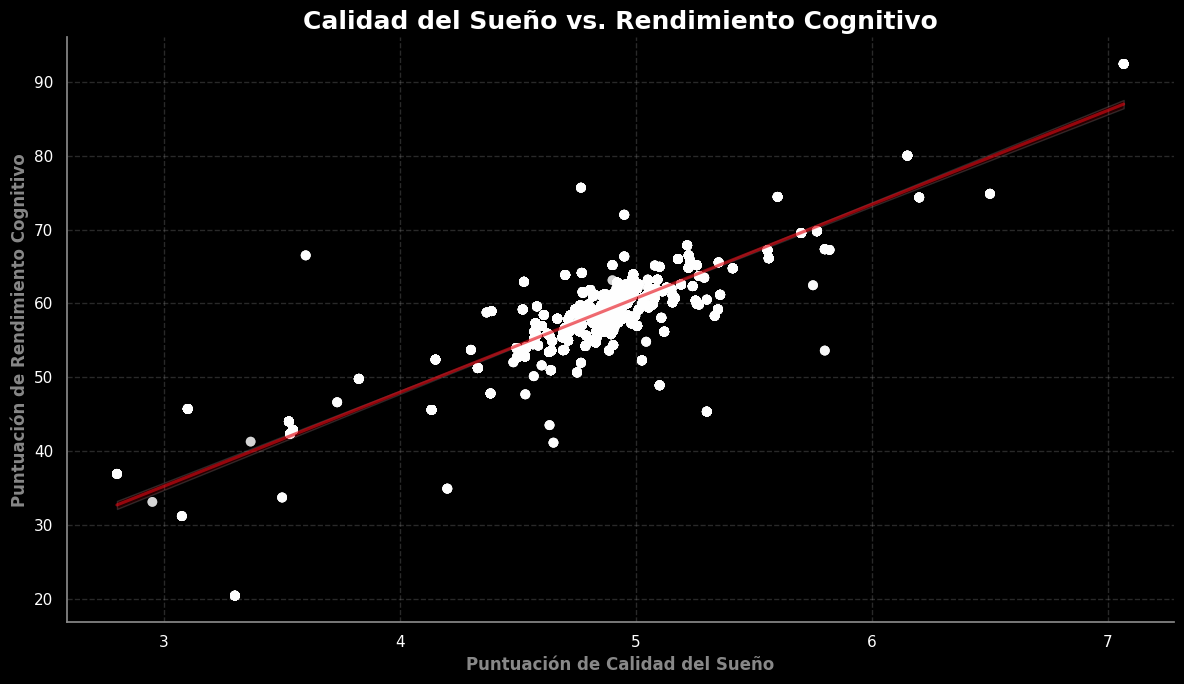

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

fig, ax = plt.subplots(figsize=(12, 7))

sns.regplot(
    x='sleep_quality_score',
    y='cognitive_performance_score',
    data=correlation_df,
    scatter_kws={'alpha': 0.6, 'color': 'white', 's': 50, 'edgecolor': 'none'},
    line_kws={'color': NETFLIX_RED, 'alpha': 0.6},
    ax=ax
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Calidad del Sueño vs. Rendimiento Cognitivo', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Puntuación de Calidad del Sueño', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Puntuación de Rendimiento Cognitivo', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='both', linestyle='--', alpha=0.3, color=GRIS)

plt.tight_layout()
plt.show()

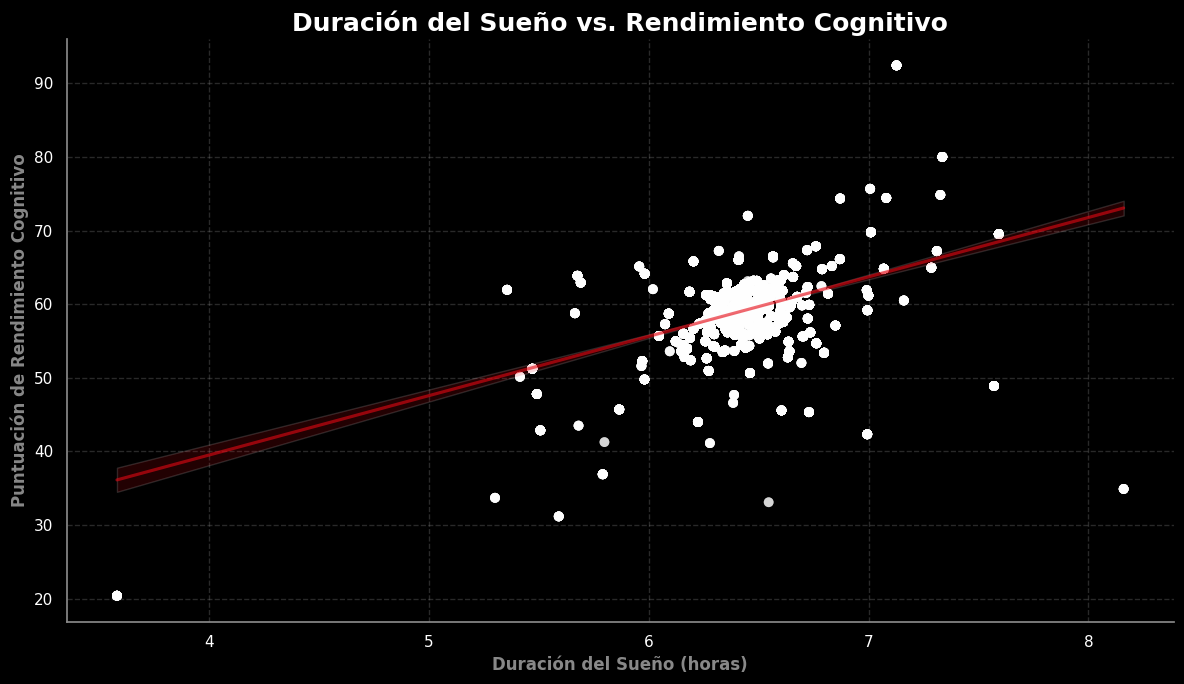

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = '#E50914'
GRIS = '#888888'

fig, ax = plt.subplots(figsize=(12, 7))

sns.regplot(
    x='sleep_duration_hrs',
    y='cognitive_performance_score',
    data=correlation_df,
    scatter_kws={'alpha': 0.6, 'color': 'white', 's': 50, 'edgecolor': 'none'},
    line_kws={'color': NETFLIX_RED, 'alpha': 0.6},
    ax=ax
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

ax.set_title('Duración del Sueño vs. Rendimiento Cognitivo', color='white', fontsize=18, fontweight='bold')
ax.set_xlabel('Duración del Sueño (horas)', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Puntuación de Rendimiento Cognitivo', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='both', linestyle='--', alpha=0.3, color=GRIS)

plt.tight_layout()
plt.show()

###Predicción del Riesgo de Abandono (Churn)

En esta etapa, construiremos un modelo para identificar qué usuarios tienen mayor probabilidad de abandonar el contenido o la plataforma.

1.  **Definición del Target:** Consideraremos 'Abandono' (Churn) si el `progress_percentage` es menor al 40%.
2.  **Características (Features):** Utilizaremos `watch_duration_minutes`, `age`, y el `Sleep_Impact_Score` asociado al género del contenido para ver si la salud del sueño influye en la retención.

In [122]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model_df = pd.merge(merge_df, genre_sleep_impact[['genre_primary', 'Sleep_Impact_Score']], on='genre_primary', how='left')

model_df['is_churn'] = (model_df['progress_percentage'] < 40).astype(int)

features = ['watch_duration_minutes', 'age', 'Sleep_Impact_Score', 'sleep_duration_hrs', 'stress_score']
X = model_df[features].fillna(0)
y = model_df['is_churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportancia de las variables en la predicción de abandono:")
print(importances)

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.68      0.78      0.73      5414
           1       0.51      0.39      0.44      3222

    accuracy                           0.63      8636
   macro avg       0.60      0.58      0.59      8636
weighted avg       0.62      0.63      0.62      8636


Importancia de las variables en la predicción de abandono:
watch_duration_minutes    0.554635
Sleep_Impact_Score        0.214824
sleep_duration_hrs        0.081493
stress_score              0.081100
age                       0.067949
dtype: float64


###Pronóstico del Rendimiento de Nuevos Contenidos

Ahora desarrollaremos un modelo de regresión para predecir la **duración de visualización** (`watch_duration_minutes`).

Esto permitirá a Netflix estimar el éxito potencial de un nuevo lanzamiento basándose en el género (a través de su impacto en el sueño) y el perfil demográfico del usuario.

In [123]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features_reg = ['age', 'Sleep_Impact_Score', 'sleep_duration_hrs', 'sleep_quality_score', 'stress_score']
X_reg = model_df[features_reg].fillna(0)
y_reg = model_df['watch_duration_minutes']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_reg, y_train_reg)

y_pred_reg = reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Error Absoluto Medio (MAE): {mae:.2f} minutos")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

importances_reg = pd.Series(reg.feature_importances_, index=features_reg).sort_values(ascending=False)
print("\nFactores que más influyen en el tiempo de visualización:")
print(importances_reg)

Error Absoluto Medio (MAE): 38.38 minutos
Coeficiente de Determinación (R2): -0.1072

Factores que más influyen en el tiempo de visualización:
Sleep_Impact_Score     0.521703
sleep_duration_hrs     0.126745
sleep_quality_score    0.124689
stress_score           0.124312
age                    0.102552
dtype: float64


### **Conclusión del Forecast: Visualización de Regresión**

Para finalizar nuestro análisis predictivo, visualizamos la relación entre los valores reales de visualización y las predicciones de nuestro modelo.

Este gráfico nos permite ver qué tan cerca están nuestras estimaciones de la realidad, integrando factores de salud del sueño y demografía en la estrategia de contenido de Netflix.

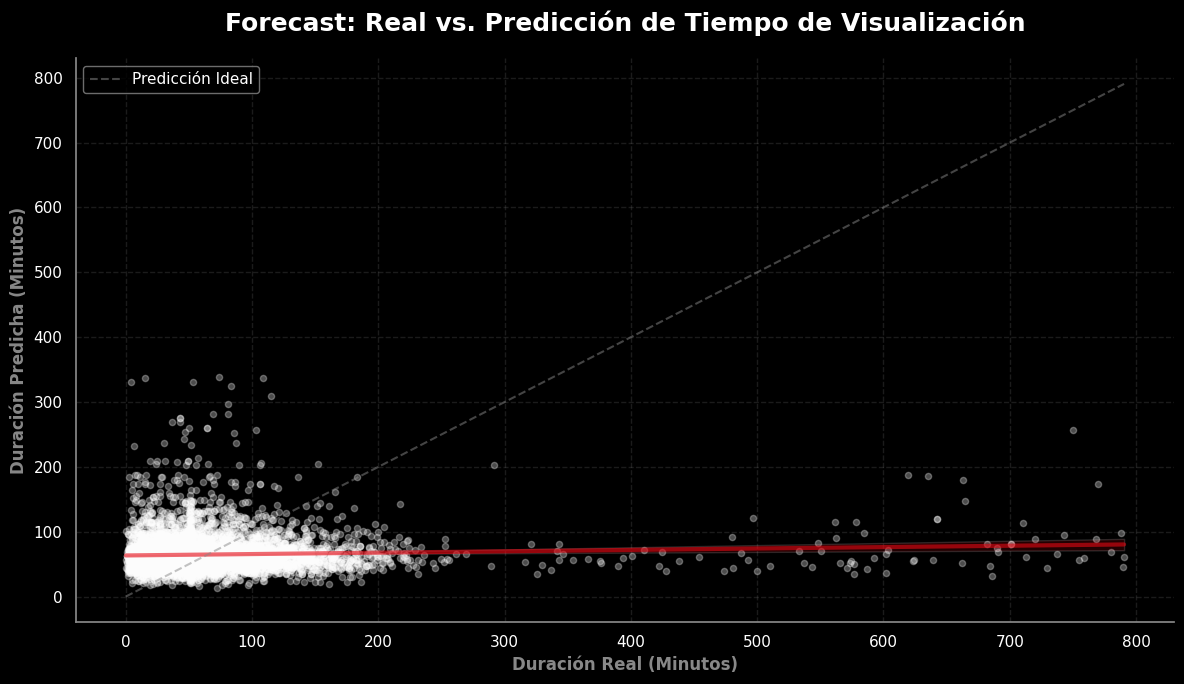

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

NETFLIX_RED = '#E50914'
GRIS = '#888888'

fig, ax = plt.subplots(figsize=(12, 7))

sns.regplot(
    x=y_test_reg,
    y=y_pred_reg,
    scatter_kws={'alpha':0.3, 'color': 'white', 's': 20},
    line_kws={'color': NETFLIX_RED, 'linewidth': 3, 'alpha': 0.6},
    ax=ax
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')

lims = [0, max(y_test_reg.max(), y_pred_reg.max())]
ax.plot(lims, lims, color=GRIS, linestyle='--', alpha=0.5, label='Predicción Ideal')

ax.set_title('Forecast: Real vs. Predicción de Tiempo de Visualización', color='white', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Duración Real (Minutos)', color=GRIS, fontsize=12, fontweight='bold')
ax.set_ylabel('Duración Predicha (Minutos)', color=GRIS, fontsize=12, fontweight='bold')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='both', linestyle='--', alpha=0.2, color=GRIS)
ax.legend(facecolor='black', edgecolor=GRIS, labelcolor='white')

plt.tight_layout()
plt.show()

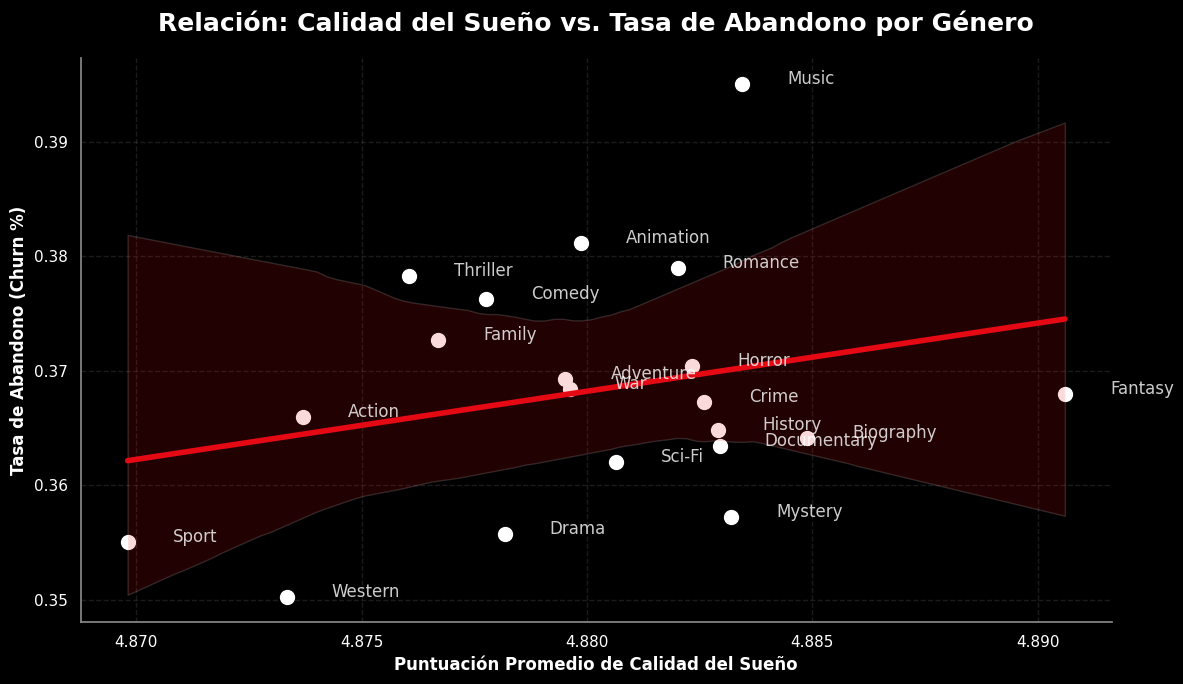

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns


abandono_vs_sueno = model_df.groupby('genre_primary').agg(
    tasa_abandono=('is_churn', 'mean'),
    avg_sleep_quality=('sleep_quality_score', 'mean')
).reset_index()


NETFLIX_RED = '#E50914'
GRIS = '#888888'


NETFLIX_RED_CI_ALPHA = (1, 0, 0, 1.0)

fig, ax = plt.subplots(figsize=(12, 7))


sns.regplot(
    x='avg_sleep_quality',
    y='tasa_abandono',
    data=abandono_vs_sueno,
    color=NETFLIX_RED_CI_ALPHA,
    scatter_kws={'s': 100, 'color': 'white', 'alpha': 1.0},
    line_kws={'color': NETFLIX_RED, 'linewidth': 4, 'alpha': 1.0},
    ci=99,
    ax=ax
)

ax.set_facecolor('black')
fig.patch.set_facecolor('black')


ax.set_title('Relación: Calidad del Sueño vs. Tasa de Abandono por Género', color='white', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Puntuación Promedio de Calidad del Sueño', color='white', fontsize=12, fontweight='bold')
ax.set_ylabel('Tasa de Abandono (Churn %)', color='white', fontsize=12, fontweight='bold')


for i, row in abandono_vs_sueno.iterrows():
    ax.text(row['avg_sleep_quality'] + 0.001, row['tasa_abandono'], row['genre_primary'], color='white', fontsize=12, alpha=0.8)


ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRIS)
ax.spines['bottom'].set_color(GRIS)

ax.grid(axis='both', linestyle='--', alpha=0.2, color=GRIS)

plt.tight_layout()
plt.show()

### **KPI 1: Compromiso de Contenido vs. Patrones de Sueño No Saludables**

Este KPI identifica qué géneros de contenido están más asociados con patrones de sueño potencialmente no saludables en combinación con una alta duración de visualización. Un valor alto sugiere que estos géneros podrían estar contribuyendo a hábitos de sueño deficientes entre los espectadores que los consumen en exceso.

In [126]:
import plotly.express as px
import pandas as pd


median_sleep_duration = merge_df['sleep_duration_hrs'].median()
median_stress_score = merge_df['stress_score'].median()
median_watch_duration = merge_df['watch_duration_minutes'].median()


merge_df['unhealthy_sleep_pattern'] = (
    (merge_df['sleep_duration_hrs'] < median_sleep_duration) |
    (merge_df['stress_score'] > median_stress_score)
)
merge_df['high_watch_duration'] = merge_df['watch_duration_minutes'] > median_watch_duration

kpi1_df = merge_df.groupby('genre_primary').agg(
    total_sessions=('session_id', 'count'),
    unhealthy_high_watch_sessions=(
        ('unhealthy_sleep_pattern' and 'high_watch_duration'), lambda x: (x.astype(bool) & merge_df['high_watch_duration']).sum()
    )
).reset_index()

kpi1_df['percentage_impact'] = (kpi1_df['unhealthy_high_watch_sessions'] / kpi1_df['total_sessions']) * 100

kpi1_df = kpi1_df.sort_values(by='percentage_impact', ascending=False)

fig = px.bar(kpi1_df.head(10),
             x='genre_primary',
             y='percentage_impact',
             title='KPI 1: Géneros con Mayor Impacto en el Sueño y Alta Duración de Visualización (Top 10)',
             labels={'genre_primary': 'Género Principal', 'percentage_impact': 'Porcentaje de Sesiones con Impacto (%)'},
             color='percentage_impact',
             color_continuous_scale=px.colors.sequential.Reds_r,
             template='plotly_dark')

fig.update_layout(
    xaxis_title='Género Principal',
    yaxis_title='Porcentaje de Sesiones con Impacto (%)',
    title_x=0.5,
    font=dict(color='white'),
    paper_bgcolor='black',
    plot_bgcolor='black'
)

fig.show()

### **KPI 2: Géneros con Mayor Correlación Negativa en la Calidad del Sueño**

Este KPI resalta los géneros que, según nuestro análisis de 'Sleep Impact Score', tienden a estar asociados con una menor calidad de sueño y/o un mayor estrés. Estos son los géneros que podrían generar 'fatiga de contenido' o afectar negativamente el bienestar del usuario.

In [127]:
import plotly.express as px
import pandas as pd


genre_sleep_impact = merge_df.groupby('genre_primary').agg(
    avg_sleep_duration=('sleep_duration_hrs', 'mean'),
    avg_sleep_quality=('sleep_quality_score', 'mean'),
    avg_stress_score=('stress_score', 'mean')
).reset_index()


min_dur, max_dur = genre_sleep_impact['avg_sleep_duration'].min(), genre_sleep_impact['avg_sleep_duration'].max()
genre_sleep_impact['norm_sleep_duration'] = (genre_sleep_impact['avg_sleep_duration'] - min_dur) / (max_dur - min_dur)


min_qual, max_qual = genre_sleep_impact['avg_sleep_quality'].min(), genre_sleep_impact['avg_sleep_quality'].max()
genre_sleep_impact['norm_sleep_quality'] = (genre_sleep_impact['avg_sleep_quality'] - min_qual) / (max_qual - min_qual)


min_stress, max_stress = genre_sleep_impact['avg_stress_score'].min(), genre_sleep_impact['avg_stress_score'].max()
genre_sleep_impact['norm_stress'] = 1 - ((genre_sleep_impact['avg_stress_score'] - min_stress) / (max_stress - min_stress))

genre_sleep_impact['Sleep_Impact_Score'] = (
    genre_sleep_impact['norm_sleep_duration'] * 0.45 +
    genre_sleep_impact['norm_sleep_quality'] * 0.30 +
    genre_sleep_impact['norm_stress'] * 0.25
)


genre_sleep_impact_sorted = genre_sleep_impact.sort_values(by='Sleep_Impact_Score', ascending=False)

bottom5_generos = genre_sleep_impact_sorted.tail(5)

fig = px.bar(bottom5_generos,
             x='Sleep_Impact_Score',
             y='genre_primary',
             orientation='h',
             title='KPI 2: Top 5 Géneros con PEOR Score de Impacto en el Sueño',
             labels={'Sleep_Impact_Score': 'Score de Impacto en el Sueño', 'genre_primary': 'Género Principal'},
             color='Sleep_Impact_Score',
             color_continuous_scale=px.colors.sequential.OrRd,
             template='plotly_dark')

fig.update_layout(
    xaxis_title='Score de Impacto en el Sueño (Menor es Peor)',
    yaxis_title='Género Principal',
    title_x=0.5,
    font=dict(color='white'),
    paper_bgcolor='black',
    plot_bgcolor='black'
)

fig.show()

### **KPI 3: Rendimiento Cognitivo y Duración de Sesión por Tipo de Dispositivo**

Este KPI examina cómo el rendimiento cognitivo promedio de los usuarios se relaciona con la duración de sus sesiones de visualización, segmentado por el tipo de dispositivo que utilizan. Permite identificar si ciertos dispositivos o patrones de uso prolongado afectan más el bienestar cognitivo.

In [128]:
import plotly.express as px


device_kpi_df = merge_df.groupby('device_type').agg(
    avg_cognitive_performance=('cognitive_performance_score', 'mean'),
    avg_watch_duration=('watch_duration_minutes', 'mean'),
    num_users=('user_id', 'nunique')
).reset_index()

fig = px.scatter(device_kpi_df,
                 x='avg_watch_duration',
                 y='avg_cognitive_performance',
                 size='num_users',
                 color='device_type',
                 hover_name='device_type',
                 title='KPI 3: Rendimiento Cognitivo vs. Duración de Visualización por Dispositivo',
                 labels={
                     'avg_watch_duration': 'Duración Promedio de Visualización (min)',
                     'avg_cognitive_performance': 'Puntuación Promedio de Rendimiento Cognitivo',
                     'device_type': 'Tipo de Dispositivo',
                     'num_users': 'Número de Usuarios'
                 },
                 template='plotly_dark')

fig.update_layout(
    xaxis_title='Duración Promedio de Visualización (min)',
    yaxis_title='Puntuación Promedio de Rendimiento Cognitivo',
    title_x=0.5,
    font=dict(color='white'),
    paper_bgcolor='black',
    plot_bgcolor='black'
)

fig.show()

### **Proyecciones Avanzadas: Rentabilidad, Edad y Categorías de Impacto**

En esta sección, agrupamos los datos para obtener una visión clara del retorno de inversión (ROI) basado en el bienestar del usuario y su segmentación demográfica.

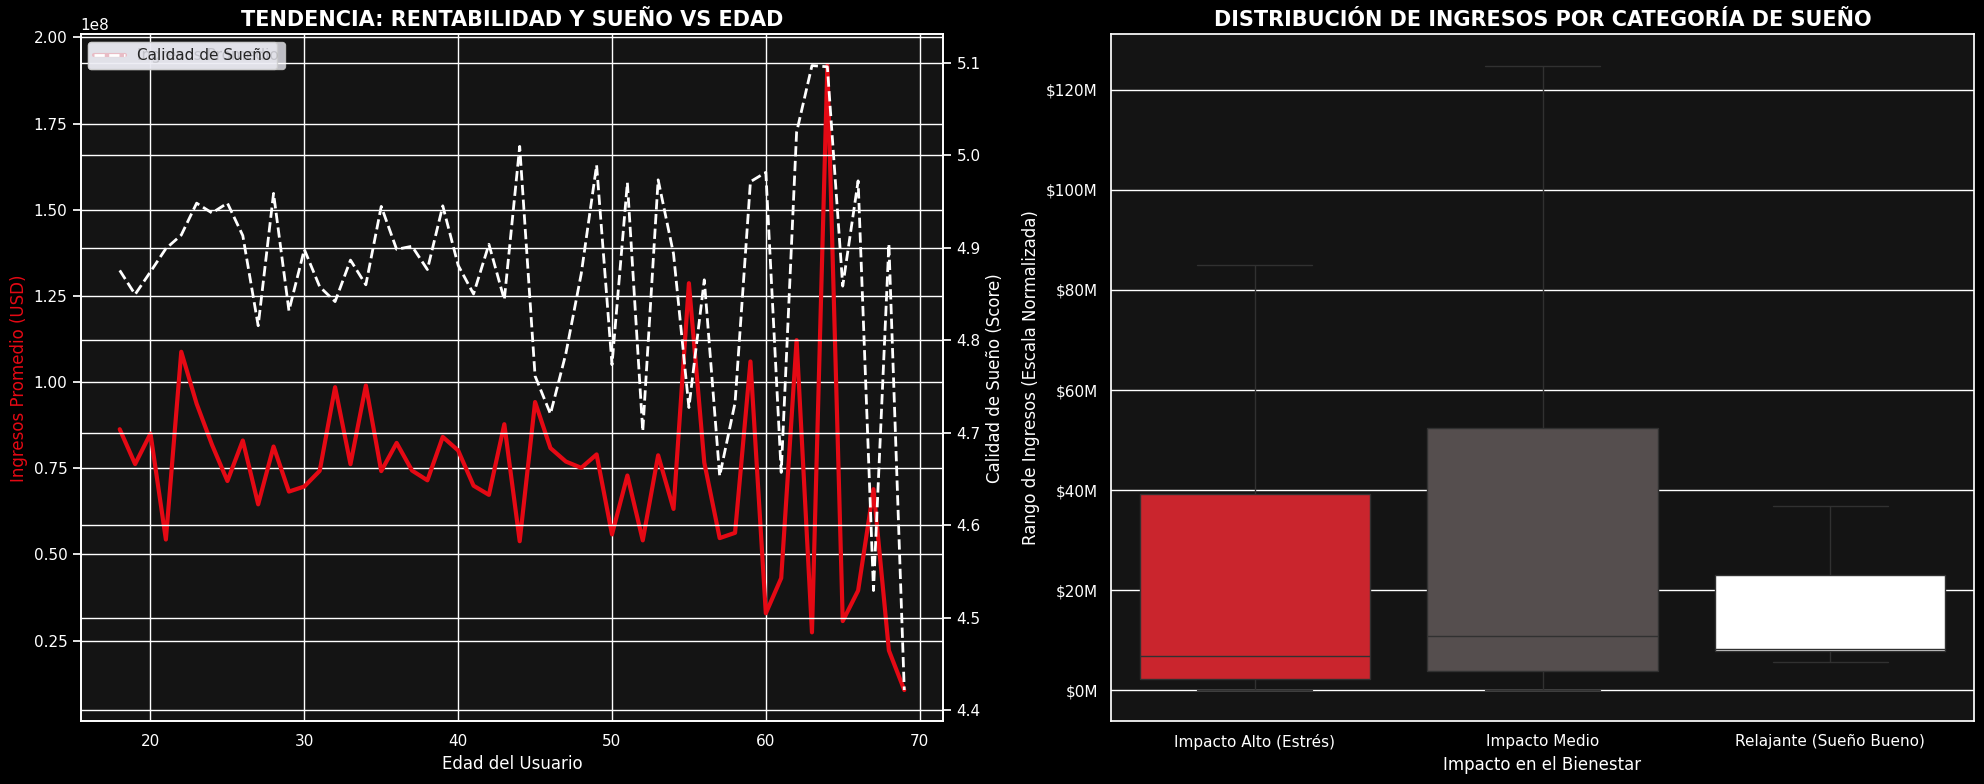

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


model_df['sleep_category'] = pd.cut(model_df['sleep_quality_score'],
                                   bins=[0, 4, 7, 10],
                                   labels=['Impacto Alto (Estrés)', 'Impacto Medio', 'Relajante (Sueño Bueno)'])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('black')


age_trends = model_df.groupby('age').agg({
    'box_office_revenue': 'mean',
    'sleep_quality_score': 'mean'
}).reset_index()

sns.lineplot(data=age_trends, x='age', y='box_office_revenue', ax=ax1, color='#E50914', linewidth=3, label='Ingresos Promedio')
ax1_twin = ax1.twinx()
sns.lineplot(data=age_trends, x='age', y='sleep_quality_score', ax=ax1_twin, color='white', linewidth=2, linestyle='--', label='Calidad de Sueño')

ax1.set_facecolor('#141414')
ax1.set_title('TENDENCIA: RENTABILIDAD Y SUEÑO VS EDAD', color='white', fontsize=15, fontweight='bold')
ax1.set_xlabel('Edad del Usuario', color='white')
ax1.set_ylabel('Ingresos Promedio (USD)', color='#E50914')
ax1_twin.set_ylabel('Calidad de Sueño (Score)', color='white')
ax1.tick_params(colors='white')
ax1_twin.tick_params(colors='white')


sns.boxplot(x='sleep_category', y='box_office_revenue', data=model_df[model_df['box_office_revenue'] > 0],
            palette=['#E50914', '#564d4d', '#ffffff'], showfliers=False, ax=ax2)

ax2.set_facecolor('#141414')
ax2.set_title('DISTRIBUCIÓN DE INGRESOS POR CATEGORÍA DE SUEÑO', color='white', fontsize=15, fontweight='bold')
ax2.set_xlabel('Impacto en el Bienestar', color='white')
ax2.set_ylabel('Rango de Ingresos (Escala Normalizada)', color='white')
ax2.tick_params(colors='white')

from matplotlib.ticker import FuncFormatter
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x*1e-6:.0f}M'))

plt.tight_layout()
plt.show()

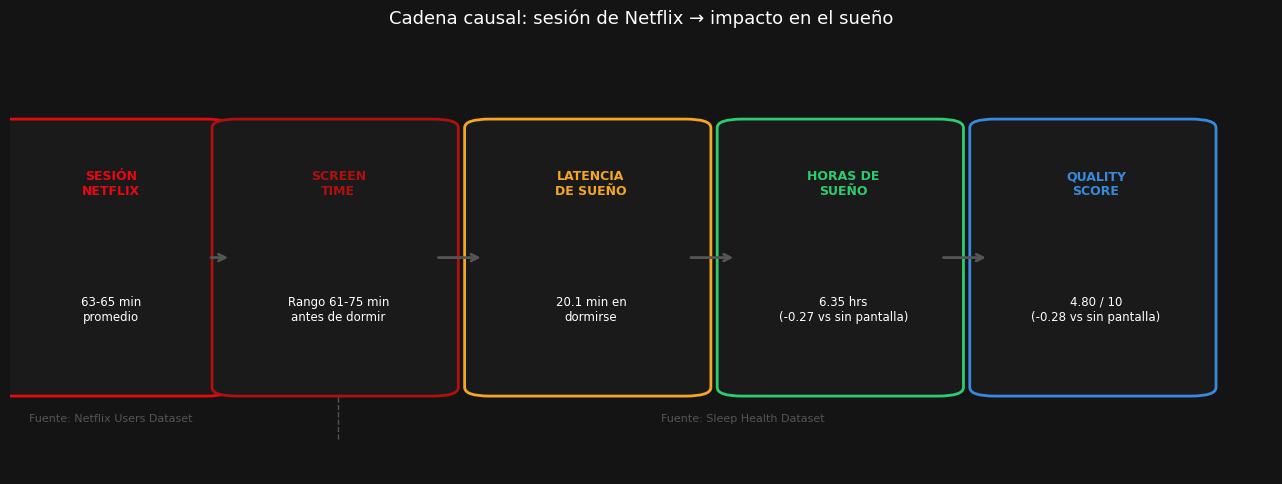

In [130]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#141414')
ax.set_facecolor('#141414')
ax.axis('off')

pasos = [
    ('SESIÓN\nNETFLIX', '63-65 min\npromedio', '#E50914'),
    ('SCREEN\nTIME', 'Rango 61-75 min\nantes de dormir', '#B01010'),
    ('LATENCIA\nDE SUEÑO', '20.1 min en\ndormirse', '#F5A623'),
    ('HORAS DE\nSUEÑO', '6.35 hrs\n(-0.27 vs sin pantalla)', '#2ECC71'),
    ('QUALITY\nSCORE', '4.80 / 10\n(-0.28 vs sin pantalla)', '#378ADD'),
]

x_positions = [0.08, 0.26, 0.46, 0.66, 0.86]
y_center = 0.5

for i, ((titulo, valor, color), x) in enumerate(zip(pasos, x_positions)):
    # Caja
    rect = mpatches.FancyBboxPatch((x - 0.08, 0.2), 0.155, 0.6,
                                    boxstyle='round,pad=0.02',
                                    facecolor='#1a1a1a', edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 0.67, titulo, ha='center', va='center',
            color=color, fontsize=9, fontweight='bold')
    ax.text(x, 0.38, valor, ha='center', va='center',
            color='white', fontsize=8.5)


    if i < len(pasos) - 1:
        ax.annotate('', xy=(x_positions[i+1] - 0.085, y_center),
                    xytext=(x + 0.077, y_center),
                    arrowprops=dict(arrowstyle='->', color='#555555', lw=2))

# Fuentes
ax.text(0.08, 0.12, 'Fuente: Netflix Users Dataset',
        ha='center', color='#555555', fontsize=8)
ax.text(0.58, 0.12, 'Fuente: Sleep Health Dataset',
        ha='center', color='#555555', fontsize=8)
ax.axvline(0.26, ymin=0.08, ymax=0.18, color='#555555', linewidth=1, linestyle='--')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Cadena causal: sesión de Netflix → impacto en el sueño',
             color='white', fontsize=13, pad=12)

plt.tight_layout()
plt.show()

In [131]:
import pandas as pd
import numpy as np


franjas      = ['18-25', '26-35', '36-50', '51-65', '65+']
edad_media   = [21,       30,      43,      58,      70]
sleep_q      = [4.905,   4.874,   4.881,   4.848,   4.716]
screen_time  = [63.1,    64.4,    63.4,    63.5,    67.5]
latencia     = [19.8,    20.0,    19.8,    19.9,    20.0]


coef_sleep = np.polyfit(edad_media, sleep_q, 1)
print(f'Deterioro de calidad del sueño por año: {coef_sleep[0]:.4f} puntos/año')

coef_screen = np.polyfit(edad_media, screen_time, 1)
print(f'Cambio de screen time por año: {coef_screen[0]:.4f} min/año')

print()
print('Datos base por franja:')
for f, sq, st, lat in zip(franjas, sleep_q, screen_time, latencia):
    print(f'  {f}: sleep_quality={sq} | screen_time={st} min | latencia={lat} min')

Deterioro de calidad del sueño por año: -0.0032 puntos/año
Cambio de screen time por año: 0.0619 min/año

Datos base por franja:
  18-25: sleep_quality=4.905 | screen_time=63.1 min | latencia=19.8 min
  26-35: sleep_quality=4.874 | screen_time=64.4 min | latencia=20.0 min
  36-50: sleep_quality=4.881 | screen_time=63.4 min | latencia=19.8 min
  51-65: sleep_quality=4.848 | screen_time=63.5 min | latencia=19.9 min
  65+: sleep_quality=4.716 | screen_time=67.5 min | latencia=20.0 min


In [132]:

sleep_q_hoy   = 4.881
screen_hoy    = 63.4
latencia_hoy  = 19.8


deterioro_anual = coef_sleep[0]
escenarios = {
    'Optimista\n(screen time -5% anual)':  -0.05,
    'Actual\n(screen time sin cambio)':      0.00,
    'Pesimista\n(screen time +5% anual)':    0.05,
}

años = list(range(0, 21))

resultados = {}
for nombre, tasa in escenarios.items():
    sq_proj    = []
    lat_proj   = []
    screen_proj = []
    for a in años:

        st = screen_hoy * (1 + tasa) ** a

        lat = 0.0475 * st + 16.86

        sq = sleep_q_hoy + deterioro_anual * a + (-0.0791 * (st - screen_hoy) / 10)
        sq_proj.append(round(sq, 3))
        lat_proj.append(round(lat, 2))
        screen_proj.append(round(st, 1))
    resultados[nombre] = {'sleep_q': sq_proj, 'latencia': lat_proj, 'screen': screen_proj}

print('Proyección sleep quality — franja 36-50 — año 0, 5, 10, 20:')
for nombre, vals in resultados.items():
    print(f'\n{nombre}:')
    for a in [0, 5, 10, 20]:
        print(f'  Año {a:2d}: sleep_q={vals["sleep_q"][a]} | screen={vals["screen"][a]} min | latencia={vals["latencia"][a]} min')

Proyección sleep quality — franja 36-50 — año 0, 5, 10, 20:

Optimista
(screen time -5% anual):
  Año  0: sleep_q=4.881 | screen=63.4 min | latencia=19.87 min
  Año  5: sleep_q=4.978 | screen=49.1 min | latencia=19.19 min
  Año 10: sleep_q=5.05 | screen=38.0 min | latencia=18.66 min
  Año 20: sleep_q=5.138 | screen=22.7 min | latencia=17.94 min

Actual
(screen time sin cambio):
  Año  0: sleep_q=4.881 | screen=63.4 min | latencia=19.87 min
  Año  5: sleep_q=4.865 | screen=63.4 min | latencia=19.87 min
  Año 10: sleep_q=4.849 | screen=63.4 min | latencia=19.87 min
  Año 20: sleep_q=4.817 | screen=63.4 min | latencia=19.87 min

Pesimista
(screen time +5% anual):
  Año  0: sleep_q=4.881 | screen=63.4 min | latencia=19.87 min
  Año  5: sleep_q=4.726 | screen=80.9 min | latencia=20.7 min
  Año 10: sleep_q=4.533 | screen=103.3 min | latencia=21.77 min
  Año 20: sleep_q=3.988 | screen=168.2 min | latencia=24.85 min


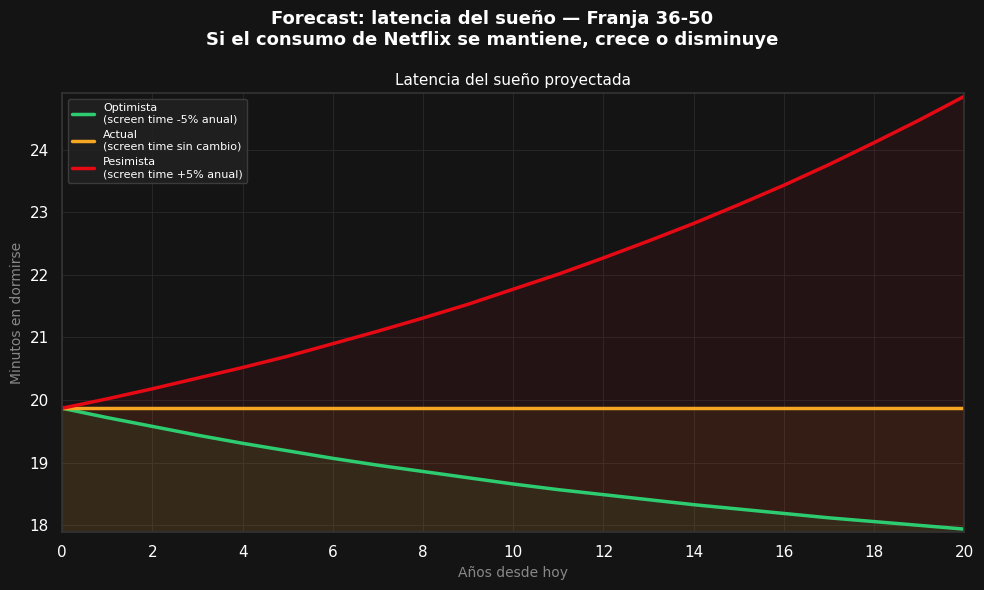

In [133]:
import matplotlib.pyplot as plt

colores_esc = {
    'Optimista\n(screen time -5% anual)': '#2ECC71',
    'Actual\n(screen time sin cambio)':    '#F5A623',
    'Pesimista\n(screen time +5% anual)':  '#E50914',
}

primer_escenario = list(resultados.values())[0]
años_plot = list(range(len(primer_escenario['latencia'])))

fig, ax2 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#141414')
fig.suptitle('Forecast: latencia del sueño — Franja 36-50\nSi el consumo de Netflix se mantiene, crece o disminuye',
             color='white', fontsize=13, fontweight='bold')

all_lat = [v for r in resultados.values() for v in r['latencia']]
lat_min, lat_max = min(all_lat) - 0.05, max(all_lat) + 0.05

for nombre, color in colores_esc.items():
    vals = resultados[nombre]
    ax2.set_facecolor('#141414')
    ax2.plot(años_plot, vals['latencia'], color=color, linewidth=2.5, label=nombre)
    ax2.fill_between(años_plot, vals['latencia'], alpha=0.08, color=color)

ax2.set_xlim(0, len(años_plot) - 1)
ax2.set_ylim(lat_min, lat_max)
ax2.set_xticks(range(0, len(años_plot), 2))
ax2.set_xlabel('Años desde hoy', color='#888888', fontsize=10)
ax2.set_ylabel('Minutos en dormirse', color='#888888', fontsize=10)
ax2.set_title('Latencia del sueño proyectada', color='white', fontsize=11)
ax2.tick_params(colors='white')
ax2.legend(facecolor='#222222', edgecolor='#444444', labelcolor='white', fontsize=8)
ax2.yaxis.grid(True, color='#2a2a2a', linewidth=0.6)
ax2.xaxis.grid(True, color='#2a2a2a', linewidth=0.6)
ax2.set_axisbelow(True)
for spine in ax2.spines.values(): spine.set_edgecolor('#333333')

plt.tight_layout()
plt.show()

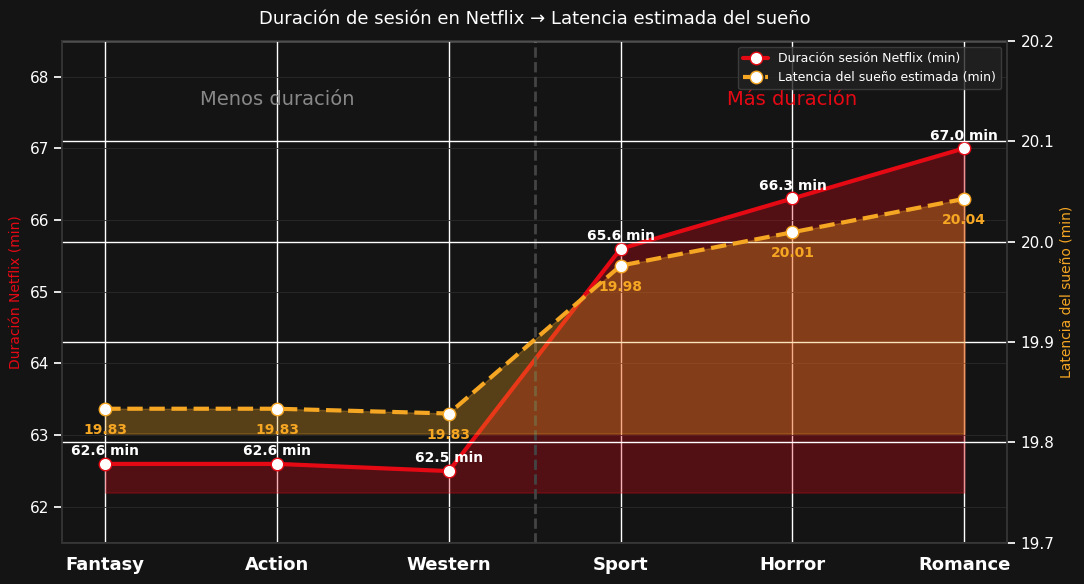

In [134]:
import matplotlib.pyplot as plt
import numpy as np

generos  = ['Fantasy', 'Action', 'Western', 'Sport', 'Horror', 'Romance']
duracion = [62.6, 62.6, 62.5, 65.6, 66.3, 67.0]
latencia = [0.0475*d + 16.86 for d in duracion]
x = np.arange(len(generos))

fig, ax1 = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#141414')
ax1.set_facecolor('#141414')


ax1.fill_between(x, duracion, min(duracion)-0.3, alpha=0.3, color='#E50914')
ax1.plot(x, duracion, color='#E50914', linewidth=3, marker='o',
         markersize=9, markerfacecolor='white', markeredgecolor='#E50914',
         label='Duración sesión Netflix (min)')
for i, val in enumerate(duracion):
    ax1.text(i, val+0.12, f'{val} min', ha='center',
             color='white', fontsize=10, fontweight='bold')


ax2 = ax1.twinx()
ax2.set_facecolor('#141414')
ax2.fill_between(x, latencia, min(latencia)-0.02, alpha=0.3, color='#F5A623')
ax2.plot(x, latencia, color='#F5A623', linewidth=3, marker='o',
         markersize=9, markerfacecolor='white', markeredgecolor='#F5A623',
         label='Latencia del sueño estimada (min)', linestyle='--')
for i, val in enumerate(latencia):
    ax2.text(i, val-0.025, f'{val:.2f}', ha='center',
             color='#F5A623', fontsize=10, fontweight='bold')

ax1.axvline(2.5, color='#444444', linewidth=2, linestyle='--')
ax1.text(1, 67.6, 'Menos duración', ha='center', color='#888888', fontsize=14)
ax1.text(4, 67.6, 'Más duración',   ha='center', color='#E50914', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(generos, color='white', fontsize=13, fontweight='bold')
ax1.set_ylim(61.5, 68.5)
ax2.set_ylim(19.7, 20.2)
ax1.set_ylabel('Duración Netflix (min)', color='#E50914', fontsize=10)
ax2.set_ylabel('Latencia del sueño (min)', color='#F5A623', fontsize=10)
ax1.set_title('Duración de sesión en Netflix → Latencia estimada del sueño',
              color='white', fontsize=13, pad=12)
ax1.tick_params(colors='white')
ax2.tick_params(colors='white')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2,
           facecolor='#222222', edgecolor='#444444', labelcolor='white', fontsize=9)
ax1.yaxis.grid(True, color='#2a2a2a', linewidth=0.6)
ax1.set_axisbelow(True)
for spine in ax1.spines.values(): spine.set_edgecolor('#333333')
for spine in ax2.spines.values(): spine.set_edgecolor('#333333')
plt.tight_layout()
plt.show()

In [135]:
genre_analysis = df.groupby('genre_primary').agg(
    average_watch_time=('watch_duration_minutes', 'mean'),
    total_watch_time=('watch_duration_minutes', 'sum'),
    content_count=('watch_duration_minutes', 'count')
).reset_index()

genre_analysis['score_raw'] = (
    genre_analysis['average_watch_time'] * 0.2 +
    genre_analysis['total_watch_time']   * 0.5 +
    genre_analysis['content_count']      * 0.3
)

genre_analysis['genre_score_norm'] = genre_analysis['score_raw'] / genre_analysis['score_raw'].max()

In [136]:
df['abandoned'] = df['progress_percentage'] < 40
abandono = df.groupby('genre_primary')['abandoned'].mean().reset_index()
abandono.columns = ['genre_primary', 'abandono_rate']
abandono['retencion_norm'] = 1 - abandono['abandono_rate']

In [137]:
latencia_promedio_norm = df2['sleep_latency_mins'].mean() / 53

In [138]:
engagement = genre_analysis[['genre_primary','genre_score_norm']].merge(
    abandono[['genre_primary','retencion_norm']], on='genre_primary'
)

engagement['content_engagement_score'] = (
    engagement['genre_score_norm'] * 0.40 +
    engagement['retencion_norm']   * 0.30 -
    latencia_promedio_norm         * 0.30
).round(3)

resultado = engagement.sort_values('content_engagement_score', ascending=False)
print(resultado[['genre_primary','genre_score_norm','retencion_norm','content_engagement_score']])

   genre_primary  genre_score_norm  retencion_norm  content_engagement_score
10       History          1.000000        0.637182                     0.479
1      Adventure          0.965207        0.630321                     0.463
18           War          0.943145        0.634056                     0.455
6    Documentary          0.897572        0.640112                     0.439
19       Western          0.876764        0.643937                     0.431
8         Family          0.857537        0.630853                     0.420
0         Action          0.798519        0.635449                     0.398
15        Sci-Fi          0.801265        0.628672                     0.397
3      Biography          0.790037        0.641743                     0.396
4         Comedy          0.799066        0.626455                     0.395
14       Romance          0.797562        0.623705                     0.394
2      Animation          0.783498        0.620746                     0.387

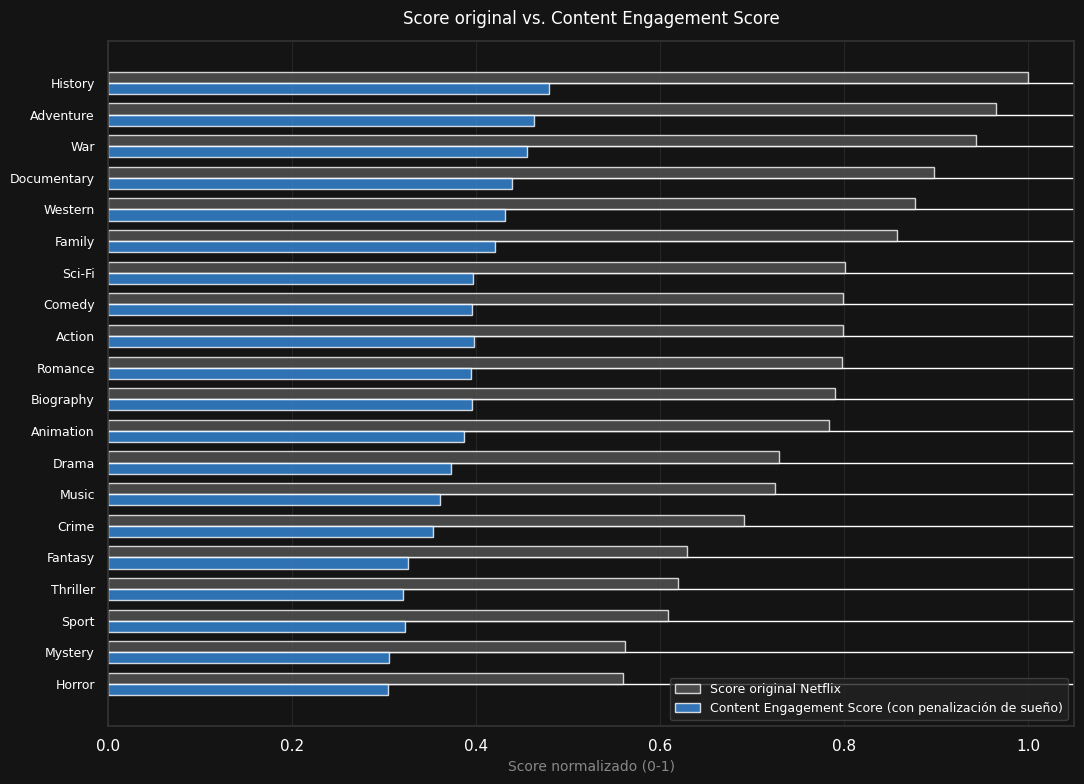

In [139]:
import matplotlib.pyplot as plt
import numpy as np

resultado_sorted = resultado.sort_values('genre_score_norm', ascending=True)
y = np.arange(len(resultado_sorted))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#141414')
ax.set_facecolor('#141414')

ax.barh(y + ancho/2, resultado_sorted['genre_score_norm'],
        height=ancho, color='#555555', alpha=0.8, label='Score original Netflix')
ax.barh(y - ancho/2, resultado_sorted['content_engagement_score'],
        height=ancho, color='#378ADD', alpha=0.8,
        label='Content Engagement Score (con penalización de sueño)')

ax.set_yticks(y)
ax.set_yticklabels(resultado_sorted['genre_primary'], color='white', fontsize=9)
ax.set_title('Score original vs. Content Engagement Score', color='white', fontsize=12, pad=12)
ax.set_xlabel('Score normalizado (0-1)', color='#888888', fontsize=10)
ax.tick_params(colors='white')
ax.legend(facecolor='#222222', edgecolor='#444444', labelcolor='white', fontsize=9)
ax.xaxis.grid(True, color='#2a2a2a', linewidth=0.6)
ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_edgecolor('#333333')

plt.tight_layout()
plt.show()

In [140]:
intensity_map = {
    'Horror': 3, 'Action': 3, 'Crime': 3, 'Drama': 3, 'Thriller': 3,
    'Romance': 2, 'Sci-Fi': 2, 'Animation': 2, 'History': 2,
    'Comedy': 1, 'Documentary': 1, 'Music': 1, 'Western': 1,
}
df['emotional_intensity_score'] = df['genre_primary'].map(intensity_map)

print(df['emotional_intensity_score'].value_counts())

emotional_intensity_score
3.0    10815
2.0    10543
1.0    10538
Name: count, dtype: int64


In [141]:

df['emotional_intensity_norm'] = df['emotional_intensity_score'] / 3


df['watch_duration_norm'] = df['watch_duration_minutes'].clip(upper=135) / 135

print('emotional_intensity_norm:')
print(df['emotional_intensity_norm'].value_counts().round(2))
print()
print('watch_duration_norm estadísticas:')
print(df['watch_duration_norm'].describe().round(2))

emotional_intensity_norm:
emotional_intensity_norm
1.000000    10815
0.666667    10543
0.333333    10538
Name: count, dtype: int64

watch_duration_norm estadísticas:
count    48865.00
mean         0.43
std          0.26
min          0.00
25%          0.23
50%          0.38
75%          0.57
max          1.00
Name: watch_duration_norm, dtype: float64


In [142]:
df2['screen_time_norm'] = df2['screen_time_before_bed_mins'] / 180

screen_time_promedio = df2['screen_time_norm'].mean()
print(f'Screen time normalizado promedio (sueño): {screen_time_promedio:.3f}')

Screen time normalizado promedio (sueño): 0.354


In [143]:

df['sleep_risk_score'] = (
    df['emotional_intensity_norm'] * 0.40 +
    df['watch_duration_norm']      * 0.35 +
    screen_time_promedio           * 0.25
)


resultado = df.groupby('genre_primary')['sleep_risk_score'].mean().sort_values(ascending=False).round(3)
print('Sleep Risk Score por género:')
print(resultado)

Sleep Risk Score por género:
genre_primary
Horror         0.641
Drama          0.639
Action         0.639
Thriller       0.638
Crime          0.636
Romance        0.509
Animation      0.507
Sci-Fi         0.507
History        0.506
Music          0.374
Documentary    0.373
Comedy         0.373
Western        0.370
Adventure        NaN
Biography        NaN
Family           NaN
Fantasy          NaN
Mystery          NaN
Sport            NaN
War              NaN
Name: sleep_risk_score, dtype: float64


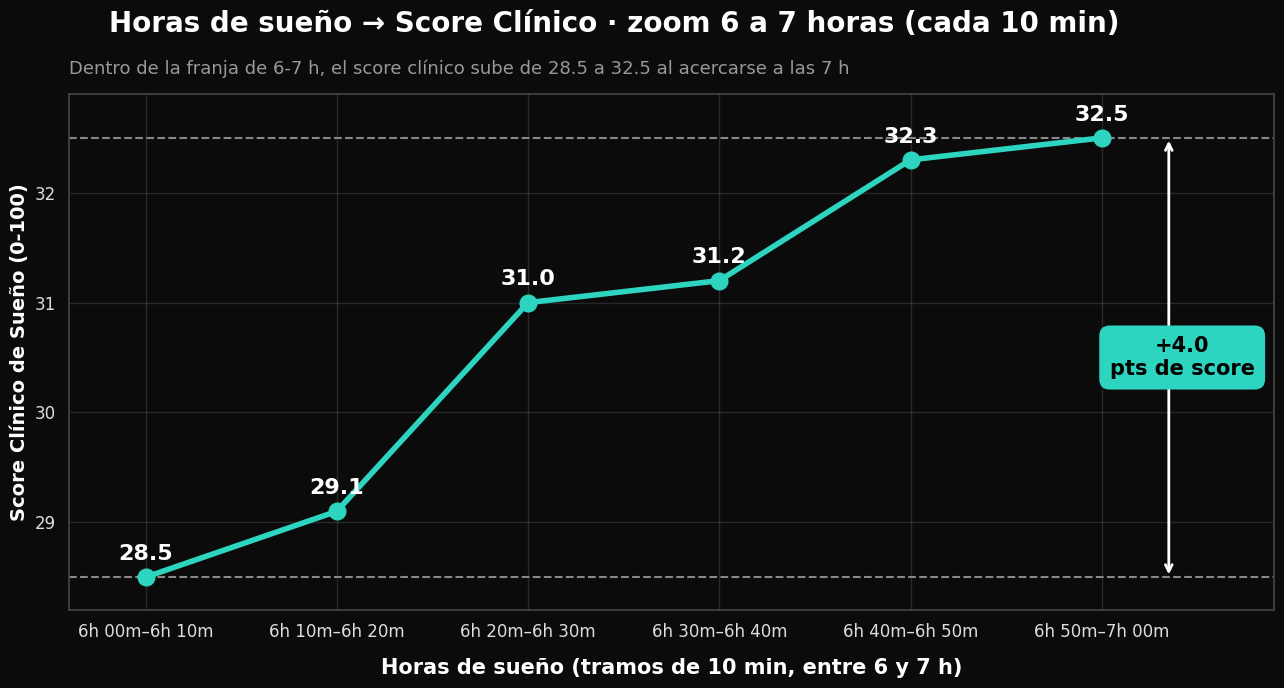

In [144]:
import matplotlib.pyplot as plt

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#0b0b0b"; TEAL = "#2dd4bf"

labels = ["6h 00m–6h 10m","6h 10m–6h 20m","6h 20m–6h 30m","6h 30m–6h 40m","6h 40m–6h 50m","6h 50m–7h 00m"]
score  = [28.5, 29.1, 31.0, 31.2, 32.3, 32.5]

fig, ax = plt.subplots(figsize=(13,7)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
x = range(len(labels))
ax.plot(x, score, color=TEAL, lw=4, marker="o", ms=12, zorder=3)
for xi, yi in zip(x, score):
    ax.text(xi, yi+0.12, f"{yi:.1f}", ha="center", va="bottom", color="white", fontsize=16, fontweight="bold")
ax.axhline(score[0], ls="--", color="#888", lw=1.5); ax.axhline(score[-1], ls="--", color="#888", lw=1.5)
ax.annotate("", xy=(5.35, score[-1]), xytext=(5.35, score[0]), arrowprops=dict(arrowstyle="<->", color="white", lw=2))
ax.text(5.42, (score[0]+score[-1])/2, "+4.0\npts de score", color="black", fontsize=15, fontweight="bold",
        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", fc=TEAL, ec="none"))
ax.set_xlim(-0.4, 5.9); ax.set_ylim(28.2, 32.9)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=11, color="#ddd")
ax.tick_params(colors="#ddd", labelsize=12)
ax.set_ylabel("Score Clínico de Sueño (0-100)", fontsize=14, fontweight="bold", color="white")
ax.set_xlabel("Horas de sueño (tramos de 10 min, entre 6 y 7 h)", fontsize=15, fontweight="bold", color="white", labelpad=12)
fig.suptitle("Horas de sueño → Score Clínico · zoom 6 a 7 horas (cada 10 min)", x=0.09, ha="left", fontsize=20, fontweight="bold", color="white")
ax.set_title("Dentro de la franja de 6-7 h, el score clínico sube de 28.5 a 32.5 al acercarse a las 7 h", loc="left", fontsize=13, color="#999", pad=14)
ax.grid(alpha=0.12)
for s in ax.spines.values(): s.set_color("#444")
plt.tight_layout(); plt.show()

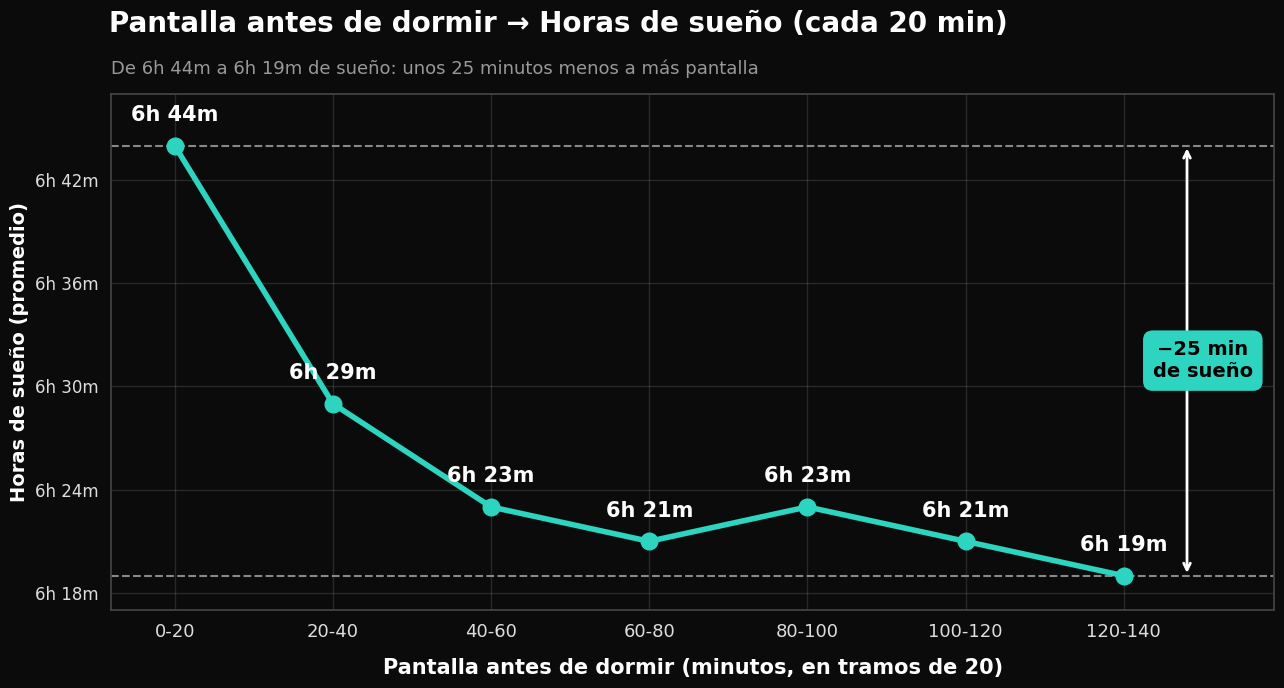

In [145]:
import matplotlib.pyplot as plt

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#0b0b0b"; TEAL = "#2dd4bf"

labels = ["0-20","20-40","40-60","60-80","80-100","100-120","120-140"]
mins   = [404, 389, 383, 381, 383, 381, 379]   # 6h44m, 6h29m, ...
fmt = lambda m: f"{m//60}h {m%60:02d}m"

fig, ax = plt.subplots(figsize=(13,7)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
x = range(len(labels))
ax.plot(x, mins, color=TEAL, lw=4, marker="o", ms=12, zorder=3)
for xi, yi in zip(x, mins):
    ax.text(xi, yi+1.2, fmt(yi), ha="center", va="bottom", color="white", fontsize=15, fontweight="bold")
ax.axhline(max(mins), ls="--", color="#888", lw=1.5); ax.axhline(min(mins), ls="--", color="#888", lw=1.5)
ax.annotate("", xy=(6.4, max(mins)), xytext=(6.4, min(mins)), arrowprops=dict(arrowstyle="<->", color="white", lw=2))
ax.text(6.5, (max(mins)+min(mins))/2, "−25 min\nde sueño", color="black", fontsize=14, fontweight="bold",
        ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", fc=TEAL, ec="none"))
ticks = list(range(378, 408, 6)); ax.set_yticks(ticks); ax.set_yticklabels([fmt(t) for t in ticks], fontsize=12, color="#ddd")
ax.set_xlim(-0.4, 6.95); ax.set_ylim(377, 407)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=13, color="#ddd")
ax.set_ylabel("Horas de sueño (promedio)", fontsize=14, fontweight="bold", color="white")
ax.set_xlabel("Pantalla antes de dormir (minutos, en tramos de 20)", fontsize=15, fontweight="bold", color="white", labelpad=12)
fig.suptitle("Pantalla antes de dormir → Horas de sueño (cada 20 min)", x=0.09, ha="left", fontsize=20, fontweight="bold", color="white")
ax.set_title("De 6h 44m a 6h 19m de sueño: unos 25 minutos menos a más pantalla", loc="left", fontsize=13, color="#999", pad=14)
ax.grid(alpha=0.12)
for s in ax.spines.values(): s.set_color("#444")
plt.tight_layout(); plt.show()

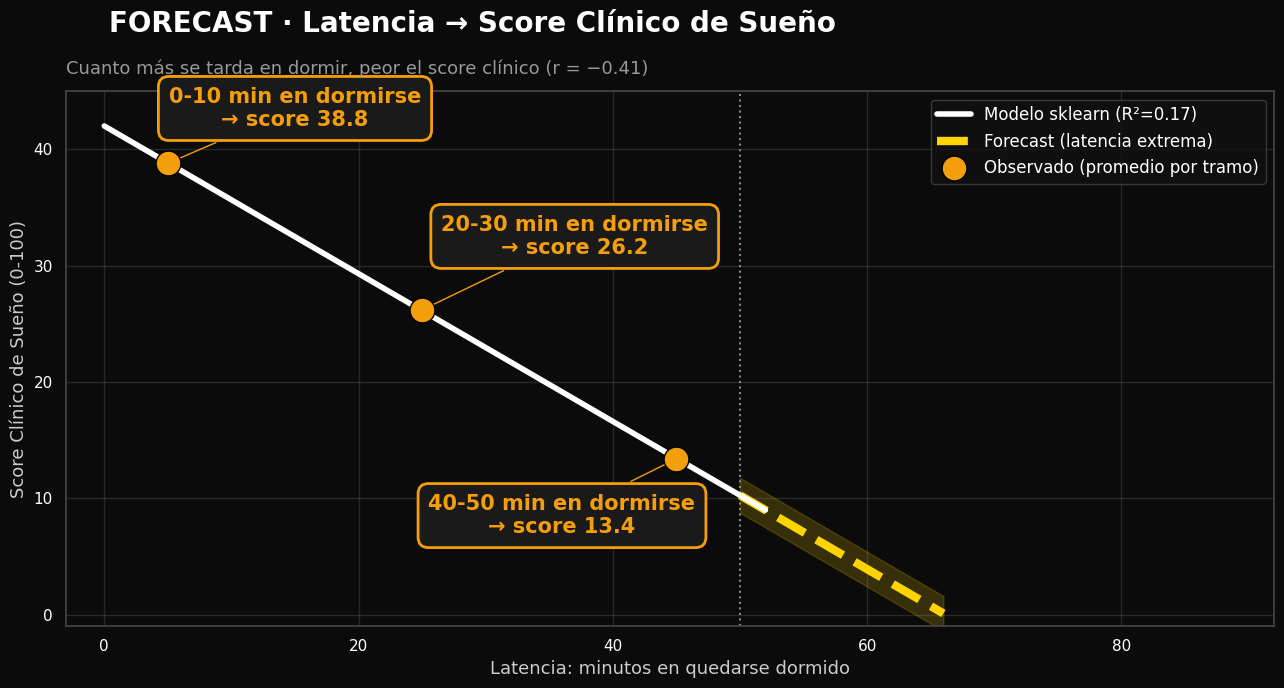

In [146]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#0b0b0b"; ORANGE = "#f59e0b"; YEL = "#ffd400"

lat = np.array([5, 25, 45]).reshape(-1,1); sc = np.array([38.8, 26.2, 13.4])
m = LinearRegression().fit(lat, sc)

fig, ax = plt.subplots(figsize=(13,7)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
xl = np.linspace(0, 52, 50); ax.plot(xl, m.predict(xl.reshape(-1,1)), color="white", lw=4, zorder=3, label="Modelo sklearn (R²=0.17)")
xf = np.linspace(50, 66, 30); yf = m.predict(xf.reshape(-1,1))
ax.plot(xf, yf, color=YEL, lw=6, ls="--", zorder=2, label="Forecast (latencia extrema)")
ax.fill_between(xf, yf-1.5, yf+1.5, color=YEL, alpha=0.18)
ax.axvline(50, ls=":", color="#888", lw=1.5)
ax.scatter(lat, sc, s=320, color=ORANGE, ec="black", zorder=5, label="Observado (promedio por tramo)")
box = dict(boxstyle="round,pad=0.5", fc="#1a1a1a", ec=ORANGE, lw=2)
ax.annotate("0-10 min en dormirse\n→ score 38.8",  xy=(5,38.8),  xytext=(15,42), color=ORANGE, fontsize=15, fontweight="bold", ha="center", bbox=box, arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.annotate("20-30 min en dormirse\n→ score 26.2", xy=(25,26.2), xytext=(37,31), color=ORANGE, fontsize=15, fontweight="bold", ha="center", bbox=box, arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.annotate("40-50 min en dormirse\n→ score 13.4", xy=(45,13.4), xytext=(36,7),  color=ORANGE, fontsize=15, fontweight="bold", ha="center", bbox=box, arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.set_xlim(-3, 92); ax.set_ylim(-1, 45)
ax.set_xlabel("Latencia: minutos en quedarse dormido", fontsize=13, color="#ccc")
ax.set_ylabel("Score Clínico de Sueño (0-100)", fontsize=13, color="#ccc")
fig.suptitle("FORECAST · Latencia → Score Clínico de Sueño", x=0.09, ha="left", fontsize=20, fontweight="bold", color="white")
ax.set_title("Cuanto más se tarda en dormir, peor el score clínico (r = −0.41)", loc="left", fontsize=13, color="#999", pad=12)
ax.legend(loc="upper right", fontsize=12, facecolor="#111", edgecolor="#444")
ax.grid(alpha=0.12)
for s in ax.spines.values(): s.set_color("#444")
plt.tight_layout(); plt.show()

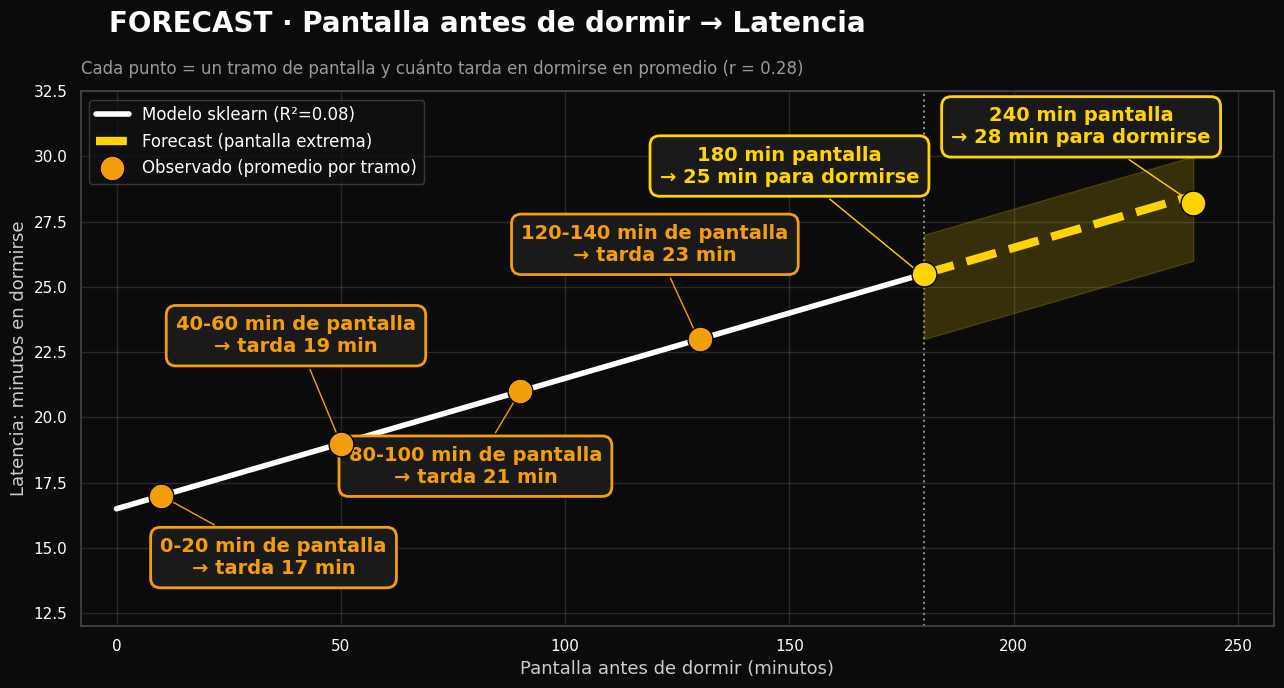

In [147]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#0b0b0b"; ORANGE = "#f59e0b"; YEL = "#ffd400"

scr = np.array([10, 50, 90, 130]).reshape(-1,1); ltc = np.array([17, 19, 21, 23])
m = LinearRegression().fit(scr, ltc)

fig, ax = plt.subplots(figsize=(13,7)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
xl = np.linspace(0, 180, 50); ax.plot(xl, m.predict(xl.reshape(-1,1)), color="white", lw=4, zorder=3, label="Modelo sklearn (R²=0.08)")
xf = np.linspace(180, 240, 30); yf = m.predict(xf.reshape(-1,1))
ax.plot(xf, yf, color=YEL, lw=6, ls="--", zorder=2, label="Forecast (pantalla extrema)")
ax.fill_between(xf, yf-2.5, yf+1.5, color=YEL, alpha=0.18)
ax.axvline(180, ls=":", color="#888", lw=1.5)
ax.scatter(scr, ltc, s=320, color=ORANGE, ec="black", zorder=5, label="Observado (promedio por tramo)")
ax.scatter([180, 240], [m.predict([[180]])[0], 28.2], s=320, color=YEL, ec="black", zorder=5)
box  = dict(boxstyle="round,pad=0.5", fc="#1a1a1a", ec=ORANGE, lw=2)
boxY = dict(boxstyle="round,pad=0.5", fc="#1a1a1a", ec=YEL, lw=2)
ax.annotate("0-20 min de pantalla\n→ tarda 17 min",   xy=(10,17),   xytext=(35,14),   color=ORANGE, fontsize=14, fontweight="bold", ha="center", bbox=box, arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.annotate("40-60 min de pantalla\n→ tarda 19 min",  xy=(50,19),   xytext=(40,22.5), color=ORANGE, fontsize=14, fontweight="bold", ha="center", bbox=box, arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.annotate("80-100 min de pantalla\n→ tarda 21 min", xy=(90,21),   xytext=(80,17.5), color=ORANGE, fontsize=14, fontweight="bold", ha="center", bbox=box, arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.annotate("120-140 min de pantalla\n→ tarda 23 min",xy=(130,22.9),xytext=(120,26),  color=ORANGE, fontsize=14, fontweight="bold", ha="center", bbox=box, arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.annotate("180 min pantalla\n→ 25 min para dormirse", xy=(180,25.4), xytext=(150,29),   color=YEL, fontsize=14, fontweight="bold", ha="center", bbox=boxY, arrowprops=dict(arrowstyle="-", color=YEL))
ax.annotate("240 min pantalla\n→ 28 min para dormirse", xy=(240,28.2), xytext=(215,30.5), color=YEL, fontsize=14, fontweight="bold", ha="center", bbox=boxY, arrowprops=dict(arrowstyle="-", color=YEL))
ax.set_xlim(-8, 258); ax.set_ylim(12, 32.5)
ax.set_xlabel("Pantalla antes de dormir (minutos)", fontsize=13, color="#ccc")
ax.set_ylabel("Latencia: minutos en dormirse", fontsize=13, color="#ccc")
fig.suptitle("FORECAST · Pantalla antes de dormir → Latencia", x=0.09, ha="left", fontsize=20, fontweight="bold", color="white")
ax.set_title("Cada punto = un tramo de pantalla y cuánto tarda en dormirse en promedio (r = 0.28)", loc="left", fontsize=12, color="#999", pad=12)
ax.legend(loc="upper left", fontsize=12, facecolor="#111", edgecolor="#444")
ax.grid(alpha=0.12)
for s in ax.spines.values(): s.set_color("#444")
plt.tight_layout(); plt.show()

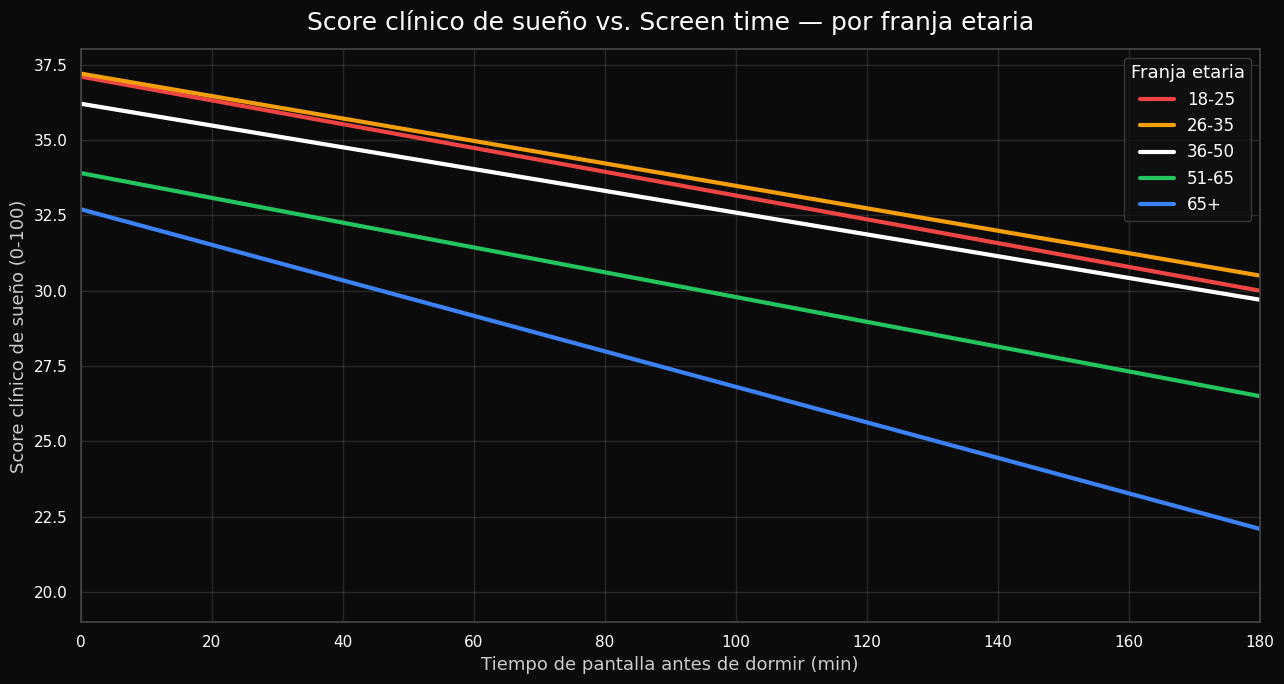

In [148]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#0b0b0b"

x = np.linspace(0, 180, 50)
# franja: (color, score con 0 min de pantalla, score con 180 min)
bands = {"18-25":("#ef4444",37.1,30.0), "26-35":("#f59e0b",37.2,30.5),
         "36-50":("#ffffff",36.2,29.7), "51-65":("#22c55e",33.9,26.5), "65+":("#3b82f6",32.7,22.1)}

fig, ax = plt.subplots(figsize=(13,7)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
for name,(col,y0,y1) in bands.items():
    ax.plot(x, np.linspace(y0, y1, len(x)), color=col, lw=3, label=name)
ax.set_xlim(0, 180); ax.set_ylim(19, 38)
ax.set_xlabel("Tiempo de pantalla antes de dormir (min)", fontsize=13, color="#ccc")
ax.set_ylabel("Score clínico de sueño (0-100)", fontsize=13, color="#ccc")
ax.set_title("Score clínico de sueño vs. Screen time — por franja etaria", fontsize=18, color="white", pad=14)
ax.legend(title="Franja etaria", loc="upper right", fontsize=12, title_fontsize=13, facecolor="#111", edgecolor="#444")
ax.grid(alpha=0.12)
for s in ax.spines.values(): s.set_color("#444")
plt.tight_layout(); plt.show()

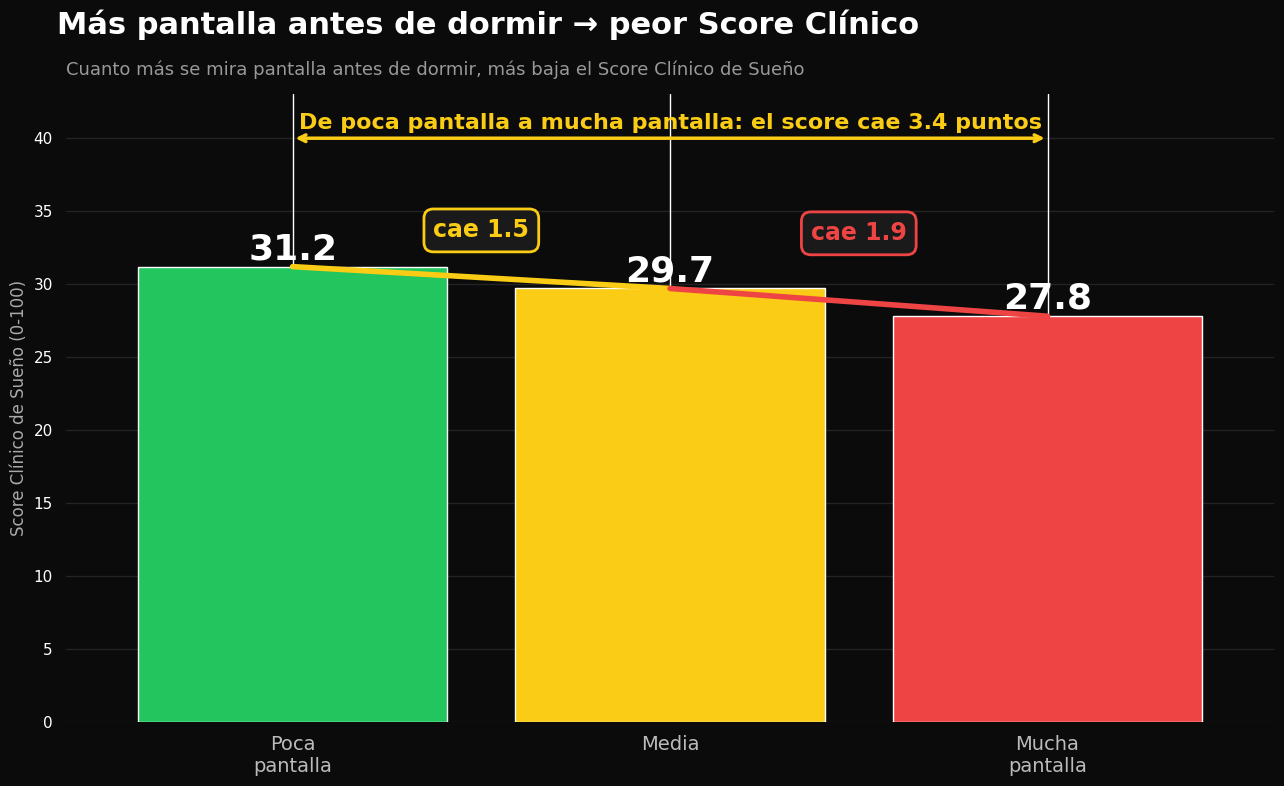

In [149]:
import matplotlib.pyplot as plt

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#0b0b0b"

cats = ["Poca\npantalla","Media","Mucha\npantalla"]; vals = [31.2, 29.7, 27.8]
cols = ["#22c55e","#facc15","#ef4444"]; xpos = [0, 1, 2]

fig, ax = plt.subplots(figsize=(13,8)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.bar(xpos, vals, color=cols, width=0.82, zorder=2)
for xi, yi in zip(xpos, vals):
    ax.text(xi, yi+0.5, f"{yi:.1f}", ha="center", color="white", fontsize=26, fontweight="bold")
ax.plot([0,1],[31.2,29.7], color="#facc15", lw=4, zorder=3, solid_capstyle="round")
ax.plot([1,2],[29.7,27.8], color="#ef4444", lw=4, zorder=3, solid_capstyle="round")
ax.text(0.5, 33.2, "cae 1.5", color="#facc15", fontsize=17, fontweight="bold", ha="center", bbox=dict(boxstyle="round,pad=0.4", fc="#1a1a1a", ec="#facc15", lw=2))
ax.text(1.5, 33.0, "cae 1.9", color="#ef4444", fontsize=17, fontweight="bold", ha="center", bbox=dict(boxstyle="round,pad=0.4", fc="#1a1a1a", ec="#ef4444", lw=2))
ax.annotate("", xy=(2.0,40), xytext=(0.0,40), arrowprops=dict(arrowstyle="<->", color="#facc15", lw=2.5))
ax.text(1.0, 40.6, "De poca pantalla a mucha pantalla: el score cae 3.4 puntos", color="#facc15", fontsize=16, fontweight="bold", ha="center")
ax.set_xlim(-0.6, 2.6); ax.set_ylim(0, 43)
ax.set_xticks(xpos); ax.set_xticklabels(cats, fontsize=14, color="#bbb")
ax.set_ylabel("Score Clínico de Sueño (0-100)", fontsize=12, color="#aaa")
fig.suptitle("Más pantalla antes de dormir → peor Score Clínico", x=0.05, ha="left", fontsize=22, fontweight="bold", color="white")
ax.set_title("Cuanto más se mira pantalla antes de dormir, más baja el Score Clínico de Sueño", loc="left", fontsize=13, color="#999", pad=14)
ax.grid(axis="y", alpha=0.1)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.show()

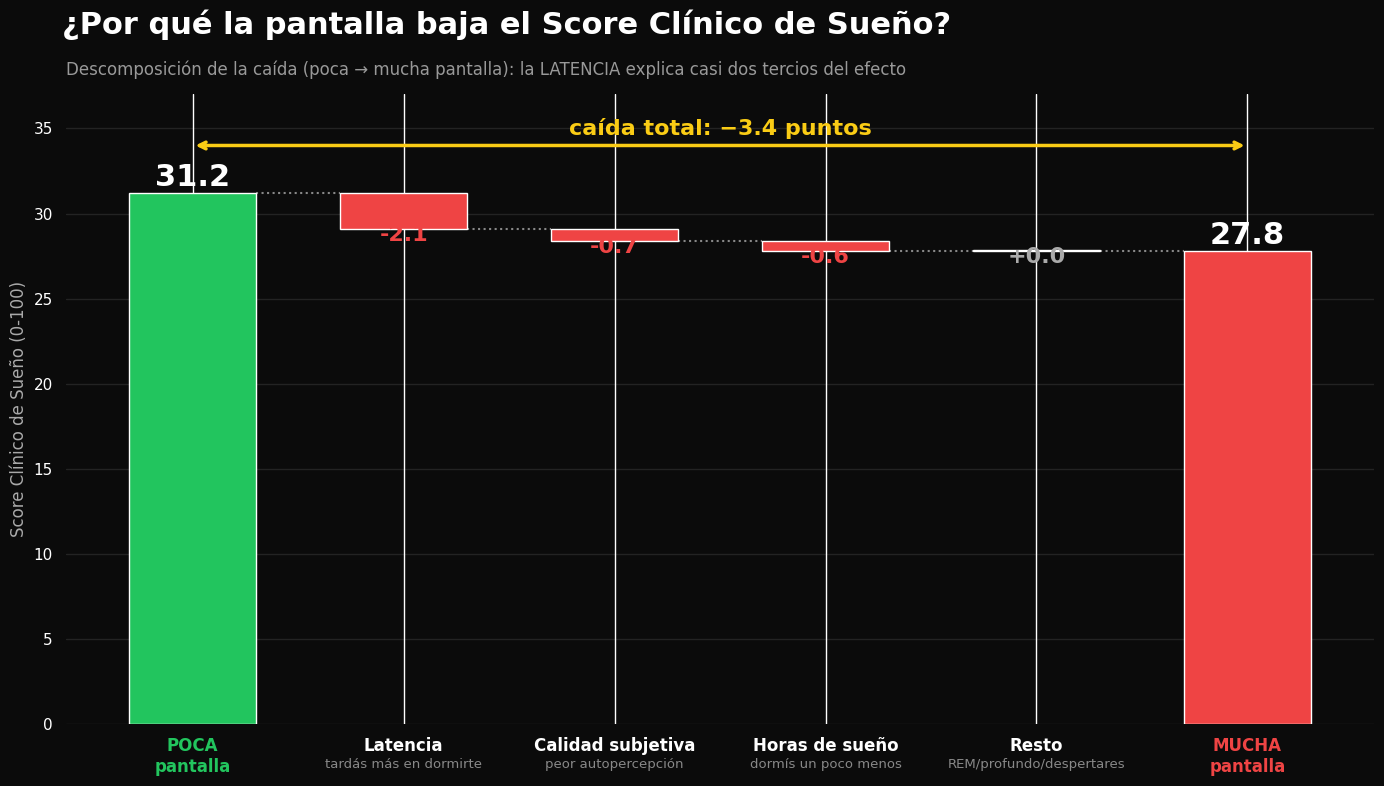

In [150]:
import matplotlib.pyplot as plt

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#0b0b0b"

labels = ["POCA\npantalla","Latencia","Calidad subjetiva","Horas de sueño","Resto","MUCHA\npantalla"]
subs   = ["","tardás más en dormirte","peor autopercepción","dormís un poco menos","REM/profundo/despertares",""]
start = 31.2; deltas = [-2.1, -0.7, -0.6, 0.0]; end = 27.8

fig, ax = plt.subplots(figsize=(14,8)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.bar(0, start, color="#22c55e", width=0.6, zorder=3)
ax.text(0, start+0.4, f"{start:.1f}", ha="center", color="white", fontsize=22, fontweight="bold")
cum = start
for i, d in enumerate(deltas):
    bottom = cum+d if d < 0 else cum
    ax.bar(i+1, abs(d) if d != 0 else 0.05, bottom=bottom, color="#ef4444" if d != 0 else "#666", width=0.6, zorder=3)
    ax.plot([i+0.3, i+0.7], [cum, cum], ls=":", color="#888", lw=1.5, zorder=2)
    ax.text(i+1, bottom-0.7, f"{d:+.1f}", ha="center", color="#ef4444" if d != 0 else "#aaa", fontsize=16, fontweight="bold")
    cum += d
ax.plot([4.3, 4.7], [cum, cum], ls=":", color="#888", lw=1.5)
ax.bar(5, end, color="#ef4444", width=0.6, zorder=3)
ax.text(5, end+0.4, f"{end:.1f}", ha="center", color="white", fontsize=22, fontweight="bold")
ax.annotate("", xy=(5,34), xytext=(0,34), arrowprops=dict(arrowstyle="<->", color="#facc15", lw=2.5))
ax.text(2.5, 34.6, "caída total: −3.4 puntos", color="#facc15", fontsize=16, fontweight="bold", ha="center")
ax.set_xlim(-0.6, 5.6); ax.set_ylim(0, 37)
ax.set_xticks(range(6)); ax.set_xticklabels(labels, fontsize=12, fontweight="bold")
for t, c in zip(ax.get_xticklabels(), ["#22c55e","white","white","white","white","#ef4444"]): t.set_color(c)
for i, s in enumerate(subs):
    if s: ax.text(i, -2.6, s, ha="center", color="#888", fontsize=9.5)
ax.set_ylabel("Score Clínico de Sueño (0-100)", fontsize=12, color="#aaa")
fig.suptitle("¿Por qué la pantalla baja el Score Clínico de Sueño?", x=0.05, ha="left", fontsize=22, fontweight="bold", color="white")
ax.set_title("Descomposición de la caída (poca → mucha pantalla): la LATENCIA explica casi dos tercios del efecto", loc="left", fontsize=12, color="#999", pad=14)
ax.grid(axis="y", alpha=0.1)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.show()

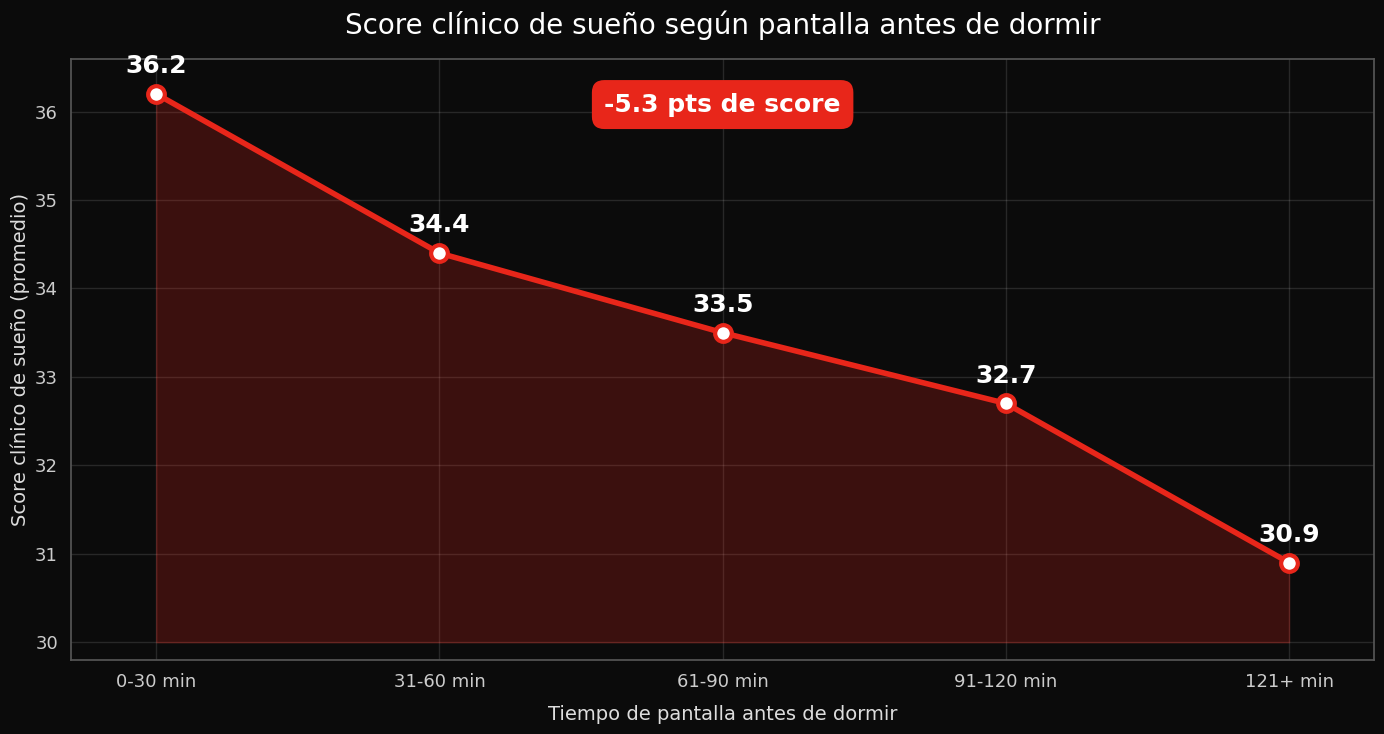

In [151]:
import matplotlib.pyplot as plt

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#0b0b0b"; RED = "#e8261a"

labels = ["0-30 min","31-60 min","61-90 min","91-120 min","121+ min"]
score  = [36.2, 34.4, 33.5, 32.7, 30.9]

fig, ax = plt.subplots(figsize=(14,7.5)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
x = range(len(labels))
ax.fill_between(x, score, 30, color=RED, alpha=0.22, zorder=1)
ax.plot(x, score, color=RED, lw=4, zorder=3)
ax.plot(x, score, "o", ms=12, mfc="white", mec=RED, mew=3, zorder=4)
for xi, yi in zip(x, score):
    ax.text(xi, yi+0.18, f"{yi:.1f}", ha="center", va="bottom", color="white", fontsize=18, fontweight="bold")
ax.text(2.0, 36.0, "-5.3 pts de score", color="white", fontsize=18, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.5", fc=RED, ec="none"))
ax.set_xlim(-0.3, 4.3); ax.set_ylim(29.8, 36.6)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=15, color="#ddd")
ax.tick_params(colors="#ccc", labelsize=13)
ax.set_ylabel("Score clínico de sueño (promedio)", fontsize=14, color="#ddd")
ax.set_xlabel("Tiempo de pantalla antes de dormir", fontsize=14, color="#ddd", labelpad=10)
ax.set_title("Score clínico de sueño según pantalla antes de dormir", fontsize=20, color="white", pad=18)
ax.grid(alpha=0.12)
for s in ax.spines.values(): s.set_color("#555")
plt.tight_layout(); plt.show()

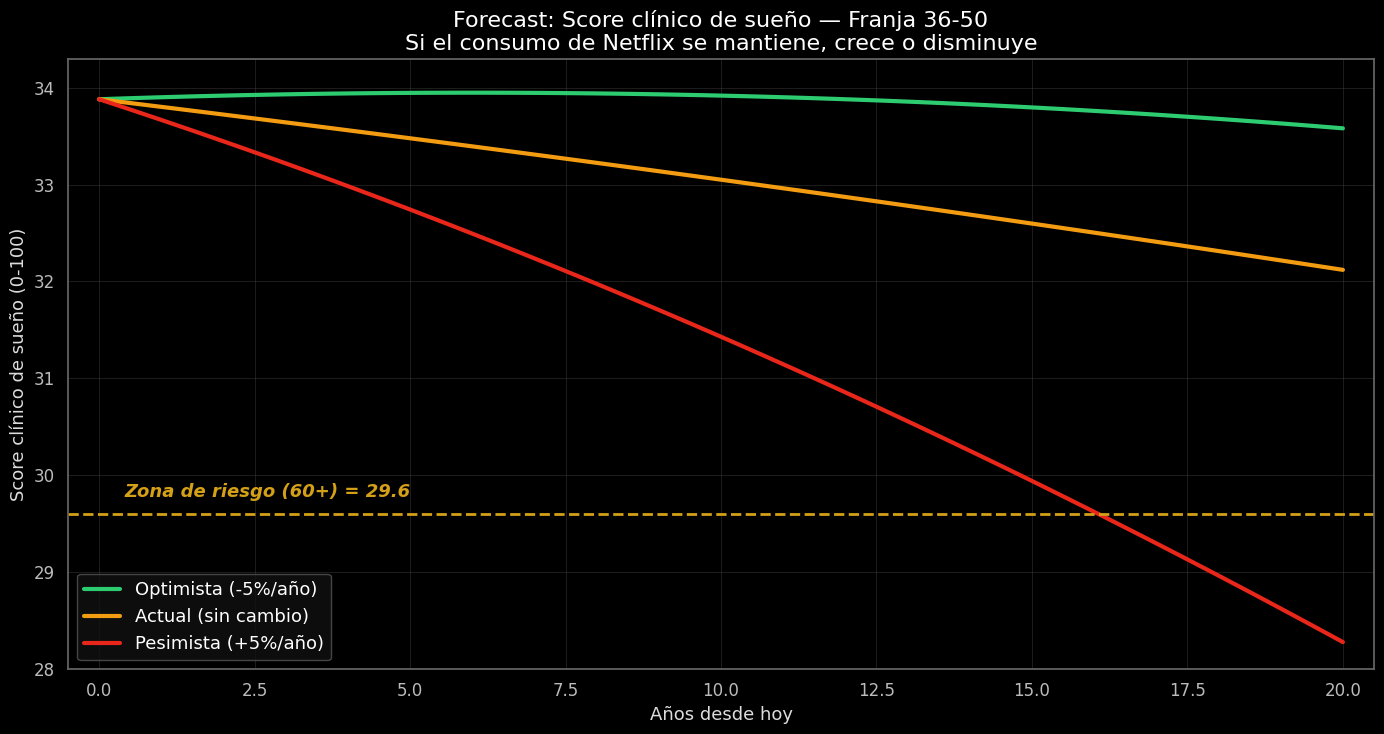

In [152]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("dark_background"); plt.rcParams["font.family"] = "DejaVu Sans"
BG = "#000000"

years = np.linspace(0, 20, 100); y0 = 33.88
opt = y0 + 0.0225*years - 0.001875*years**2   # Optimista: -5%/año de pantalla
act = y0 - 0.078*years   - 0.0005*years**2     # Actual: sin cambio
pes = y0 - 0.21*years    - 0.0035*years**2     # Pesimista: +5%/año de pantalla

fig, ax = plt.subplots(figsize=(14,7.5)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.plot(years, opt, color="#2ecc71", lw=3, label="Optimista (-5%/año)")
ax.plot(years, act, color="#f39c12", lw=3, label="Actual (sin cambio)")
ax.plot(years, pes, color="#e8261a", lw=3, label="Pesimista (+5%/año)")
ax.axhline(29.6, ls="--", color="#d4a017", lw=2)
ax.text(0.4, 29.78, "Zona de riesgo (60+) = 29.6", color="#d4a017", fontsize=13, fontstyle="italic", fontweight="bold")
ax.set_xlim(-0.5, 20.5); ax.set_ylim(28, 34.3)
ax.set_xlabel("Años desde hoy", fontsize=13, color="#ddd")
ax.set_ylabel("Score clínico de sueño (0-100)", fontsize=13, color="#ddd")
ax.set_title("Forecast: Score clínico de sueño — Franja 36-50\nSi el consumo de Netflix se mantiene, crece o disminuye", fontsize=16, color="white")
ax.legend(loc="lower left", fontsize=13, facecolor="#111", edgecolor="#555", labelcolor="white")
ax.tick_params(colors="#bbb", labelsize=12)
ax.grid(True, color="#444", lw=0.6, alpha=0.5)
for s in ax.spines.values(): s.set_color("#666")
plt.tight_layout(); plt.show()